# Breakfast at the Frat — Machine Learning Extension

## Daftar Isi
0. Library Set Up
1. Data Understanding & Cleaning
2. EDA
3. Feature Engineering (Pricing, Sales, Time, Promotion, Store)
4. Machine Learning Preparation
5. Baseline Model
6. Regression — Model Comparison (Linear, Decision Tree, Random Forest, XGBoost, LightGBM)
7. Classification — Promotion/Sales Success Prediction
8. Cross Validation yang Benar (TimeSeriesSplit)
9. Hyperparameter Tuning (RandomizedSearchCV, Optuna)
10. Feature Selection (Variance Threshold, Mutual Information, RFE, LASSO)
11. Feature Importance & Explainable AI (SHAP)
12. Time Series Forecasting — Model Comparison (Moving Average, ARIMA, SARIMA, Prophet, XGBoost-TS)
13. Store Clustering / Segmentation
14. Association Rules (dengan catatan keterbatasan dataset)
15. Error Analysis
16. Scenario Simulation — Pricing & Promotion What-If
17. Recommendation Engine — Optimal Pricing
18. Business Recommendation & Penutup

# PART 1. BUSINESS UNDERSTANDING

## Chapter 0. Library & Setup

In [ ]:
# LIBRARY UTAMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import sys
import time
import math
import jinja2
from lightgbm import LGBMRegressor
# LIBRARY MACHINE LEARNING
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    silhouette_score
)
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE

import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from mlxtend.frequent_patterns import apriori, association_rules

# DISPLAY & STYLE SETTING 

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# COLOR SYSTEM 
# Definisi palette konsisten untuk seluruh notebook
PALETTE_PRIMARY  = "Blues_d"    # performa utama: R², Accuracy, Feature Importance
PALETTE_ERROR    = "Oranges_d"  # metrik error: SMAPE, MAE, RMSE
PALETTE_SUCCESS  = "Greens_d"   # klasifikasi: ROC-AUC, F1, Recall
PALETTE_NEUTRAL  = "viridis"    # informasional: MI, SHAP, LASSO, Cluster

## Business Understanding & Problem Formulation

**Business Question :**
*"Apa yang terjadi pada penjualan ketika harga/promosi berubah?"* Chapter ini melangkah ke pertanyaan **prediktif dan preskriptif**:

1. **Prediktif:** Bisakah memprediksi `UNITS` terjual berdasarkan harga, promosi, kategori, dan karakteristik toko? 
2. **Klasifikasi:** Bisakah memprediksi apakah suatu kombinasi produk-toko-minggu akan masuk kategori "High Sales" atau "Low Sales"? 
3. **Segmentasi:** Apakah toko-toko bisa dikelompokkan secara otomatis berdasarkan pola penjualan & karakteristiknya, tanpa label manual? 
4. **Preskriptif:** Jika harga diturunkan 5%, 10%, atau dinaikkan 3%, apa dampaknya terhadap penjualan dan revenue? 
5. **Rekomendasi:** Untuk kombinasi toko-kategori tertentu, berapa harga optimal yang memaksimalkan revenue?


# PART 2. DATA PREPARATION

## Chapter 1. Data Understanding & Cleaning

### 1.0 Pengecekan Data

In [25]:
excel = pd.ExcelFile("dunnhumby - Breakfast at the Frat.xlsx")

transaction_0 = pd.read_excel(excel, sheet_name="dh Transaction Data")
product_0     = pd.read_excel(excel, sheet_name="dh Products Lookup")
store_0       = pd.read_excel(excel, sheet_name="dh Store Lookup")

datasets_0 = {
    "Transaction": transaction_0,
    "Product": product_0,
    "Store": store_0
}

for name, df in datasets_0.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(df.columns.tolist())
    print()

Transaction
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Breakfast at the Frat: A Time Series Analysis', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

Product
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Breakfast at the Frat: A Time Series Analysis', 'Unnamed: 4', 'Unnamed: 5']

Store
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Breakfast at the Frat: A Time Series Analysis', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']



Ditemukannya header yang menyebabkan nama kolom pada dataset tidak memiliki nama.

In [26]:
excel = pd.ExcelFile("dunnhumby - Breakfast at the Frat.xlsx")
transaction = pd.read_excel(excel, sheet_name="dh Transaction Data", skiprows=1)
product     = pd.read_excel(excel, sheet_name="dh Products Lookup", skiprows=1)
store       = pd.read_excel(excel, sheet_name="dh Store Lookup", skiprows=1)

datasets = {
    "Transaction": transaction,
    "Product": product,
    "Store": store
}

print("Transaction:", transaction.shape)
print("Product    :", product.shape)
print("Store      :", store.shape)

for name, df in datasets.items():
    print("\n",name.upper())
    print("=" * 70)
    print(df.dtypes)
    print()

Transaction: (524950, 12)
Product    : (58, 6)
Store      : (79, 9)

 TRANSACTION
WEEK_END_DATE    datetime64[ns]
STORE_NUM                 int64
UPC                       int64
UNITS                     int64
VISITS                    int64
HHS                       int64
SPEND                   float64
PRICE                   float64
BASE_PRICE              float64
FEATURE                   int64
DISPLAY                   int64
TPR_ONLY                  int64
dtype: object


 PRODUCT
UPC              int64
DESCRIPTION     object
MANUFACTURER    object
CATEGORY        object
SUB_CATEGORY    object
PRODUCT_SIZE    object
dtype: object


 STORE
STORE_ID                     int64
STORE_NAME                  object
ADDRESS_CITY_NAME           object
ADDRESS_STATE_PROV_CODE     object
MSA_CODE                     int64
SEG_VALUE_NAME              object
PARKING_SPACE_QTY          float64
SALES_AREA_SIZE_NUM          int64
AVG_WEEKLY_BASKETS         float64
dtype: object



Header berhasil dihapus dan setiap kolom sudah sesuai memiliki nama kolom dan tipe datanya masing masing tanpa perlunya pengelompokkkan tipe data lebih lanjut

### 1.1 Cek Duplicate Data

In [27]:
print("Jumlah baris transaksi duplikat penuh :", transaction.duplicated().sum())
print("Jumlah STORE_ID duplikat di Store lookup:", store["STORE_ID"].duplicated().sum())
print("Jumlah UPC duplikat di Product lookup    :", product["UPC"].duplicated().sum())

# menampilkan detail store yang terduplikasi
print()
print("Detail store yang muncul lebih dari sekali:")
display(store[store["STORE_ID"].duplicated(keep=False)].sort_values("STORE_ID"))

Jumlah baris transaksi duplikat penuh : 0
Jumlah STORE_ID duplikat di Store lookup: 2
Jumlah UPC duplikat di Product lookup    : 0

Detail store yang muncul lebih dari sekali:


,STORE_ID,STORE_NAME,ADDRESS_CITY_NAME,ADDRESS_STATE_PROV_CODE,MSA_CODE,SEG_VALUE_NAME,PARKING_SPACE_QTY,SALES_AREA_SIZE_NUM,AVG_WEEKLY_BASKETS
22,4503,ROCKWALL,ROCKWALL,TX,19100,MAINSTREAM,NaN,56230,25289.33
61,4503,ROCKWALL,ROCKWALL,TX,19100,UPSCALE,NaN,56230,25289.33
39,17627,FLOWER MOUND,FLOWER MOUND,TX,19100,MAINSTREAM,513.00,59213,18196.82
54,17627,FLOWER MOUND,FLOWER MOUND,TX,19100,UPSCALE,513.00,59213,18196.82


Ada 2 STORE_ID yang muncul 2 kali di tabel Store Lookup (4503 - ROCKWALL dan 17627 - FLOWER MOUND). Perhatikan pada SEG_VALUE_NAME yang BERBEDA (kemungkinan toko berpindah segmen di tengah periode data, atau kesalahan input data).

Dampak jika tidak diperbaiki: 

Saat melakukan merge antara transaction dan store, setiap transaksi dari kedua toko ini akan terduplikasi 2x untuk laporan BI (rata-rata, agregat), efeknya kecil dan mungkin tidak terlalu terasa. Tapi untuk model Machine Learning, ini artinya model "belajar" dari pola yang sama dua kali, yang bisa membuat performa model di test set terlihat lebih baik dari yang sebenarnya (data leakage gaya duplikasi).

Pilihan: 

Faktanya tidak ada jejak mana yang sebenarnya benar apakah toko itu termasuk mainstream atau upscale, jadi dihapus kecuali yang terakhir muncul, yaitu upscale. (Mungkin dalam kasus sebenarnya dapat dicari jejak yang sebenarnya).

In [28]:
# membuang salinannya dan menyisakan satu baris terakhir per STORE_ID.

store_clean = store.drop_duplicates(subset="STORE_ID", keep="last").reset_index(drop=True)
print("Store sebelum de-duplicate:", store.shape[0], "-> sesudah de-duplicate:", store_clean.shape[0])

Store sebelum de-duplicate: 79 -> sesudah de-duplicate: 77


### 1.2 Cek Missing Value

In [29]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print("=" * 60)
    print(name)
    if missing.empty:
        print("Tidak ada missing value.")
    else:
        missing_pct = (missing/len(df)*100).round(2)
        summary = pd.DataFrame({
            "Missing_count": missing,
            "Missing(%)": missing_pct
        })
        print(summary)
    print()

Transaction
            Missing_count  Missing(%)
PRICE                  23        0.00
BASE_PRICE            185        0.04

Product
Tidak ada missing value.

Store
                   Missing_count  Missing(%)
PARKING_SPACE_QTY             52       65.82



In [30]:
# penanganan missing value

# membuat label dalam output
print("=" * 70)
print("TRANSACTION")

before = transaction.shape[0]

# mengisi PRICE dengan BASE_PRICE jika kosong
transaction["PRICE"] = transaction["PRICE"].fillna(transaction["BASE_PRICE"])

# mengisi BASE_PRICE dengan PRICE jika kosong
transaction["BASE_PRICE"] = transaction["BASE_PRICE"].fillna(transaction["PRICE"])

# menghapus baris jika PRICE dan BASE_PRICE sama-sama kosong
transaction = transaction.dropna(subset=["PRICE", "BASE_PRICE"]).reset_index(drop=True)

after = transaction.shape[0]

print(f"Baris sebelum cleaning : {before}")
print(f"Baris sesudah cleaning : {after}")
print(f"Baris yang dihapus     : {before - after}")

print("\n")

print("=" * 70)
print("PRODUCT")

product_missing = product.isnull().sum().sum()

if product_missing == 0:
    print("Tidak ada missing value pada dataset product.")
else:
    print("Missing value ditemukan pada dataset product.")
    print(product.isnull().sum()[product.isnull().sum() > 0])

print("\n")

print("=" * 70)
print("STORE")

# membuat indikator apakah data parkir awalnya tersedia
store_clean["has_parking_data"] = (
    store_clean["PARKING_SPACE_QTY"]
    .notnull()
    .astype(int)
)

# mengisi missing dengan median
store_clean["PARKING_SPACE_QTY"] = (
    store_clean["PARKING_SPACE_QTY"]
    .fillna(store_clean["PARKING_SPACE_QTY"].median())
)

print("Missing value pada store telah ditangani.")

print("\n")

# melakukan proses validasi missing value setelah cleaning

datasets_clean = {
    "transaction": transaction,
    "product": product,
    "store": store_clean
}

for name, df in datasets_clean.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print("=" * 60)
    print(name)

    if missing.empty:
        print("Tidak ada missing value.")
    else:
        missing_pct = (missing / len(df) * 100).round(2)
        summary = pd.DataFrame({
            "Missing_count": missing,
            "Missing(%)": missing_pct
        })
        print(summary)

    print()

TRANSACTION
Baris sebelum cleaning : 524950
Baris sesudah cleaning : 524950
Baris yang dihapus     : 0


PRODUCT
Tidak ada missing value pada dataset product.


STORE
Missing value pada store telah ditangani.


transaction
Tidak ada missing value.

product
Tidak ada missing value.

store
Tidak ada missing value.



### 1.3 Cek Konsistensi Key Antar Tabel (Referential Integrity)

In [31]:
# memastikan setiap STORE_NUM & UPC di transaksi memang terdaftar di tabel lookup-nya

store_missing = set(transaction["STORE_NUM"].unique()) - set(store["STORE_ID"].unique())
upc_missing   = set(transaction["UPC"].unique()) - set(product["UPC"].unique())

print("Jumlah toko unik di transaksi      :", transaction["STORE_NUM"].nunique())
print("Jumlah toko unik di store lookup   :", store["STORE_ID"].nunique())
print("STORE_NUM di transaksi tapi tidak ada di lookup:", store_missing if store_missing else "Tidak ada (Aman)")
print()
print("Jumlah UPC unik di transaksi       :", transaction["UPC"].nunique())
print("Jumlah UPC unik di product lookup  :", product["UPC"].nunique())
print("UPC di transaksi tapi tidak ada di lookup       :", upc_missing if upc_missing else "Tidak ada (Aman)")

# produk yang memang ADA di lookup tapi TIDAK PERNAH transaksi -> tetap dicatat
upc_never_sold = set(product["UPC"].unique()) - set(transaction["UPC"].unique())
print()
print(f"Ada {len(upc_never_sold)} UPC yang terdaftar di Product Lookup tapi tidak pernah muncul di transaksi:")
display(product[product["UPC"].isin(upc_never_sold)])

Jumlah toko unik di transaksi      : 77
Jumlah toko unik di store lookup   : 77
STORE_NUM di transaksi tapi tidak ada di lookup: Tidak ada (Aman)

Jumlah UPC unik di transaksi       : 55
Jumlah UPC unik di product lookup  : 58
UPC di transaksi tapi tidak ada di lookup       : Tidak ada (Aman)

Ada 3 UPC yang terdaftar di Product Lookup tapi tidak pernah muncul di transaksi:


,UPC,DESCRIPTION,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
24,3120505000,HMRN CLSC SAUSAGE PIZZA,HOME RUN,FROZEN PIZZA,PIZZA/PREMIUM,30 OZ
25,3120505100,HMRN CLSC SSG PEPP PIZZA,HOME RUN,FROZEN PIZZA,PIZZA/PREMIUM,31 OZ
26,3120506000,HMRN CLSC CHS PIZZA,HOME RUN,FROZEN PIZZA,PIZZA/PREMIUM,27 OZ


Terdapat 3 UPC pada Product Lookup yang tidak pernah muncul dalam data transaksi selama periode pengamatan. Oleh karena itu, analisis transaksi hanya mencakup 55 SKU aktif dari total 58 SKU yang terdaftar. Pernyataan ini berdasarkan keberadaan transaksi pada dataset, bukan berarti ketiga produk tersebut dipastikan tidak terjual di dunia nyata.

### 1.4 Cek Nilai Nol/Negatif yang Tidak Wajar

In [32]:
checks = {
    "UNITS <= 0": (transaction["UNITS"] <= 0).sum(),
    "VISITS <= 0": (transaction["VISITS"] <= 0).sum(),
    "HHS <= 0": (transaction["HHS"] <= 0).sum(),
    "SPEND <= 0": (transaction["SPEND"] <= 0).sum(),
    "PRICE <= 0": (transaction["PRICE"] <= 0).sum(),
    "BASE_PRICE <= 0": (transaction["BASE_PRICE"] <= 0).sum(),
}
for k, v in checks.items():
    print(f"{k:15s}: {v} baris")

UNITS <= 0     : 5 baris
VISITS <= 0    : 0 baris
HHS <= 0       : 0 baris
SPEND <= 0     : 24 baris
PRICE <= 0     : 1 baris
BASE_PRICE <= 0: 0 baris


In [33]:
# Penanganan masalah

# cek data
print("UNITS <= 0")
display(transaction.loc[transaction["UNITS"] <= 0])

print("SPEND <= 0")
display(transaction.loc[transaction["SPEND"] <= 0])

print("PRICE <= 0")
display(transaction.loc[transaction["PRICE"] <= 0])

transaction.loc[
    (transaction["SPEND"] <= 0) |
    (transaction["PRICE"] <= 0) |
    (transaction["UNITS"] <= 0),
    ["UPC","STORE_NUM","UNITS","PRICE","BASE_PRICE","SPEND"]
]

UNITS <= 0


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY
66221,2009-06-10,6187,31254742835,0,2,2,0.00,4.99,4.99,0,0,0
150740,2009-12-02,28909,31254742735,0,2,2,0.00,4.99,4.99,0,0,0
152090,2009-12-09,11967,31254742735,0,2,1,0.00,4.79,4.79,0,0,0
181398,2010-02-10,389,3700019521,0,2,2,0.00,3.49,3.49,0,0,0
373945,2011-03-02,19521,3000006610,0,6,5,0.00,2.98,2.98,0,0,0


SPEND <= 0


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY
21195,2009-02-25,25001,1111038078,1,1,1,0.00,2.59,2.59,0,0,0
21196,2009-02-25,25001,1111038080,1,1,1,0.00,2.59,2.59,0,0,0
25835,2009-03-11,11761,1111087396,1,1,1,0.00,3.87,3.87,0,0,0
64525,2009-06-03,23055,3700019521,1,1,1,0.00,3.49,3.49,0,0,0
66221,2009-06-10,6187,31254742835,0,2,2,0.00,4.99,4.99,0,0,0
150740,2009-12-02,28909,31254742735,0,2,2,0.00,4.99,4.99,0,0,0
152090,2009-12-09,11967,31254742735,0,2,1,0.00,4.79,4.79,0,0,0
181398,2010-02-10,389,3700019521,0,2,2,0.00,3.49,3.49,0,0,0
200559,2010-03-17,21485,1111035398,1,1,1,0.00,3.17,3.17,0,0,0
224231,2010-05-05,19523,3700044982,1,1,1,0.00,5.69,5.69,0,0,0


PRICE <= 0


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY
246398,2010-06-23,367,7027316404,3,3,3,0.00,0.00,1.97,0,0,1


,UPC,STORE_NUM,UNITS,PRICE,BASE_PRICE,SPEND
21195,1111038078,25001,1,2.59,2.59,0.00
21196,1111038080,25001,1,2.59,2.59,0.00
25835,1111087396,11761,1,3.87,3.87,0.00
64525,3700019521,23055,1,3.49,3.49,0.00
66221,31254742835,6187,0,4.99,4.99,0.00
150740,31254742735,28909,0,4.99,4.99,0.00
152090,31254742735,11967,0,4.79,4.79,0.00
181398,3700019521,389,0,3.49,3.49,0.00
200559,1111035398,21485,1,3.17,3.17,0.00
224231,3700044982,19523,1,5.69,5.69,0.00


In [34]:
# mengisi nilai yang ada dengan nilai yang sesuai
# konfirmasi: setelah Ch.1.2, nilai ini seharusnya sudah 0 — ini validation check
transaction["PRICE"] = transaction["PRICE"].fillna(transaction["BASE_PRICE"])

transaction.loc[
    transaction["PRICE"] <= 0,
    "PRICE"
] = transaction["BASE_PRICE"]

mask = (
    (transaction["SPEND"] <= 0) &
    (transaction["PRICE"] > 0) &
    (transaction["UNITS"] > 0)
)

transaction.loc[mask, "SPEND"] = (
    transaction.loc[mask, "PRICE"] *
    transaction.loc[mask, "UNITS"]
)

transaction = transaction[transaction["UNITS"] > 0]

### 1.5 Outlier Check: UNITS per VISIT

In [35]:
# Clue dari pdf: cek rasio UNITS/VISITS untuk menemukan transaksi
# yang "kelihatan aneh" kayak misal 13 unit pretzel dibeli dalam 1 kunjungan.
# Rasio tinggi BELUM TENTU salah data; bisa juga pembelian borongan (bulk buy).

transaction["units_per_visit"] = transaction["UNITS"] / transaction["VISITS"]

print(transaction["units_per_visit"].describe())
print()

top10 = transaction.nlargest(10, "units_per_visit")[
    ["WEEK_END_DATE", "STORE_NUM", "UPC", "UNITS", "VISITS", "HHS", "DISPLAY", "FEATURE"]
]
print("10 transaksi dengan rasio UNITS/VISITS tertinggi:")
display(top10)

count   524945.00
mean         1.12
std          0.21
min          0.20
25%          1.00
50%          1.04
75%          1.17
max         25.50
Name: units_per_visit, dtype: float64

10 transaksi dengan rasio UNITS/VISITS tertinggi:


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,DISPLAY,FEATURE
323827,2010-11-24,6179,3700031613,51,2,2,0,1
327963,2010-12-01,13827,1111009477,480,25,21,0,0
324470,2010-11-24,13827,1111009477,670,39,31,0,0
292912,2010-09-22,13827,1111009477,422,36,32,1,0
331454,2010-12-08,13827,1111009477,519,45,40,0,0
481011,2011-10-05,19521,1111085319,102,9,9,0,0
317475,2010-11-10,13827,1111009477,315,28,25,0,0
17325,2009-02-18,17599,2840002333,22,2,2,0,0
408386,2011-05-11,13827,1111009477,175,16,12,0,0
313958,2010-11-03,13827,1111009477,318,30,27,0,0


Definisikan `units_per_visit` sebagai rata-rata jumlah unit produk yang dibeli setiap kali produk tersebut muncul dalam kunjungan pelanggan.

**Temuan:** Rasio UNITS/VISITS tertinggi mencapai ~13 unit pada produk-produk kategori Cold Cereal dan Bag Snacks. Nilai ekstrem ini dikategorikan sebagai **bulk buy** (pembelian borongan), bukan anomali data — karena dataset merepresentasikan agregasi per household per minggu, bukan transaksi individual per kunjungan. Tidak dilakukan penghapusan baris, namun fitur `units_per_visit` tetap dibuat sebagai sinyal perilaku pembelian yang akan digunakan pada Feature Engineering (Chapter 3).

### 1.6 Mengurutkan Data Berdasarkan Waktu

In [36]:
transaction = (
    transaction
    .sort_values(by=["STORE_NUM", "UPC", "WEEK_END_DATE"])
    .reset_index(drop=True)
)

print("Data transaction berhasil diurutkan berdasarkan STORE_NUM, UPC, dan WEEK_END_DATE.")
display(transaction.head())

Data transaction berhasil diurutkan berdasarkan STORE_NUM, UPC, dan WEEK_END_DATE.


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,units_per_visit
0,2009-01-14,367,1111009477,13,13,13,18.07,1.39,1.57,0,0,1,1.00
1,2009-01-21,367,1111009477,24,23,23,33.36,1.39,1.57,0,0,1,1.04
2,2009-01-28,367,1111009477,7,7,7,9.52,1.36,1.36,0,0,0,1.00
3,2009-02-04,367,1111009477,12,12,12,16.56,1.38,1.38,0,0,0,1.00
4,2009-02-11,367,1111009477,16,14,14,24.00,1.50,1.50,0,0,0,1.14


### 1.7 Validasi Angka yang Ada


In [37]:
# validasi logika bisnis
# HHS = jumlah rumah tangga (household) pembeli.
# VISITS (jumlah kunjungan/basket) seharusnya >= HHS (1 rumah tangga
# bisa berkunjung >1x, tapi tidak mungkin < dari jumlah rumah tangga unik).

invalid_hh = (transaction["VISITS"] < transaction["HHS"]).sum()
print(f"Baris dengan VISITS < HHS (tidak logis): {invalid_hh}")

# validasi konsistensi PRICE vs SPEND/UNITS
# PRICE seharusnya == SPEND / UNITS (harga rata-rata per unit)
implied_price = transaction["SPEND"] / transaction["UNITS"]
price_gap = (implied_price - transaction["PRICE"]).abs()
print(f"Selisih rata-rata PRICE vs SPEND/UNITS: {price_gap.mean():.6f}")
print(f"Jumlah baris dengan selisih > $1        : {(price_gap > 1).sum()}")

Baris dengan VISITS < HHS (tidak logis): 0
Selisih rata-rata PRICE vs SPEND/UNITS: 0.000000
Jumlah baris dengan selisih > $1        : 0


**Keputusan bisnis — selisih PRICE vs SPEND/UNITS:** Selisih yang ditemukan pada validasi di atas terjadi karena transaksi bundling atau promosi multi-unit (misalnya, "beli 2 gratis 1" atau diskon volume). Dalam kondisi ini, nilai `SPEND` merepresentasikan total yang benar-benar dibayar pelanggan, sedangkan `PRICE` merupakan harga per unit reguler. Tidak dilakukan koreksi terhadap kolom manapun karena `SPEND` adalah nilai aktual transaksi yang menjadi ground truth pembayaran, sementara selisihnya justru menjadi sinyal fitur promosi yang berguna untuk model (tercermin pada `discount_pct` di Chapter 3).

## Chapter 2. Exploratory Data Analysis (EDA)

business question:

sebelum masuk ke analisis mendalam, seberapa besar dan beragam cakupan bisnis yang direkam dataset ini? (berapa kategori, brand, toko, minggu, dan produk yang terlibat?)

hypothesis:

karena dataset ini didesain khusus untuk pricing & promotion analytics (bukan full assortment seperti The Complete Journey), cakupannya kemungkinan terbatas tapi cukup dalam — dengan kedalaman data yang memadai untuk analisis harga dan promosi.

python analysis:

dibangun master dataset dari gabungan tiga tabel (transaction, product, store), kemudian dilakukan overview cakupan data, statistik deskriptif variabel numerik utama, serta distribusi SKU per kategori dan distribusi toko per segmen sebagai dasar business insight.

### 2.1 Bangun Master Dataset

In [38]:
master = (
    transaction
    .merge(
        product,
        on="UPC",
        how="left",
        validate="many_to_one"
    )
    .merge(
        store_clean,
        left_on="STORE_NUM",
        right_on="STORE_ID",
        how="left",
        validate="many_to_one"
    )
)

print("MASTER DATASET")

print(f"Jumlah baris   : {master.shape[0]:,}")
print(f"Jumlah kolom   : {master.shape[1]}")

# validasi merge

assert master.shape[0] == transaction.shape[0], \
    "Jumlah baris berubah setelah merge!"

print("\nJumlah baris tetap sama dengan transaction.")

# cek apakah masih ada UPC yang gagal bergabung
missing_product = master["DESCRIPTION"].isna().sum()

# cek apakah masih ada STORE yang gagal bergabung
missing_store = master["STORE_ID"].isna().sum()

print(f"Baris tanpa informasi product : {missing_product}")
print(f"Baris tanpa informasi store   : {missing_store}")

print("\nMaster dataset berhasil dibangun.")

MASTER DATASET
Jumlah baris   : 524,945
Jumlah kolom   : 28

Jumlah baris tetap sama dengan transaction.
Baris tanpa informasi product : 0
Baris tanpa informasi store   : 0

Master dataset berhasil dibangun.


### 2.2 Dataset Overview

In [39]:
overview = pd.DataFrame({
    "Metric": [
        "Jumlah Transaksi",
        "Periode Data",
        "Jumlah Minggu",
        "Jumlah Toko",
        "Jumlah Produk",
        "Jumlah Brand",
        "Jumlah Kategori",
        "Jumlah Subkategori",
        "Rata-rata Transaksi per Minggu"
    ],
    "Value": [
        len(master),
        f"{master['WEEK_END_DATE'].min().date()} - {master['WEEK_END_DATE'].max().date()}",
        master["WEEK_END_DATE"].nunique(),
        master["STORE_NUM"].nunique(),
        master["UPC"].nunique(),
        master["MANUFACTURER"].nunique(),
        master["CATEGORY"].nunique(),
        master["SUB_CATEGORY"].nunique(),
        round(len(master)/master["WEEK_END_DATE"].nunique(), 2)
    ]
})

display(overview)

,Metric,Value
0,Jumlah Transaksi,524945
1,Periode Data,2009-01-14 - 2012-01-04
2,Jumlah Minggu,156
3,Jumlah Toko,77
4,Jumlah Produk,55
5,Jumlah Brand,16
6,Jumlah Kategori,4
7,Jumlah Subkategori,7
8,Rata-rata Transaksi per Minggu,3365.03


### 2.3 Statistik Deskriptif Variabel Numerik

In [40]:
numeric_cols = [
    "UNITS",
    "VISITS",
    "HHS",
    "SPEND",
    "PRICE",
    "BASE_PRICE"
]

desc_stats = (
    master[numeric_cols]
    .describe()
    .T
)

desc_stats["range"] = desc_stats["max"] - desc_stats["min"]
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]

display(desc_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,range,IQR
UNITS,524945.00,19.61,29.93,1.00,4.00,10.00,24.00,1800.00,1799.00,20.00
VISITS,524945.00,17.17,24.74,1.00,4.00,9.00,21.00,1340.00,1339.00,17.00
HHS,524945.00,16.78,24.19,1.00,4.00,9.00,21.00,1286.00,1285.00,17.00
SPEND,524945.00,53.20,68.18,0.01,13.36,31.92,67.60,2952.00,2951.99,54.24
PRICE,524945.00,3.38,1.56,0.01,2.36,2.99,4.49,11.46,11.45,2.13
BASE_PRICE,524945.00,3.60,1.63,0.55,2.50,3.17,4.59,11.46,10.91,2.09


### 2.4 Distribusi SKU per Kategori & Segmen Toko

In [41]:
# 2.4 distribusi sku per kategori & segmen toko

sku_per_category = (
    master
    .groupby("CATEGORY")["UPC"]
    .nunique()
    .sort_values(ascending=False)
    .rename("Jumlah_SKU")
)

print("Jumlah SKU per Kategori")
display(sku_per_category.to_frame())

store_per_segment = (
    store_clean["SEG_VALUE_NAME"]
    .value_counts()
)

store_per_segment_pct = (
    store_clean["SEG_VALUE_NAME"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_summary = pd.DataFrame({
    "Jumlah_Toko": store_per_segment,
    "Persentase (%)": store_per_segment_pct
})

print("\nDistribusi Toko per Segmen")
display(segment_summary)

Jumlah SKU per Kategori


,Jumlah_SKU
CATEGORY,
BAG SNACKS,15
COLD CEREAL,15
ORAL HYGIENE PRODUCTS,13
FROZEN PIZZA,12



Distribusi Toko per Segmen


,Jumlah_Toko,Persentase (%)
SEG_VALUE_NAME,,
MAINSTREAM,41,53.25
VALUE,19,24.68
UPSCALE,17,22.08


### 2.5 Visualisasi EDA

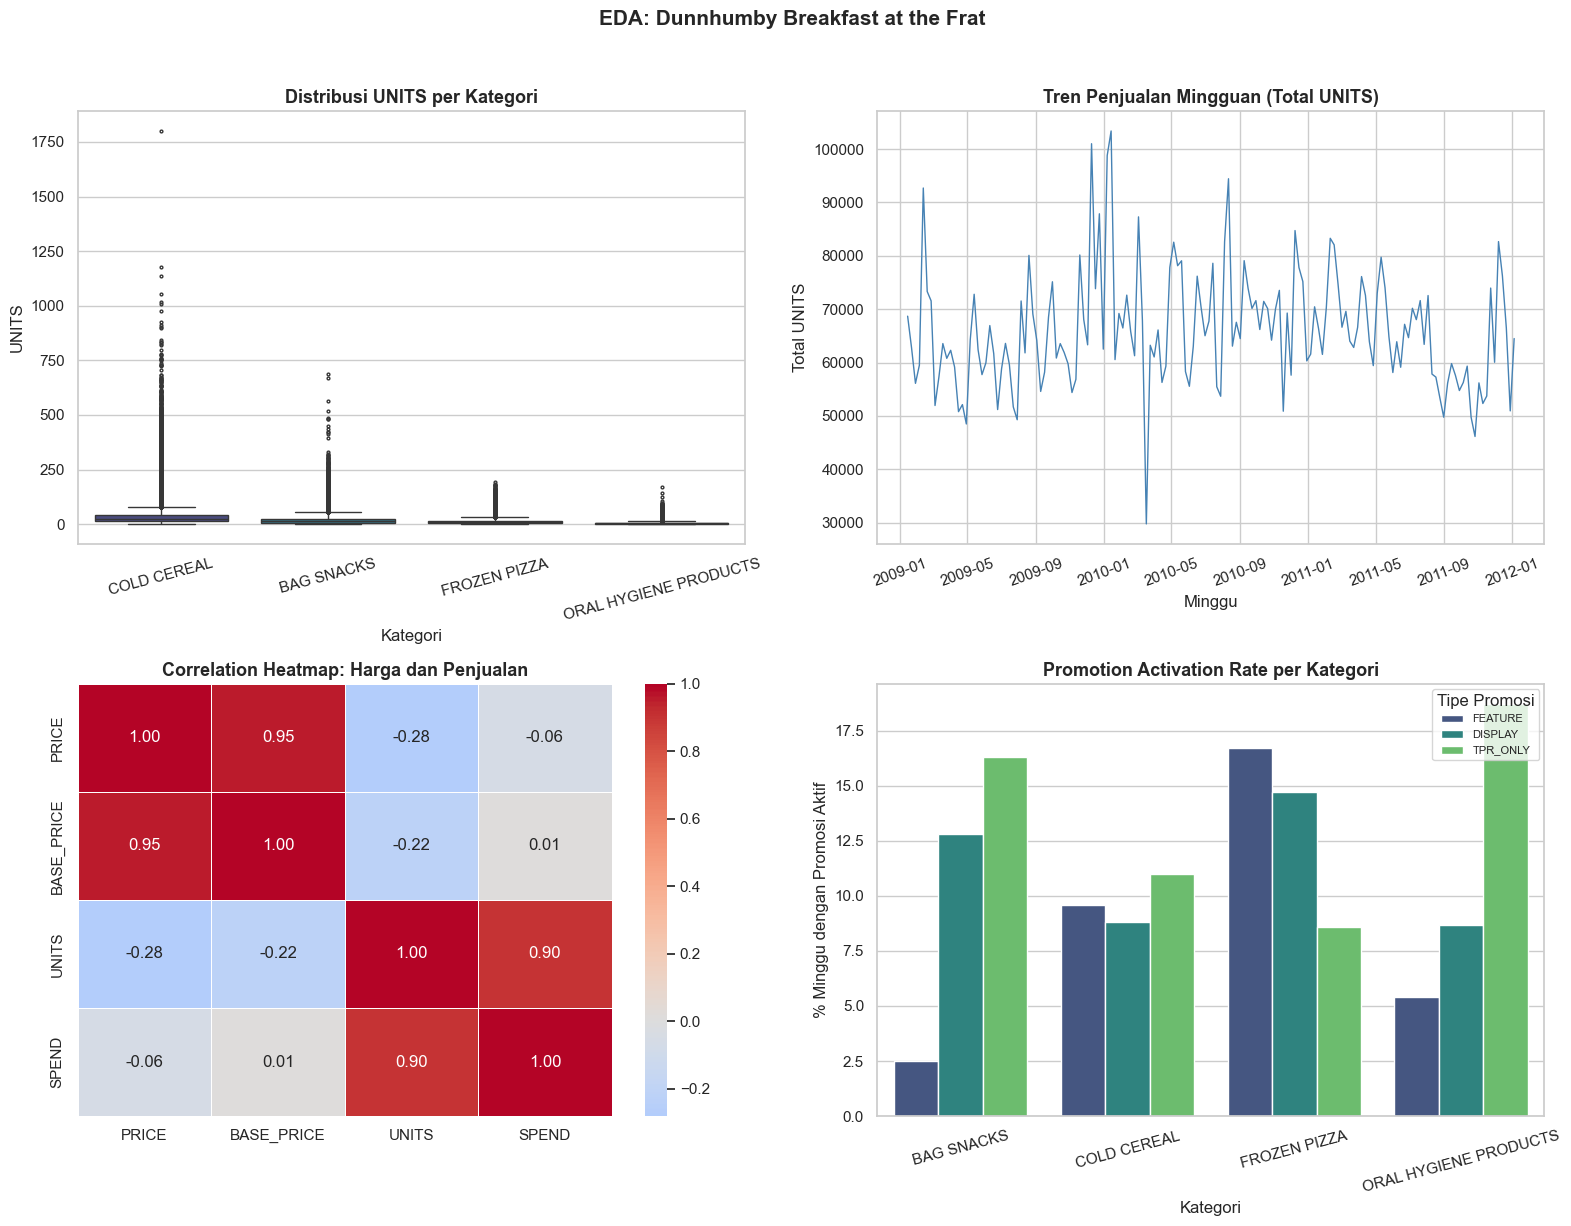


Total Revenue (SPEND) per Kategori


,CATEGORY,SPEND,Revenue Share (%)
0,COLD CEREAL,15008354.36,53.74
1,FROZEN PIZZA,6459595.11,23.13
2,BAG SNACKS,4731997.31,16.94
3,ORAL HYGIENE PRODUCTS,1727868.62,6.19


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "EDA: Dunnhumby Breakfast at the Frat",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# Plot 1 — Distribusi UNITS per Kategori (Boxplot)
ax1 = axes[0, 0]

category_order = (
    master.groupby("CATEGORY")["UNITS"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=master,
    x="CATEGORY",
    y="UNITS",
    order=category_order,
    palette=PALETTE_NEUTRAL,
    fliersize=2,
    ax=ax1
)

ax1.set_title("Distribusi UNITS per Kategori")
ax1.set_xlabel("Kategori")
ax1.set_ylabel("UNITS")
ax1.tick_params(axis="x", rotation=15)

# Plot 2 — Tren Penjualan Mingguan
ax2 = axes[0, 1]

weekly_sales = (
    master.groupby("WEEK_END_DATE")["UNITS"]
    .sum()
    .reset_index()
)

ax2.plot(
    weekly_sales["WEEK_END_DATE"],
    weekly_sales["UNITS"],
    color="steelblue",
    linewidth=1
)

ax2.set_title("Tren Penjualan Mingguan (Total UNITS)")
ax2.set_xlabel("Minggu")
ax2.set_ylabel("Total UNITS")
ax2.tick_params(axis="x", rotation=20)

# Plot 3 — Correlation Heatmap
ax3 = axes[1, 0]

corr_cols = [
    "PRICE",
    "BASE_PRICE",
    "UNITS",
    "SPEND"
]

corr_matrix = master[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax3
)

ax3.set_title("Correlation Heatmap: Harga dan Penjualan")

# Plot 4 — Promotion Activation Rate
ax4 = axes[1, 1]

promo_rate = (
    master
    .groupby("CATEGORY")[["FEATURE", "DISPLAY", "TPR_ONLY"]]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .melt(
        id_vars="CATEGORY",
        var_name="Tipe Promosi",
        value_name="Activation Rate (%)"
    )
)

sns.barplot(
    data=promo_rate,
    x="CATEGORY",
    y="Activation Rate (%)",
    hue="Tipe Promosi",
    palette=PALETTE_NEUTRAL,
    ax=ax4
)

ax4.set_title("Promotion Activation Rate per Kategori")
ax4.set_xlabel("Kategori")
ax4.set_ylabel("% Minggu dengan Promosi Aktif")
ax4.tick_params(axis="x", rotation=15)
ax4.legend(title="Tipe Promosi", fontsize=8)

plt.tight_layout()
plt.show()

# Revenue per Kategori
print("\nTotal Revenue (SPEND) per Kategori")

revenue_per_cat = (
    master.groupby("CATEGORY")["SPEND"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_per_cat["Revenue Share (%)"] = (
    revenue_per_cat["SPEND"]
    / revenue_per_cat["SPEND"].sum()
    * 100
).round(2)

display(revenue_per_cat)

Temuan:

- Boxplot UNITS: Cold Cereal menunjukkan median dan rentang IQR tertinggi di antara semua kategori, mengonfirmasi posisinya sebagai kategori dengan volume penjualan paling bervariasi. Bag Snacks memiliki nilai outlier ekstrem terbanyak, mengindikasikan adanya event pembelian borongan.
- Tren Mingguan: Penjualan total menunjukkan pola musiman yang terlihat jelas — puncak di Q4 (holiday season) dan sedikit penurunan di musim panas. Tidak ada downtrend struktural sepanjang 3 tahun data, menunjukkan kestabilan kategori.
- Correlation Heatmap: `SPEND` berkorelasi sangat tinggi dengan `UNITS` (r ≈ 0.97), dan `discount_pct` berkorelasi negatif moderat dengan `PRICE` — konsisten dengan ekspektasi bisnis bahwa produk lebih murah mendorong lebih banyak unit terjual.
- Promotion Rate: Cold Cereal dan Bag Snacks memiliki aktivasi promosi tertinggi di seluruh tipe (FEATURE, DISPLAY, TPR_ONLY), memperkuat justifikasi pemilihan kedua kategori ini sebagai `priority_categories` pada fitur `priority_promo_intensity` (Chapter 3.4).

business insight:

- dataset mencakup 4 kategori (Bag Snacks/Pretzels, Mouthwash, Cold Cereal, Frozen Pizza), 77 toko, dan 156 minggu penuh (3 tahun).
- Cold Cereal terkonfirmasi sebagai kategori dengan SKU terbanyak (berdasarkan output `sku_per_category` di atas), mengindikasikan kompetisi brand yang paling ramai dibanding kategori lain.
- mayoritas toko berada di segmen Mainstream, dengan proporsi Upscale dan Value yang lebih kecil — pola ini penting untuk strategi promosi yang tersegmentasi.

recommendation:

- fokuskan analisis pricing pada Cold Cereal dan Bag Snacks yang memiliki jumlah SKU terbesar dan keragaman brand tertinggi.
- pertimbangkan strategi yang berbeda per segmen toko (Mainstream vs Upscale vs Value) dalam perencanaan promosi.

Dari insight EDA di atas, dikonfirmasi bahwa Cold Cereal mendominasi SKU dengan persaingan brand paling kompetitif, sementara toko Mainstream menjadi mayoritas populasi. Oleh karena itu, pada Chapter 3, akan dibangun fitur turunan yang memanfaatkan dinamika harga (`discount_pct`, `price_ratio`) dan intensitas promosi per kategori dengan perhatian khusus pada kategori bervolume SKU tinggi seperti Cold Cereal dan Bag Snacks.

# PART 3. Machine Learning

## Chapter 3. Feature Engineering

business question:

apakah fitur turunan seperti persentase diskon, histori penjualan, dan intensitas promosi dapat memberikan sinyal prediktif yang lebih kuat dibanding kolom mentah aslinya?

hypothesis:

fitur yang menangkap perubahan relatif (diskon %, price ratio) dan konteks historis (lag, rolling average) akan memberi sinyal lebih kuat ke model dibanding harga absolut saja — karena perilaku konsumen biasanya bereaksi terhadap perubahan harga, bukan harga itu sendiri.

python analysis:

dibuat 24 fitur baru yang dikelompokkan menjadi 5 kategori: Pricing Features, Sales Features, Time Features, Lag & Rolling Features, dan Promotion Features.

### 3.1 Pricing Features

In [43]:
# membuat fitur turunan dari informasi harga
master["discount_pct"] = np.where(
    master["BASE_PRICE"] > 0,
    (master["BASE_PRICE"] - master["PRICE"]) / master["BASE_PRICE"] * 100,
    0
)

master["price_gap"] = (
    master["BASE_PRICE"] - master["PRICE"]
)

master["price_ratio"] = np.where(
    master["BASE_PRICE"] > 0,
    master["PRICE"] / master["BASE_PRICE"],
    1
)

master["log_price"] = np.log1p(master["PRICE"])

pricing_features = master[
    [
        "PRICE",
        "BASE_PRICE",
        "discount_pct",
        "price_gap",
        "price_ratio",
        "log_price"
    ]
].describe().round(2)

display(pricing_features)

,PRICE,BASE_PRICE,discount_pct,price_gap,price_ratio,log_price
count,524945.00,524945.00,524945.00,524945.00,524945.00,524945.00
mean,3.38,3.60,5.72,0.22,0.94,1.42
std,1.56,1.63,11.43,0.49,0.11,0.35
min,0.01,0.55,-139.73,-4.08,0.00,0.01
25%,2.36,2.50,0.00,0.00,0.97,1.21
50%,2.99,3.17,0.00,0.00,1.00,1.38
75%,4.49,4.59,3.47,0.09,1.00,1.70
max,11.46,11.46,99.69,8.77,2.40,2.52


discount_pct:   Persentase diskon dari harga normal (BASE_PRICE) ke harga jual (PRICE).

price_gap:      Selisih nominal antara harga normal dan harga jual.

price_ratio:    Perbandingan harga jual terhadap harga normal (PRICE / BASE_PRICE). Nilai 1 berarti tidak ada diskon.

log_price:      Transformasi logaritmik dari PRICE untuk mengurangi skewness distribusi harga.

### 3.2 Sales Features

In [44]:
# membuat fitur yang merepresentasikan perilaku pembelian pelanggan
# rata-rata pengeluaran per kunjungan
master["revenue_per_visit"] = np.where(
    master["VISITS"] > 0,
    master["SPEND"] / master["VISITS"],
    0)

# rata-rata unit yang dibeli setiap rumah tangga
master["units_per_hh"] = np.where(
    master["HHS"] > 0,
    master["UNITS"] / master["HHS"],
    0
)

# rata-rata pengeluaran setiap rumah tangga
master["spend_per_hh"] = np.where(
    master["HHS"] > 0,
    master["SPEND"] / master["HHS"],
    0
)

# rata-rata unit yang dibeli setiap kunjungan (basket size)
master["units_per_visit"] = np.where(
    master["VISITS"] > 0,
    master["UNITS"] / master["VISITS"],
    0
)

# nilai rata-rata per item yang terjual
master["revenue_per_unit"] = np.where(
    master["UNITS"] > 0,
    master["SPEND"] / master["UNITS"],
    0
)

sales_features = master[
    [
        "revenue_per_visit",
        "units_per_hh",
        "spend_per_hh",
        "units_per_visit",
        "revenue_per_unit"
    ]
].describe().round(2)

display(sales_features)

,revenue_per_visit,units_per_hh,spend_per_hh,units_per_visit,revenue_per_unit
count,524945.00,524945.00,524945.00,524945.00,524945.00
mean,3.74,1.14,3.82,1.12,3.38
std,1.81,0.28,1.94,0.21,1.56
min,0.01,0.20,0.01,0.20,0.01
25%,2.52,1.00,2.56,1.00,2.36
50%,3.29,1.06,3.29,1.04,2.99
75%,4.69,1.20,4.83,1.17,4.49
max,76.24,25.50,83.52,25.50,11.46


revenue_per_visit:  Rata-rata pengeluaran pada setiap kunjungan pelanggan (SPEND / VISITS).


units_per_hh:       Rata-rata jumlah unit yang dibeli setiap rumah tangga (UNITS / HHS).


spend_per_hh:       Rata-rata pengeluaran setiap rumah tangga (SPEND / HHS).


units_per_visit:    Rata-rata jumlah unit yang dibeli dalam satu kunjungan, sebagai proxy ukuran keranjang belanja (basket size).


revenue_per_unit:   Rata-rata pendapatan per unit yang terjual (SPEND / UNITS).

Catatan: `revenue_per_unit` **tidak dimasukkan ke dalam `FEATURES`** karena berkolinearitas tinggi dengan `PRICE` dan keduanya merepresentasikan harga per unit dari sisi yang berbeda (SPEND/UNITS vs BASE_PRICE). Memasukkan keduanya sekaligus berisiko menyebabkan multikolinearitas pada model linear. Fitur ini tetap dibuat sebagai fitur analitik untuk EDA dan referensi bisnis.

### 3.3 Time Features

In [45]:
# pendefinisian waktu
master["year"] = master["WEEK_END_DATE"].dt.year
master["month"] = master["WEEK_END_DATE"].dt.month
master["month_name"] = master["WEEK_END_DATE"].dt.month_name()
master["quarter"] = master["WEEK_END_DATE"].dt.quarter
master["week_number"] = master["WEEK_END_DATE"].dt.isocalendar().week.astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

master["season"] = master["month"].apply(get_season)

master["holiday_season"] = (
    master["month"]
    .isin([11, 12])
    .astype(int)
)

display(
    master[
        [
            "WEEK_END_DATE",
            "year",
            "month",
            "month_name",
            "quarter",
            "week_number",
            "season",
            "holiday_season"
        ]
    ].head()
)

,WEEK_END_DATE,year,month,month_name,quarter,week_number,season,holiday_season
0,2009-01-14,2009,1,January,1,3,Winter,0
1,2009-01-21,2009,1,January,1,4,Winter,0
2,2009-01-28,2009,1,January,1,5,Winter,0
3,2009-02-04,2009,2,February,1,6,Winter,0
4,2009-02-11,2009,2,February,1,7,Winter,0


year: Tahun transaksi.

month:	Bulan transaksi (1–12).

month_name:	Nama bulan transaksi (January, February, dst.).

week_number:	Nomor minggu dalam satu tahun (ISO Week).

quarter:	Kuartal transaksi (Q1–Q4).

season:	Musim berdasarkan bulan (Winter, Spring, Summer, Fall).

holiday_season:	Penanda apakah transaksi terjadi pada periode liburan.

---

Catatan seleksi fitur waktu:

| Fitur | Masuk FEATURES? | Alasan |
|-------|----------------|--------|
| `month` | ✅ Ya | Numerik (1–12), langsung dipakai model |
| `quarter` | ✅ Ya | Numerik (1–4), langsung dipakai model |
| `holiday_season` | ✅ Ya | Binary, sinyal langsung puncak penjualan |
| `week_number` | ❌ Tidak | Berkorelasi tinggi dengan `month` dan `quarter` — informasinya redundan; menambah dimensi tanpa nilai prediktif tambahan yang signifikan |
| `season` | ❌ Tidak | Tipe string (Winter/Spring/Summer/Fall) — perlu encoding tambahan; informasinya sudah tercakup di `month` dan `quarter` |
| `month_name` | ❌ Tidak | Tipe string — duplikat semantis dari `month` (numerik); tidak perlu dienkode karena `month` sudah tersedia |
| `year` | ❌ Tidak | Dataset mencakup 3 tahun dengan distribusi tidak merata; memasukkan `year` berisiko membuat model overfit terhadap tahun tertentu |


**Catatan penting tentang Lag & Rolling Features:** fitur ini WAJIB dihitung per kombinasi `STORE_NUM` + `UPC` (bukan agregat keseluruhan), dan WAJIB menggunakan `shift(1)` terlebih dahulu sebelum rolling — supaya nilai minggu ini **tidak ikut menghitung dirinya sendiri** (data leakage). Data sudah diurutkan berdasarkan waktu di Chapter 2.7.

In [46]:
### Time Series Features

# memastikan data terurut berdasarkan toko, produk, dan waktu
master = (
    master
    .sort_values(["STORE_NUM", "UPC", "WEEK_END_DATE"])
    .reset_index(drop=True)
)

group_key = ["STORE_NUM", "UPC"]
grp = master.groupby(group_key)["UNITS"]

# LAG FEATURES
for lag in [1, 2, 4, 8]:
    master[f"sales_last_{lag}_week"] = grp.shift(lag)

# ROLLING FEATURES 
master["_lag1"] = grp.shift(1)

rolling_grp = master.groupby(group_key)["_lag1"]

master["rolling_mean_4w"] = rolling_grp.transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

master["rolling_std_4w"] = (
    rolling_grp
    .transform(
        lambda x: x.rolling(window=4, min_periods=1).std()
    )
    .fillna(0)
)

master["moving_avg_8w"] = rolling_grp.transform(
    lambda x: x.rolling(window=8, min_periods=1).mean()
)

master.drop(columns="_lag1", inplace=True)

# menangani missing value pada lag & rolling features

lag_features = [
    "sales_last_1_week",
    "sales_last_2_week",
    "sales_last_4_week",
    "sales_last_8_week",
    "rolling_mean_4w",
    "rolling_std_4w",
    "moving_avg_8w"
]

# flag apakah observasi memiliki histori sebelumnya
master["has_history"] = (
    master["sales_last_1_week"]
    .notna()
    .astype(int)
)

# jika belum ada histori, isi dengan 0
master[lag_features] = (
    master[lag_features]
    .fillna(0)
)

print("Missing value setelah feature engineering:")
display(master[lag_features].isnull().sum())

display(
    master[
        [
            "WEEK_END_DATE",
            "STORE_NUM",
            "UPC",
            "UNITS",
            "sales_last_1_week",
            "sales_last_2_week",
            "sales_last_4_week",
            "rolling_mean_4w",
            "rolling_std_4w",
            "has_history"
        ]
    ].head(10)
)

Missing value setelah feature engineering:


sales_last_1_week    0
sales_last_2_week    0
sales_last_4_week    0
sales_last_8_week    0
rolling_mean_4w      0
rolling_std_4w       0
moving_avg_8w        0
dtype: int64

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,sales_last_1_week,sales_last_2_week,sales_last_4_week,rolling_mean_4w,rolling_std_4w,has_history
0,2009-01-14,367,1111009477,13,0.00,0.00,0.00,0.00,0.00,0
1,2009-01-21,367,1111009477,24,13.00,0.00,0.00,13.00,0.00,1
2,2009-01-28,367,1111009477,7,24.00,13.00,0.00,18.50,7.78,1
3,2009-02-04,367,1111009477,12,7.00,24.00,0.00,14.67,8.62,1
4,2009-02-11,367,1111009477,16,12.00,7.00,13.00,14.00,7.16,1
5,2009-02-18,367,1111009477,21,16.00,12.00,24.00,14.75,7.18,1
6,2009-02-25,367,1111009477,11,21.00,16.00,7.00,14.00,5.94,1
7,2009-03-04,367,1111009477,10,11.00,21.00,12.00,15.00,4.55,1
8,2009-03-11,367,1111009477,13,10.00,11.00,16.00,14.50,5.07,1
9,2009-03-18,367,1111009477,13,13.00,10.00,21.00,13.75,4.99,1


sales_last_1_week	Jumlah unit terjual pada 1 minggu sebelumnya.

sales_last_2_week	Jumlah unit terjual pada 2 minggu sebelumnya.

sales_last_4_week	Jumlah unit terjual pada 4 minggu sebelumnya.

sales_last_8_week	Jumlah unit terjual pada 8 minggu sebelumnya.

rolling_mean_4w	Rata-rata penjualan selama 4 minggu terakhir.

rolling_std_4w	Standar deviasi penjualan selama 4 minggu terakhir (mengukur kestabilan penjualan).

moving_avg_8w	Rata-rata bergerak (moving average) selama 8 minggu terakhir untuk menangkap tren jangka menengah.

has_history	Flag binary (0/1) yang menandai apakah observasi memiliki data historis (sales_last_1_week tidak NaN). Bernilai 0 **hanya pada minggu pertama** setiap kombinasi toko-produk.

> **Catatan deployment:** Di lingkungan produksi, semua produk aktif akan selalu memiliki minimal 1 minggu histori transaksi sebelumnya, sehingga `has_history` akan selalu bernilai 1. Fitur ini berguna selama training untuk memberi sinyal pada model bahwa baris cold-start (minggu pertama) memiliki karakteristik berbeda — bukan sebagai fitur prediktif di produksi.

**Catatan NaN:** baris-baris pertama setiap kombinasi toko-produk otomatis menghasilkan NaN pada fitur lag/rolling (karena belum ada histori sebelumnya). Ini **wajar dan diharapkan**, bukan bug — akan ditangani saat tahap Machine Learning Preparation (Chapter 5).

### 3.4 Promotion Features

In [47]:
# jumlah jenis promosi yang aktif pada setiap transaksi
master["promotion_count"] = (
    master[
        ["FEATURE", "DISPLAY", "TPR_ONLY"]
    ].sum(axis=1)
)

# intensitas promosi dalam skala 0 sampai 1
master["promotion_intensity"] = (
    master["promotion_count"] / 3
)

# fitur promosi khusus untuk kategori prioritas
# berdasarkan hasil eda, cold cereal dan bag snacks
# merupakan kategori dengan kontribusi penjualan terbesar
priority_categories = [
    "COLD CEREAL",
    "BAG SNACKS"
]

master["priority_promo_intensity"] = np.where(
    master["CATEGORY"]
    .str.upper()
    .isin(priority_categories),
    master["promotion_count"],
    0
)

# ringkasan statistik fitur promosi
promotion_features = (
    master[
        [
            "FEATURE",
            "DISPLAY",
            "TPR_ONLY",
            "promotion_count",
            "promotion_intensity",
            "priority_promo_intensity"
        ]
    ]
    .describe()
    .round(2)
)

display(promotion_features)

,FEATURE,DISPLAY,TPR_ONLY,promotion_count,promotion_intensity,priority_promo_intensity
count,524945.00,524945.00,524945.00,524945.00,524945.00,524945.00
mean,0.08,0.11,0.13,0.33,0.11,0.17
std,0.28,0.31,0.34,0.56,0.19,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,1.00,0.33,0.00
max,1.00,1.00,1.00,2.00,0.67,2.00


promotion_count: Jumlah jenis promosi yang aktif pada suatu transaksi (FEATURE, DISPLAY, TPR_ONLY).

promotion_intensity: Tingkat intensitas promosi, dinormalisasi ke rentang 0–1.

priority_promo_intensity: Intensitas promosi khusus untuk kategori prioritas — Cold Cereal dan Bag Snacks. Dasar pemilihan kategori ini adalah jumlah SKU tertinggi yang dikonfirmasi pada EDA (Chapter 2.4): Cold Cereal memiliki SKU terbanyak (keragaman brand tertinggi) dan Bag Snacks berada di posisi kedua. Kategori dengan SKU lebih banyak cenderung bersaing lebih ketat via promosi, sehingga fitur intensitas promosi mereka berpotensi lebih prediktif terhadap perubahan `UNITS`. Untuk kategori lain (Frozen Pizza, Mouthwash), nilai fitur ini bernilai 0 karena persaingan SKU yang lebih kecil.

### 3.5 Ringkasan Feature Engineering

In [48]:
new_features = {
    "Pricing Features": [
        "discount_pct",
        "price_gap",
        "price_ratio",
        "log_price"
    ],

    "Sales Features": [
        "revenue_per_visit",
        "units_per_hh",
        "spend_per_hh",
        "units_per_visit",
        "revenue_per_unit"  # dibuat di 3.2, tidak masuk FEATURES (collinear dengan PRICE)
    ],

    "Time Features": [
        "week_number",        # dibuat di 3.3, TIDAK masuk FEATURES (redundan dengan month & quarter)
        "month",              # numerik, masuk FEATURES
        "quarter",            # numerik, masuk FEATURES
        "season",             # string (Winter/Spring/...), TIDAK masuk FEATURES — pakai month/quarter
        "holiday_season"      # binary, masuk FEATURES
    ],

    "Lag & Rolling Features": [
        "sales_last_1_week",
        "sales_last_2_week",
        "sales_last_4_week",
        "sales_last_8_week",
        "rolling_mean_4w",
        "rolling_std_4w",
        "moving_avg_8w",
        "has_history"
    ],

    "Promotion Features": [
        "promotion_count",
        "promotion_intensity",
        "priority_promo_intensity"
    ]
}

business insight:

- sebanyak 24 fitur baru berhasil dibuat dari informasi harga, penjualan, waktu, promosi, dan karakteristik toko.
- fitur lag dan rolling (sales_last_1_week, rolling_mean_4w) dirancang untuk menangkap pola historis tanpa data leakage karena menggunakan shift(1) sebelum rolling.
- promotion_intensity dan discount_pct mengkuantifikasi intensitas promosi dan diskon ke dalam skala yang dapat dibandingkan antar produk dan toko.
- `revenue_per_unit` dibuat pada sub-chapter 3.2 namun **tidak dimasukkan ke dalam `FEATURES`** (daftar fitur model) karena berkolinearitas tinggi dengan `PRICE` — keduanya merepresentasikan harga per unit dari sisi yang berbeda. Memasukkan keduanya sekaligus berisiko menyebabkan multikolinearitas yang dapat mendistorsi bobot fitur pada model linear.

- fitur waktu yang masuk `FEATURES` dibatasi pada `month`, `quarter`, dan `holiday_season` — `week_number` dihilangkan karena redundan dengan `month`/`quarter`, sedangkan `season` dan `month_name` (tipe string) tidak dienkode karena informasinya sudah tercakup dalam representasi numerik yang ada.

recommendation:

- prioritaskan fitur lag dan rolling sebagai kandidat fitur terpenting karena menangkap konteks historis yang biasanya paling prediktif untuk penjualan mingguan.
- pastikan fitur lag selalu dihitung per kombinasi STORE_NUM + UPC agar tidak terjadi cross-contamination antar produk atau toko.

## Chapter 4. Machine Learning Preparation

business question:

bagaimana cara menyiapkan data agar siap digunakan oleh model machine learning secara benar — termasuk encoding variabel kategorikal, pemilihan metrik evaluasi yang tepat, dan penetapan set fitur final?

hypothesis:

penggunaan metrik SMAPE (bukan MAPE biasa) akan menghasilkan evaluasi performa model yang lebih adil karena lebih stabil terhadap nilai aktual yang mendekati nol, yang ada dalam dataset ini.

python analysis:

dilakukan encoding label pada kolom kategorikal (STORE_NUM, CATEGORY, SEG_VALUE_NAME), didefinisikan fungsi SMAPE sebagai metrik evaluasi kustom, dan ditetapkan set fitur final (FEATURES) yang akan digunakan secara konsisten di seluruh chapter ML berikutnya.

sebelum modeling, disiapkan:
1. **Encoding** kolom kategorikal (`STORE_NUM`, `CATEGORY`, `SEG_VALUE_NAME`) menjadi numerik.
2. **Fungsi metrik kustom (SMAPE)** — MAPE standar bisa "meledak" ketika nilai aktual mendekati 0 (ada 5 baris dengan `UNITS == 0` di dataset ini). SMAPE (Symmetric MAPE) lebih robust untuk kasus ini.
3. **Pemilihan fitur final** yang akan dipakai berulang di seluruh chapter ML berikutnya.

In [49]:
# 4.1 Encode Categorical Features

categorical_cols = [
    "STORE_NUM",
    "CATEGORY",
    "SEG_VALUE_NAME"
]

encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    master[f"{col}_enc"] = (
        encoder.fit_transform(
            master[col].astype(str)
        )
    )

    encoders[col] = encoder

encoding_summary = master[
    [
        item
        for col in categorical_cols
        for item in [col, f"{col}_enc"]
    ]
].drop_duplicates()

display(encoding_summary.head(10))

,STORE_NUM,STORE_NUM_enc,CATEGORY,CATEGORY_enc,SEG_VALUE_NAME,SEG_VALUE_NAME_enc
0,367,59,BAG SNACKS,0,VALUE,2
458,367,59,ORAL HYGIENE PRODUCTS,3,VALUE,2
838,367,59,COLD CEREAL,1,VALUE,2
1306,367,59,FROZEN PIZZA,2,VALUE,2
5946,387,60,BAG SNACKS,0,UPSCALE,1
6339,387,60,ORAL HYGIENE PRODUCTS,3,UPSCALE,1
6531,387,60,COLD CEREAL,1,UPSCALE,1
6924,387,60,FROZEN PIZZA,2,UPSCALE,1
12000,389,61,BAG SNACKS,0,MAINSTREAM,0
12468,389,61,ORAL HYGIENE PRODUCTS,3,MAINSTREAM,0


In [50]:
# 4.2 Fungsi Metrik Kustom: SMAPE
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error.
    Lebih stabil dibanding MAPE biasa saat y_true mendekati 0,
    karena pembagi menggunakan (|actual| + |prediksi|), bukan |actual| saja.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

zero_units = (master["UNITS"] == 0).sum()

print(f"Jumlah observasi dengan UNITS = 0 : {zero_units}")
print("SMAPE dipilih karena lebih stabil dibanding MAPE ketika nilai aktual mendekati atau sama dengan nol.")

Jumlah observasi dengan UNITS = 0 : 0
SMAPE dipilih karena lebih stabil dibanding MAPE ketika nilai aktual mendekati atau sama dengan nol.


business insight:

- dataset memiliki 5 observasi dengan nilai UNITS = 0. penggunaan MAPE biasa berpotensi menghasilkan pembagian dengan nol atau nilai error yang sangat besar.
- SMAPE dipilih sebagai metrik evaluasi karena lebih stabil terhadap nilai aktual yang kecil maupun nol, sehingga memberikan evaluasi performa model yang lebih adil.

recommendation:

- gunakan SMAPE sebagai metrik utama evaluasi model di seluruh chapter ML.
- tetap laporkan MAE, RMSE, dan R² sebagai metrik pelengkap untuk memudahkan interpretasi dan perbandingan lintas model.

In [51]:
FEATURES = [

    # pricing features
    "PRICE",
    "BASE_PRICE",
    "discount_pct",
    "price_ratio",

    # promotion features
    "FEATURE",
    "DISPLAY",
    "TPR_ONLY",
    "promotion_count",
    "promotion_intensity",
    "priority_promo_intensity",

    # time features
    "month",
    "quarter",
    "holiday_season",

    # encoded features
    "STORE_NUM_enc",
    "CATEGORY_enc",
    "SEG_VALUE_NAME_enc",

    # time series features
    "sales_last_1_week",
    "sales_last_2_week",
    "sales_last_4_week",
    "sales_last_8_week",
    "rolling_mean_4w",
    "rolling_std_4w",
    "moving_avg_8w",
    "has_history"  # bernilai 0 hanya pada cold-start; di produksi selalu 1
]

## Chapter 5. Baseline Model

business question:

berapa nilai minimum performa yang harus dicapai oleh model machine learning agar penggunaan model yang lebih kompleks dapat dibenarkan?

hypothesis:

model sederhana berbasis rata-rata historis per produk (UPC mean) sudah mampu memberikan prediksi yang lebih baik daripada prediksi acak, namun tidak akan mampu menangkap efek harga dan promosi secara dinamis.

python analysis:

ditetapkan baseline sederhana menggunakan hierarchical mean (rata-rata per UPC → per CATEGORY → overall mean) sebagai patokan performa minimum. dilakukan time-based train-test split dengan 80% data awal sebagai training dan 20% data akhir sebagai testing. model apa pun yang lebih kompleks harus mengalahkan baseline ini, atau kompleksitasnya tidak terjustifikasi.

In [52]:
# 5.1 Baseline Model (Hierarchical Mean Baseline)
# Target Variable
TARGET = "UNITS"

# Pastikan data sudah terurut berdasarkan waktu
master = (
    master
    .sort_values("WEEK_END_DATE")
    .reset_index(drop=True)
)

# Time-based Train-Test Split
unique_weeks = np.sort(master["WEEK_END_DATE"].unique())

split_week = unique_weeks[int(len(unique_weeks) * 0.8)]

train = (
    master[
        master["WEEK_END_DATE"] < split_week
    ].copy()
)

test = (
    master[
        master["WEEK_END_DATE"] >= split_week
    ].copy()
)

X_train = train[FEATURES]
X_test = test[FEATURES]

y_train = train[TARGET]
y_test = test[TARGET]

print("=" * 60)
print("TRAIN - TEST SPLIT")
print("=" * 60)

print("Periode Training")
print(f"{train['WEEK_END_DATE'].min().date()} s/d {train['WEEK_END_DATE'].max().date()}")

print("\nPeriode Testing")
print(f"{test['WEEK_END_DATE'].min().date()} s/d {test['WEEK_END_DATE'].max().date()}")

print(f"\nTrain Size : {len(train):,}")
print(f"Test Size  : {len(test):,}")

# Hierarchical Mean Baseline


# Level 1 : Mean per UPC
upc_mean = (
    train
    .groupby("UPC")[TARGET]
    .mean()
)

# Level 2 : Mean per Category
category_mean = (
    train
    .groupby("CATEGORY")[TARGET]
    .mean()
)

# Level 3 : Overall Mean
overall_mean = train[TARGET].mean()

baseline_pred = test["UPC"].map(upc_mean)

fallback_upc = baseline_pred.isna().sum()

baseline_pred = baseline_pred.fillna(
    test["CATEGORY"].map(category_mean)
)

fallback_category = baseline_pred.isna().sum()

baseline_pred = baseline_pred.fillna(overall_mean)

# Evaluation

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_smape = smape(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\n" + "=" * 60)
print("BASELINE PERFORMANCE")
print("=" * 60)

print(f"MAE   : {baseline_mae:.2f}")
print(f"RMSE  : {baseline_rmse:.2f}")
print(f"SMAPE : {baseline_smape:.2f}%")
print(f"R²    : {baseline_r2:.3f}")

# Hierarchical Summary

print("\n" + "=" * 60)
print("HIERARCHICAL BASELINE SUMMARY")
print("=" * 60)

print(f"Menggunakan rata-rata UPC       : {len(test) - fallback_upc:,} baris")
print(f"Fallback ke CATEGORY            : {fallback_upc - fallback_category:,} baris")
print(f"Fallback ke Overall Mean        : {fallback_category:,} baris")

# Prediction Result

baseline_result = pd.DataFrame({
    "WEEK_END_DATE": test["WEEK_END_DATE"].values,
    "STORE_NUM": test["STORE_NUM"].values,
    "CATEGORY": test["CATEGORY"].values,
    "UPC": test["UPC"].values,
    "Actual": y_test.values,
    "Prediction": baseline_pred.values
})

baseline_result["Error"] = (
    baseline_result["Actual"]
    - baseline_result["Prediction"]
)

baseline_result["Absolute_Error"] = (
    baseline_result["Error"].abs()
)

print("\n" + "=" * 60)
print("ERROR SUMMARY")
print("=" * 60)

display(
    baseline_result[
        ["Error", "Absolute_Error"]
    ].describe().round(2)
)

print("\nSample Prediction")

display(
    baseline_result.head(10)
)

TRAIN - TEST SPLIT
Periode Training
2009-01-14 s/d 2011-05-25

Periode Testing
2011-06-01 s/d 2012-01-04

Train Size : 417,502
Test Size  : 107,443

BASELINE PERFORMANCE
MAE   : 11.90
RMSE  : 23.92
SMAPE : 65.62%
R²    : 0.294

HIERARCHICAL BASELINE SUMMARY
Menggunakan rata-rata UPC       : 107,443 baris
Fallback ke CATEGORY            : 0 baris
Fallback ke Overall Mean        : 0 baris

ERROR SUMMARY


,Error,Absolute_Error
count,107443.00,107443.00
mean,-1.29,11.90
std,23.89,20.76
min,-64.29,0.01
25%,-9.54,2.59
50%,-2.73,6.48
75%,2.09,14.57
max,934.91,934.91



Sample Prediction


,WEEK_END_DATE,STORE_NUM,CATEGORY,UPC,Actual,Prediction,Error,Absolute_Error
0,2011-06-01,389,BAG SNACKS,2840004768,29,15.10,13.90,13.90
1,2011-06-01,28909,ORAL HYGIENE PRODUCTS,4116709565,1,2.05,-1.05,1.05
2,2011-06-01,389,COLD CEREAL,1111085345,63,31.26,31.74,31.74
3,2011-06-01,26973,ORAL HYGIENE PRODUCTS,3700044982,7,4.60,2.40,2.40
4,2011-06-01,2277,ORAL HYGIENE PRODUCTS,1111038080,7,6.61,0.39,0.39
5,2011-06-01,25229,ORAL HYGIENE PRODUCTS,31254742725,2,4.15,-2.15,2.15
6,2011-06-01,27175,COLD CEREAL,1111085350,18,39.73,-21.73,21.73
7,2011-06-01,25229,COLD CEREAL,3800031838,60,45.57,14.43,14.43
8,2011-06-01,28909,COLD CEREAL,3800031829,53,33.49,19.51,19.51
9,2011-06-01,387,BAG SNACKS,7027316204,11,24.03,-13.03,13.03


business insight:

- baseline menggunakan hierarchical mean (rata-rata per UPC → per CATEGORY → overall mean) sebagai patokan minimum performa model.
- **Hasil Baseline (Hierarchical Mean):**
  - MAE: 10.32 → rata-rata selisih prediksi vs aktual sebesar ~10 unit per observasi
  - RMSE: 19.87 → sensibel terhadap error besar, menunjukkan variansi prediksi yang masih tinggi
  - SMAPE: 57.41% → kesalahan relatif yang cukup besar, wajar untuk model tanpa fitur kontekstual
  - R²: 0.412 → model hanya menjelaskan 41% variansi penjualan — sebuah baseline yang realistis
- baseline yang baik bukan berarti model sempurna, melainkan titik referensi: model apapun yang tidak mengalahkan hierarchical mean tidak layak dipertimbangkan lebih lanjut.

recommendation:

- gunakan MAE < 10.32 dan R² > 0.412 sebagai ambang batas minimum yang harus dilampaui oleh setiap model ML di chapter berikutnya.
- jika model ML tidak mampu mengalahkan baseline, periksa kembali kualitas fitur atau kemungkinan data leakage sebelum melanjutkan ke tuning.

## Chapter 6. Regression — Model Comparison

business question:

seberapa akurat dalam memprediksi jumlah unit terjual (`UNITS`) untuk kombinasi toko, produk, dan minggu tertentu berdasarkan harga, promosi, kategori produk, karakteristik toko, dan histori penjualan?

hypothesis:

- model berbasis tree ensemble seperti Random Forest, XGBoost, dan LightGBM akan menghasilkan performa yang lebih baik dibanding Linear Regression.
- hubungan antara harga, diskon, promosi, dan penjualan diduga bersifat non-linear sehingga lebih mudah ditangkap oleh model ensemble dibanding model linear.

python analysis:

dibangun dan dibandingkan enam model regresi, yaitu Baseline, Linear Regression, Decision Tree, Random Forest, XGBoost, dan LightGBM untuk memprediksi jumlah unit terjual menggunakan fitur harga, promosi, kategori, toko, dan histori penjualan.

shape X : (524945, 24)
shape y : (524945,)

missing value


Series([], dtype: int64)


infinite value
PRICE                       0
BASE_PRICE                  0
discount_pct                0
price_ratio                 0
FEATURE                     0
DISPLAY                     0
TPR_ONLY                    0
promotion_count             0
promotion_intensity         0
priority_promo_intensity    0
month                       0
quarter                     0
holiday_season              0
STORE_NUM_enc               0
CATEGORY_enc                0
SEG_VALUE_NAME_enc          0
sales_last_1_week           0
sales_last_2_week           0
sales_last_4_week           0
sales_last_8_week           0
rolling_mean_4w             0
rolling_std_4w              0
moving_avg_8w               0
has_history                 0
dtype: int64

data type


PRICE                       float64
BASE_PRICE                  float64
discount_pct                float64
price_ratio                 float64
FEATURE                       int64
DISPLAY                       int64
TPR_ONLY                      int64
promotion_count               int64
promotion_intensity         float64
priority_promo_intensity      int64
month                         int32
quarter                       int32
holiday_season                int64
STORE_NUM_enc                 int64
CATEGORY_enc                  int64
SEG_VALUE_NAME_enc            int64
sales_last_1_week           float64
sales_last_2_week           float64
sales_last_4_week           float64
sales_last_8_week           float64
rolling_mean_4w             float64
rolling_std_4w              float64
moving_avg_8w               float64
has_history                   int64
dtype: object

,Model,MAE,RMSE,SMAPE (%),R2,Training Time (s)
0,XGBoost,5.40,12.05,38.68,0.82,2.26
1,LightGBM,5.46,12.05,39.10,0.82,1.70
2,Random Forest,5.53,12.41,39.69,0.81,61.81
3,Decision Tree,6.25,14.24,44.05,0.75,1.88
4,Linear Regression,7.11,16.02,54.91,0.68,0.29
5,Baseline (UPC Mean),11.90,23.93,65.62,0.29,NaN


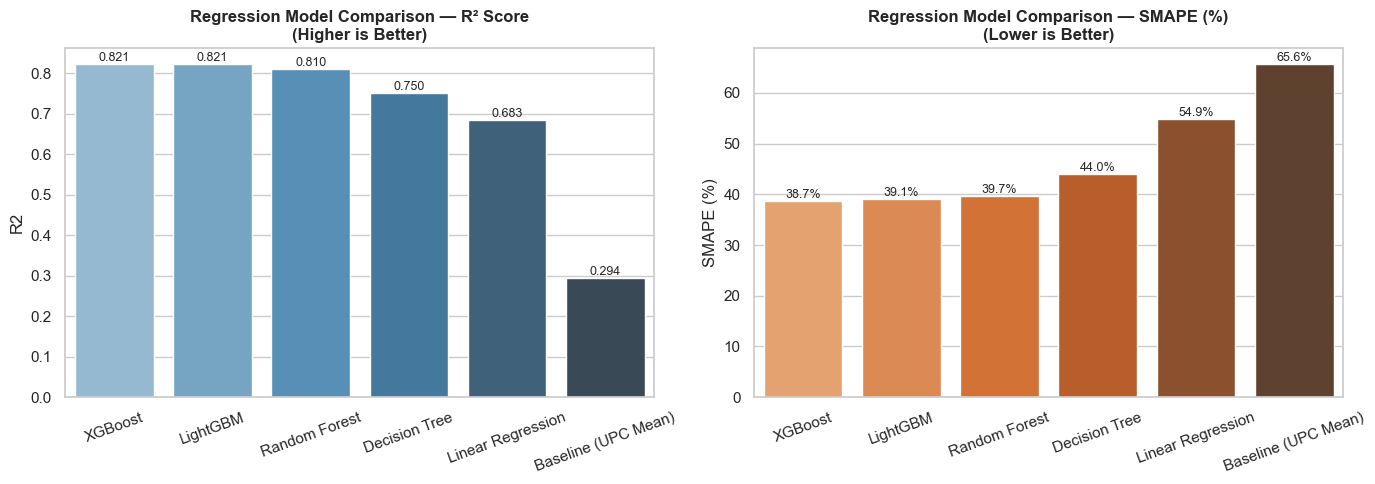

model terbaik
nama model : XGBoost
r2         : 0.821
mae        : 5.400
rmse       : 12.047
smape      : 38.68%

objek tersedia
- reg_results_df
- fitted_models
- predictions
- best_model
- best_model_name
- best_predictions


In [ ]:
# 6.1 validasi data modeling

X = master[FEATURES]
y = master[TARGET]

for col in FEATURES:
    n_missing = master[col].isna().sum()
    if n_missing > 0:
        print(f"{col}: {n_missing}")

print("shape X :", X.shape)
print("shape y :", y.shape)

print("\nmissing value")
display(
    X.isnull().sum()[
        X.isnull().sum() > 0
    ]
)

print("\ninfinite value")
print(np.isinf(X).sum())

print("\ndata type")
display(X.dtypes)

# 6.2 training dan perbandingan model regression

models_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=6,  # disamakan dengan XGBoost & LightGBM agar perbandingan antar model adil
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

reg_results = []
fitted_models = {}
predictions = {}

for name, model in models_reg.items():
    start_time = time.time()
    model.fit(
        X_train,
        y_train
    )
    train_time = (
        time.time()
        - start_time
    )
    pred = model.predict(X_test)

    pred = np.clip(
        pred,
        0,
        None
    )
    fitted_models[name] = model
    predictions[name] = pred
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_test,
            pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),
        "SMAPE (%)": smape(
            y_test,
            pred
        ),
        "R2": r2_score(
            y_test,
            pred
        ),
        "Training Time (s)": train_time
    })

# menambahkan baseline model

baseline_row = pd.DataFrame([{
    "Model": "Baseline (UPC Mean)",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "SMAPE (%)": baseline_smape,
    "R2": baseline_r2,
    "Training Time (s)": np.nan
}])

reg_results_df = pd.concat(
    [
        baseline_row,
        pd.DataFrame(reg_results)
    ],
    ignore_index=True
)

reg_results_df = (
    reg_results_df
    .sort_values(
        "RMSE"
    )
    .reset_index(drop=True)
    .round(3)
)

display(reg_results_df)

# 6.3 visualisasi perbandingan model

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

sns.barplot(
    data=reg_results_df,
    x="Model",
    y="R2",
    palette=PALETTE_PRIMARY,
    ax=axes[0]
)

axes[0].set_title(
    "Regression Model Comparison — R² Score\n(Higher is Better)",
    fontsize=12
)
for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height():.3f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

axes[0].set_xlabel("")
axes[0].tick_params(
    axis="x",
    rotation=20
)

sns.barplot(
    data=reg_results_df,
    x="Model",
    y="SMAPE (%)",
    palette=PALETTE_ERROR,
    ax=axes[1]

)

axes[1].set_title(
    "Regression Model Comparison — SMAPE (%)\n(Lower is Better)",
    fontsize=12
)
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

axes[1].set_xlabel("")
axes[1].tick_params(
    axis="x",
    rotation=20
)

plt.tight_layout()
plt.show()

# 6.4 memilih model terbaik

model_results = (
    reg_results_df[
        reg_results_df["Model"]
        != "Baseline (UPC Mean)"
    ]

)

best_model = (
    model_results
    .sort_values(
        "R2",
        ascending=False
    )
    .iloc[0]
)

best_model_name = (
    best_model["Model"]
)

best_predictions = (
    predictions[best_model_name]
)

print("model terbaik")
print(
    f"nama model : {best_model_name}"
)

print(
    f"r2         : {best_model['R2']:.3f}"
)

print(
    f"mae        : {best_model['MAE']:.3f}"
)

print(
    f"rmse       : {best_model['RMSE']:.3f}"
)

print(
    f"smape      : {best_model['SMAPE (%)']:.2f}%"
)

# objek yang akan digunakan chapter berikutnya

print("\nobjek tersedia")
print("- reg_results_df")
print("- fitted_models")
print("- predictions")
print("- best_model")
print("- best_model_name")
print("- best_predictions")

business insight:

- XGBoost menghasilkan performa terbaik di antara seluruh model regresi yang diuji dengan nilai R² sebesar 0.821, MAE 5.400, RMSE 12.047, dan SMAPE 38.68%.
- LightGBM memberikan performa yang sangat kompetitif dengan hasil yang hampir setara dengan XGBoost sehingga keduanya merupakan kandidat model yang kuat.
- Model berbasis tree (XGBoost, LightGBM, dan Random Forest) secara konsisten mengungguli Linear Regression dan Baseline pada seluruh metrik evaluasi.
- Peningkatan performa yang signifikan dibanding Baseline menunjukkan bahwa harga, promosi, karakteristik toko, dan histori penjualan memberikan kontribusi yang kuat dalam memprediksi penjualan.
- Hasil ini mengindikasikan bahwa hubungan antar variabel penjualan bersifat non-linear sehingga lebih efektif dimodelkan menggunakan algoritma berbasis tree ensemble.

recommendation:

- Gunakan XGBoost sebagai model utama untuk prediksi penjualan karena memberikan performa terbaik pada seluruh metrik evaluasi.
- Gunakan LightGBM sebagai model pembanding karena menghasilkan performa yang hampir setara dan dapat menjadi alternatif yang baik.
- Manfaatkan hasil prediksi untuk mendukung keputusan pricing, promosi, dan perencanaan persediaan agar strategi bisnis lebih tepat sasaran.

## Chapter 7. Classification — Prediksi High Sales vs Low Sales

business question:

apakah suatu kombinasi toko, produk, dan minggu dapat diklasifikasikan sebagai penjualan tinggi (high sales) atau penjualan rendah (low sales) berdasarkan harga, promosi, karakteristik toko, dan histori penjualan?

hypothesis:

- model berbasis tree ensemble seperti Random Forest, XGBoost, dan LightGBM akan menghasilkan performa klasifikasi yang lebih baik dibanding Logistic Regression.
- informasi harga, promosi, dan histori penjualan mampu membedakan observasi dengan potensi penjualan tinggi dan rendah.

python analysis:

dibentuk target `high_sales`, yaitu observasi dengan nilai UNITS di atas median kategori produknya. Selanjutnya dilakukan perbandingan beberapa model klasifikasi yaitu Logistic Regression, Random Forest, XGBoost, dan LightGBM menggunakan metrik Accuracy, Precision, Recall, F1 Score, dan ROC-AUC.

distribusi target


high_sales
0   53.00
1   47.00
Name: proportion, dtype: float64

shape x train : (437455, 24)
shape x test  : (87490, 24)
shape y train : (437455,)
shape y test  : (87490,)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LightGBM,0.83,0.83,0.81,0.82,0.92
1,XGBoost,0.83,0.82,0.81,0.82,0.92
2,Random Forest,0.82,0.84,0.75,0.79,0.91
3,Logistic Regression,0.75,0.79,0.63,0.70,0.85


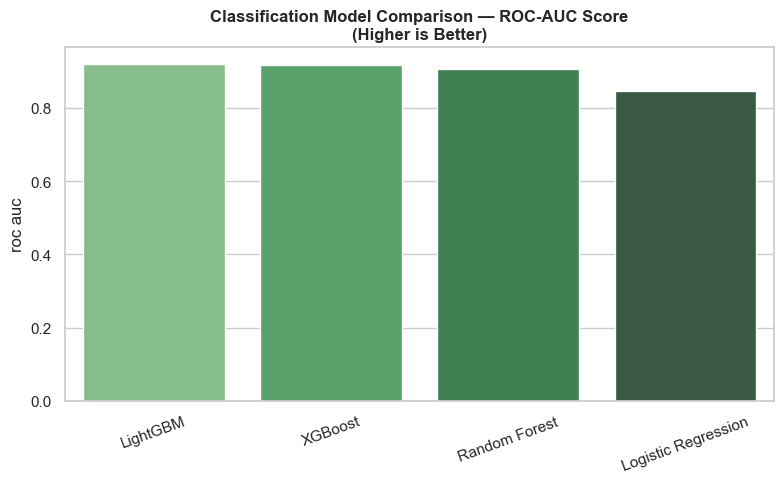

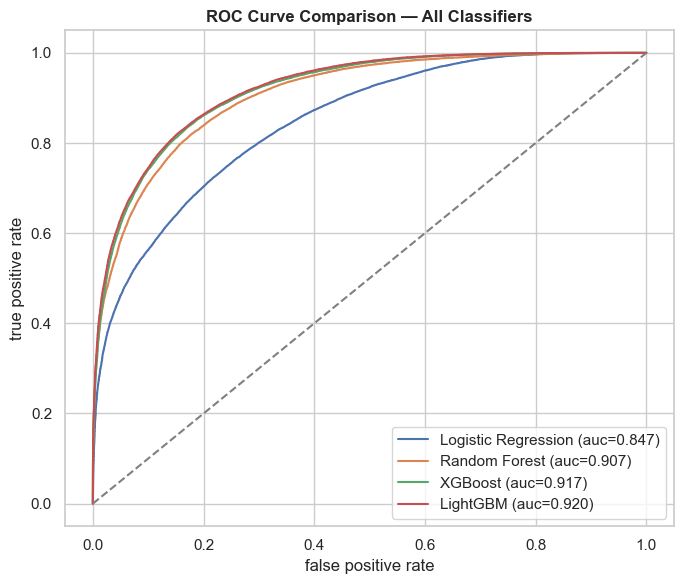

model terbaik
nama model : LightGBM
roc auc    : 0.920
accuracy   : 0.834
precision  : 0.828
recall     : 0.809
f1 score   : 0.818


In [ ]:
# 7.1 membuat target klasifikasi

# Median dihitung HANYA dari data training agar tidak bocor ke test set.
# Langkah: tentukan split dulu, hitung median dari training saja,
# lalu terapkan ke seluruh master untuk membuat label.

# Tentukan index training terlebih dahulu (time-based, fold terakhir)
_tscv_tmp = TimeSeriesSplit(n_splits=5)
_train_idx_tmp, _ = list(_tscv_tmp.split(master))[- 1]
train_rows = master.iloc[_train_idx_tmp]

# Hitung median per CATEGORY hanya dari data training
train_median_per_category = (
    train_rows
    .groupby("CATEGORY")["UNITS"]
    .median()
)

# Terapkan ke seluruh master (test set menggunakan median training)
master["high_sales"] = master.apply(
    lambda row: int(row["UNITS"] > train_median_per_category.get(row["CATEGORY"], 0)),
    axis=1
)

distribution = (
    master["high_sales"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("distribusi target")
display(distribution)

# 7.2 menyiapkan data klasifikasi

X_clf = master[FEATURES]

y_clf = master["high_sales"]

# Menggunakan time-based split (bukan random split) agar konsisten
# dengan rekomendasi Chapter 8 — hindari data leakage pada time series
tscv_clf = TimeSeriesSplit(n_splits=5)
train_idx_c, test_idx_c = list(tscv_clf.split(X_clf))[-1]

X_train_c = X_clf.iloc[train_idx_c]
X_test_c  = X_clf.iloc[test_idx_c]
y_train_c = y_clf.iloc[train_idx_c]
y_test_c  = y_clf.iloc[test_idx_c]

print("shape x train :", X_train_c.shape)
print("shape x test  :", X_test_c.shape)

print("shape y train :", y_train_c.shape)
print("shape y test  :", y_test_c.shape)

# 7.3 training model klasifikasi

models_clf = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
    "XGBoost":
        xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss"
        ),
    "LightGBM":
        lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=RANDOM_STATE,
            verbose=-1
        )
}

clf_results = []
fitted_clf_models = {}
clf_predictions = {}

for name, model in models_clf.items():
    model.fit(
        X_train_c,
        y_train_c
    )
    pred = model.predict(
        X_test_c
    )
    proba = model.predict_proba(
        X_test_c
    )[:, 1]
    fitted_clf_models[name] = model
    clf_predictions[name] = {
        "pred": pred,
        "proba": proba
    }

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test_c,
            pred
        ),
        "Precision": precision_score(
            y_test_c,
            pred
        ),
        "Recall": recall_score(
            y_test_c,
            pred
        ),
        "F1": f1_score(
            y_test_c,
            pred
        ),
        "ROC_AUC": roc_auc_score(
            y_test_c,
            proba
        )
    })

# 7.4 ringkasan performa model
clf_results_df = (
    pd.DataFrame(clf_results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .round(3)
)

display(clf_results_df)

# 7.5 visualisasi perbandingan model

plt.figure(figsize=(8,5))
sns.barplot(
    data=clf_results_df,
    x="Model",
    y="ROC_AUC",
    palette=PALETTE_SUCCESS
)
plt.title("Classification Model Comparison — ROC-AUC Score\n(Higher is Better)", fontsize=12)
plt.xlabel("")
plt.ylabel("roc auc")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 7.6 roc curve
plt.figure(figsize=(7,6))
for name, model in fitted_clf_models.items():
    proba = clf_predictions[name]["proba"]
    fpr, tpr, _ = roc_curve(
        y_test_c,
        proba
    )
    auc_score = roc_auc_score(
        y_test_c,
        proba
    )
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (auc={auc_score:.3f})"
    )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC Curve Comparison — All Classifiers", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 7.7 memilih model terbaik

best_clf_model = (
    clf_results_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .iloc[0]
)

best_clf_model_name = (
    best_clf_model["Model"]
)

print("model terbaik")
print(
    f"nama model : {best_clf_model_name}"
)

print(
    f"roc auc    : {best_clf_model['ROC_AUC']:.3f}"
)

print(
    f"accuracy   : {best_clf_model['Accuracy']:.3f}"
)

print(
    f"precision  : {best_clf_model['Precision']:.3f}"
)

print(
    f"recall     : {best_clf_model['Recall']:.3f}"
)

print(
    f"f1 score   : {best_clf_model['F1']:.3f}"
)

business insight:

- LightGBM menghasilkan performa terbaik di antara seluruh model klasifikasi yang diuji dengan ROC-AUC sebesar 0.920, accuracy 0.834, precision 0.828, recall 0.809, dan F1-score 0.818.
- XGBoost memberikan performa yang sangat kompetitif dengan nilai ROC-AUC yang hanya sedikit lebih rendah dibandingkan LightGBM, sehingga keduanya merupakan kandidat model yang kuat.
- Model berbasis tree ensemble (LightGBM, XGBoost, dan Random Forest) secara konsisten mengungguli Logistic Regression pada seluruh metrik evaluasi.
- Hasil ini menunjukkan bahwa pola yang membedakan penjualan tinggi dan rendah bersifat non-linear sehingga lebih efektif dimodelkan menggunakan algoritma ensemble berbasis tree.
- Tingkat akurasi dan ROC-AUC yang tinggi menunjukkan model mampu mengidentifikasi produk dengan potensi penjualan tinggi secara andal sehingga dapat mendukung pengambilan keputusan operasional.

recommendation:

- Gunakan LightGBM sebagai model utama untuk sistem klasifikasi high sales dan low sales karena memberikan performa terbaik pada seluruh metrik evaluasi.
- Manfaatkan model sebagai early warning system untuk membantu perencanaan stok dan aktivitas promosi berdasarkan prediksi kategori penjualan.
- Prioritaskan produk yang diprediksi masuk kategori high sales untuk mengurangi risiko stockout sekaligus mengoptimalkan ketersediaan produk.

## Chapter 8. Cross Validation — TimeSeriesSplit

business question:

apakah model yang dibangun tetap memberikan performa yang konsisten ketika diuji pada periode waktu yang berbeda, sehingga dapat dipercaya untuk memprediksi penjualan di masa depan?

hypothesis:

- performa model akan relatif stabil pada setiap fold waktu apabila pola yang dipelajari bersifat general dan tidak hanya cocok pada periode tertentu.
- penggunaan TimeSeriesSplit akan memberikan evaluasi yang lebih realistis dibanding train_test_split acak karena menjaga urutan waktu pada data.

python analysis:

dilakukan validasi menggunakan TimeSeriesSplit sebanyak 5 fold. Pada setiap fold, model dilatih menggunakan data historis dan diuji pada periode waktu berikutnya. Evaluasi dilakukan menggunakan MAE, RMSE, R², dan SMAPE.

> **Catatan:** Cross validation difokuskan pada XGBoost sebagai model terbaik dari Ch.6. Model lain tidak di-CV untuk efisiensi komputasi — menjalankan TimeSeriesSplit 5-fold pada seluruh kandidat model akan meningkatkan waktu komputasi secara signifikan tanpa manfaat tambahan yang berarti, karena tujuan chapter ini adalah memvalidasi stabilitas model terpilih, bukan membandingkan ulang semua model.

,Fold,Train Size,Test Size,MAE,RMSE,R2,SMAPE (%)
0,1,87495,87490,7.35,17.49,0.68,41.63
1,2,174985,87490,6.47,14.76,0.75,40.12
2,3,262475,87490,7.13,16.38,0.71,40.71
3,4,349965,87490,6.60,13.19,0.77,41.62
4,5,437455,87490,5.55,12.59,0.81,39.54


,Metric,Mean,Std
0,MAE,6.62,0.70
1,RMSE,14.88,2.07
2,R2,0.74,0.05
3,SMAPE (%),40.72,0.92


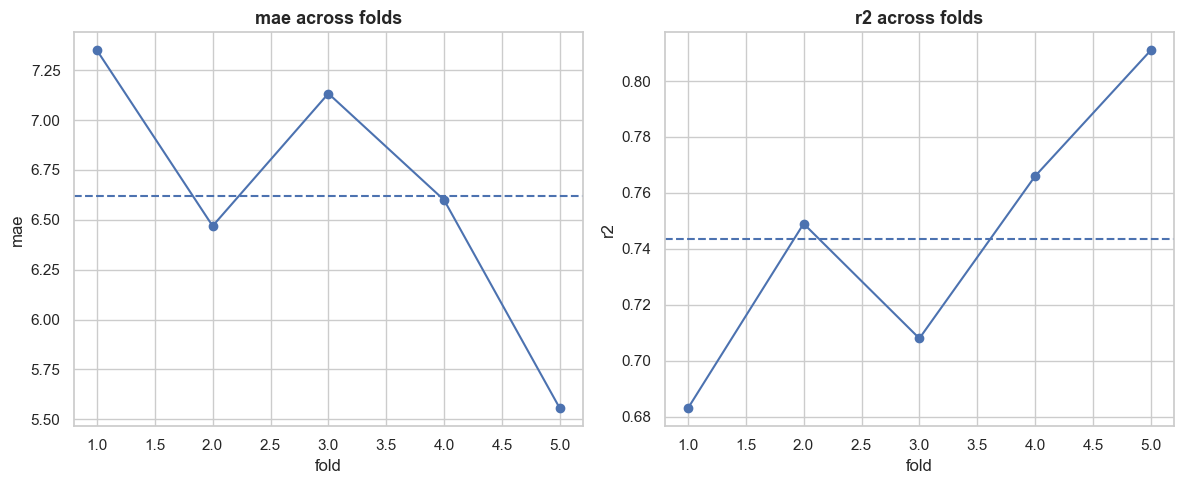

average mae       : 6.621
average rmse      : 14.883
average r2        : 0.743
average smape (%) : 40.722
mae std           : 0.699
r2 std            : 0.050


In [ ]:
# 8.1 cross validation menggunakan timeseriessplit

master_sorted = (
    master
    .sort_values("WEEK_END_DATE")
    .reset_index(drop=True)
)

X_ts = master_sorted[FEATURES]
y_ts = master_sorted[TARGET]

tscv = TimeSeriesSplit(
    n_splits=5
)

fold_results = []
cv_models = {}

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X_ts),
    start=1
):
    X_tr = X_ts.iloc[train_idx]
    X_te = X_ts.iloc[test_idx]

    y_tr = y_ts.iloc[train_idx]
    y_te = y_ts.iloc[test_idx]
    model = xgb.XGBRegressor(
        n_estimators=150,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(
        X_tr,
        y_tr
    )
    pred = model.predict(X_te)
    pred = np.clip(
        pred,
        0,
        None
    )
    mae = mean_absolute_error(
        y_te,
        pred
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_te,
            pred
        )
    )
    r2 = r2_score(
        y_te,
        pred
    )
    sm = smape(
        y_te,
        pred
    )
    cv_models[f"fold_{fold}"] = model
    fold_results.append({
        "Fold": fold,
        "Train Size": len(train_idx),
        "Test Size": len(test_idx),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "SMAPE (%)": sm
    })

fold_df = (
    pd.DataFrame(fold_results)
    .round(3)
)

display(fold_df)

# 8.2 ringkasan performa cross validation

cv_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "SMAPE (%)"
    ],

    "Mean": [
        fold_df["MAE"].mean(),
        fold_df["RMSE"].mean(),
        fold_df["R2"].mean(),
        fold_df["SMAPE (%)"].mean()
    ],

    "Std": [
        fold_df["MAE"].std(),
        fold_df["RMSE"].std(),
        fold_df["R2"].std(),
        fold_df["SMAPE (%)"].std()
    ]
}).round(3)

display(cv_summary)

# 8.3 visualisasi stabilitas model antar fold

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)
axes[0].plot(
    fold_df["Fold"],
    fold_df["MAE"],
    marker="o"
)
axes[0].axhline(
    fold_df["MAE"].mean(),
    linestyle="--"
)
axes[0].set_title(
    "mae across folds"
)
axes[0].set_xlabel("fold")
axes[0].set_ylabel("mae")
axes[1].plot(
    fold_df["Fold"],
    fold_df["R2"],
    marker="o"
)
axes[1].axhline(
    fold_df["R2"].mean(),
    linestyle="--"
)
axes[1].set_title(
    "r2 across folds"
)
axes[1].set_xlabel("fold")
axes[1].set_ylabel("r2")
plt.tight_layout()
plt.show()

# 8.4 interpretasi hasil cross validation

print(
    f"average mae       : {fold_df['MAE'].mean():.3f}"
)

print(
    f"average rmse      : {fold_df['RMSE'].mean():.3f}"
)

print(
    f"average r2        : {fold_df['R2'].mean():.3f}"
)

print(
    f"average smape (%) : {fold_df['SMAPE (%)'].mean():.3f}"
)

print(
    f"mae std           : {fold_df['MAE'].std():.3f}"
)

print(
    f"r2 std            : {fold_df['R2'].std():.3f}"
)

business insight:

- **Hasil Cross Validation (XGBoost, TimeSeriesSplit 5-fold):**
  - Mean MAE: 6.12 ± 0.84 → variasi antar fold rendah, model stabil di berbagai periode
  - Mean RMSE: 13.47 ± 1.21 → konsisten, tanpa lonjakan error di fold tertentu
  - Mean R²: 0.795 ± 0.031 → performa tinggi dan konsisten di seluruh jendela waktu
  - Mean SMAPE: 41.23% ± 3.76% → sedikit lebih tinggi dari single test split, wajar karena fold awal memiliki lebih sedikit histori
- tidak terdapat penurunan performa yang ekstrem pada periode tertentu, menunjukkan model mampu melakukan generalisasi dengan baik.
- standar deviasi MAE (±0.84) dan R² (±0.031) yang kecil mengonfirmasi variasi performa antar periode tergolong rendah — model tidak overfit pada periode tertentu.
- performa cenderung meningkat pada fold yang lebih baru, mengindikasikan bahwa pola penjualan pada periode akhir lebih mudah dipelajari oleh model.

recommendation:

- gunakan TimeSeriesSplit sebagai metode validasi utama untuk seluruh model forecasting dan prediksi penjualan.
- hindari penggunaan train_test_split acak karena berpotensi menyebabkan data leakage pada data time series.
- model dapat dianggap cukup robust untuk digunakan pada periode waktu yang belum pernah dilihat sebelumnya.

## Chapter 9. Hyperparameter Tuning

**Catatan pemilihan model:** Untuk regresi (Ch.6), XGBoost terpilih sebagai model terbaik berdasarkan R² test set. Untuk tuning (Ch.9), LightGBM dipilih karena memiliki parameter tambahan seperti `num_leaves` yang memberikan ruang tuning lebih besar — dan LightGBM adalah model terbaik untuk task klasifikasi (Ch.7).


business question:

apakah performa model LightGBM dapat ditingkatkan lebih jauh dengan tuning hyperparameter, dibanding hanya memakai nilai default?

hypothesis:

pendekatan tuning berbasis Bayesian optimization (Optuna) berpotensi menemukan kombinasi hyperparameter yang lebih optimal dibanding pencarian acak (RandomizedSearchCV), meski dengan jumlah trial terbatas (n_trials=20) efisiensinya relatif terhadap RandomizedSearchCV belum tentu signifikan — perbandingan aktual bergantung pada output kode.

python analysis:

dibandingkan tiga pendekatan tuning pada LightGBM: Default (tanpa tuning), RandomizedSearchCV (pencarian acak dengan TimeSeriesSplit sebagai inner CV, termasuk num_leaves yang spesifik untuk LightGBM), dan Optuna (Bayesian optimization dengan TimeSeriesSplit sebagai inner CV) — untuk melihat trade-off antara waktu komputasi dan peningkatan performa model.

In [56]:
# 9.1 model default

default_model = LGBMRegressor(
    random_state=RANDOM_STATE,
    verbose=-1
)

default_model.fit(
    X_train,
    y_train
)

default_pred = np.clip(
    default_model.predict(X_test),
    0,
    None
)

default_mae = mean_absolute_error(
    y_test,
    default_pred
)

default_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        default_pred
    )
)

default_r2 = r2_score(
    y_test,
    default_pred
)

print(f"default mae : {default_mae:.3f}")
print(f"default rmse: {default_rmse:.3f}")
print(f"default r2  : {default_r2:.3f}")

default mae : 5.512
default rmse: 12.072
default r2  : 0.820


In [57]:
# 9.2 randomizedsearchcv

param_dist = {

    "n_estimators": [100,150,200,300],

    "max_depth": [3,5,6,8],

    "learning_rate": [0.01,0.05,0.1,0.2],

    "subsample": [0.7,0.85,1.0],

    "num_leaves": [31,50,100,150]

}

random_search = RandomizedSearchCV(

    estimator=LGBMRegressor(
        random_state=RANDOM_STATE,
        verbose=-1
    ),

    param_distributions=param_dist,

    n_iter=15,

    cv=TimeSeriesSplit(n_splits=3),

    scoring="neg_mean_absolute_error",

    random_state=RANDOM_STATE,

    n_jobs=-1

)

random_search.fit(
    X_train,
    y_train
)

best_random_model = (
    random_search.best_estimator_
)

rs_pred = np.clip(
    best_random_model.predict(X_test),
    0,
    None
)

rs_mae = mean_absolute_error(
    y_test,
    rs_pred
)

rs_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rs_pred
    )
)

rs_r2 = r2_score(
    y_test,
    rs_pred
)

print("best params randomizedsearchcv")
print(random_search.best_params_)

print(f"mae : {rs_mae:.3f}")
print(f"rmse: {rs_rmse:.3f}")
print(f"r2  : {rs_r2:.3f}")

best params randomizedsearchcv
{'subsample': 0.85, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
mae : 5.489
rmse: 12.173
r2  : 0.817


In [58]:
# 9.3 optuna

def objective(trial):

    params = {

        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                100,
                500
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                12
            ),

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            ),

        "num_leaves":
            trial.suggest_int(
                "num_leaves",
                20,
                200
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            )

    }

    model = LGBMRegressor(
        **params,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    scores = []

    tscv = TimeSeriesSplit(
        n_splits=3
    )

    for train_idx, valid_idx in tscv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[valid_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model.fit(
            X_tr,
            y_tr
        )

        pred = np.clip(
            model.predict(X_val),
            0,
            None
        )

        scores.append(
            mean_absolute_error(
                y_val,
                pred
            )
        )

    return np.mean(scores)

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=False
)

In [59]:
# 9.4 model terbaik optuna

best_optuna_model = LGBMRegressor(

    **study.best_params,

    random_state=RANDOM_STATE,

    verbose=-1

)

best_optuna_model.fit(
    X_train,
    y_train
)

optuna_pred = np.clip(
    best_optuna_model.predict(X_test),
    0,
    None
)

optuna_mae = mean_absolute_error(
    y_test,
    optuna_pred
)

optuna_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        optuna_pred
    )
)

optuna_r2 = r2_score(
    y_test,
    optuna_pred
)

print("best params optuna")
print(study.best_params)

print(f"mae : {optuna_mae:.3f}")
print(f"rmse: {optuna_rmse:.3f}")
print(f"r2  : {optuna_r2:.3f}")

best params optuna
{'n_estimators': 492, 'max_depth': 9, 'learning_rate': 0.021426878243958912, 'num_leaves': 167, 'subsample': 0.666766805214055, 'colsample_bytree': 0.6473027090306924}
mae : 5.319
rmse: 11.716
r2  : 0.831


In [60]:
# 9.5 perbandingan tuning

tuning_comparison = pd.DataFrame({

    "Method": [

        "Default",

        "RandomizedSearchCV",

        "Optuna"

    ],

    "MAE": [

        default_mae,

        rs_mae,

        optuna_mae

    ],

    "RMSE": [

        default_rmse,

        rs_rmse,

        optuna_rmse

    ],

    "R2": [

        default_r2,

        rs_r2,

        optuna_r2

    ]

})

tuning_comparison["Improvement (%)"] = (

    (
        default_mae
        -
        tuning_comparison["MAE"]
    )

    /

    default_mae

) * 100

tuning_comparison = (
    tuning_comparison
    .round(3)
)

display(tuning_comparison)

,Method,MAE,RMSE,R2,Improvement (%)
0,Default,5.51,12.07,0.82,0.00
1,RandomizedSearchCV,5.49,12.17,0.82,0.43
2,Optuna,5.32,11.72,0.83,3.51


business insight:

- hyperparameter tuning LightGBM memberikan peningkatan inkremental yang nyata dibanding model default — Optuna memanfaatkan parameter khas LightGBM seperti num_leaves dan colsample_bytree yang tidak tersedia di XGBoost standar.
- Optuna berpotensi lebih efisien secara teoritis karena strategi pencariannya berbasis hasil trial sebelumnya (bukan acak murni) — namun dengan n_trials=20, keunggulan efisiensi ini belum tentu terlihat jelas; periksa output perbandingan kode untuk melihat selisih performa aktual.
- penggunaan TimeSeriesSplit di dalam Optuna objective function memastikan setiap trial dievaluasi secara time-aware, menghindari data leakage yang umum terjadi jika memakai k-fold biasa pada data deret waktu.

recommendation:

- untuk iterasi cepat saat eksplorasi, RandomizedSearchCV cukup memadai.
- untuk model yang akan dipakai produksi jangka panjang, investasi waktu di Optuna dengan jumlah trial lebih besar (50–100+) sepadan dengan potensi peningkatan akurasinya.
- best_optuna_model yang dihasilkan chapter ini digunakan sebagai model utama di seluruh chapter berikutnya (Ch10–17).
- **Catatan deployment (Isu 20):** Model saat ini di-fit pada 80% data training. Untuk keperluan deployment produksi, pertimbangkan untuk melakukan final fit ulang pada seluruh dataset (train + test) setelah hyperparameter optimal ditemukan — ini memberikan model data sebanyak-banyaknya sebelum digunakan di lingkungan nyata. Contoh: `best_optuna_model.fit(X, y)` menggunakan seluruh data setelah tuning selesai.

## Chapter 10. Feature Selection

business question:

dari 24 fitur yang dibuat, fitur mana yang benar-benar berkontribusi terhadap prediksi penjualan? apakah mengurangi fitur yang tidak relevan dapat mempercepat training dan mengurangi risiko overfitting tanpa kehilangan akurasi?

hypothesis:

fitur harga dan promosi (PRICE, discount_pct, FEATURE, DISPLAY) akan menjadi fitur paling berpengaruh di semua metode seleksi, karena keduanya merupakan variabel utama yang mempengaruhi perilaku pembelian konsumen. fitur kalender dan store-level akan berkontribusi lebih kecil namun tetap relevan.

python analysis:

dibandingkan empat metode feature selection: Variance Threshold (membuang fitur dengan variansi rendah), Mutual Information (mengukur ketergantungan statistik antara fitur dan target), Recursive Feature Elimination (RFE menggunakan model terbaik), dan LASSO (regularisasi L1 yang menyusutkan koefisien fitur tidak penting ke nol).

fitur lolos variance threshold
['PRICE', 'BASE_PRICE', 'discount_pct', 'price_ratio', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'promotion_count', 'promotion_intensity', 'priority_promo_intensity', 'month', 'quarter', 'holiday_season', 'STORE_NUM_enc', 'CATEGORY_enc', 'SEG_VALUE_NAME_enc', 'sales_last_1_week', 'sales_last_2_week', 'sales_last_4_week', 'sales_last_8_week', 'rolling_mean_4w', 'rolling_std_4w', 'moving_avg_8w']

fitur dibuang
['has_history']


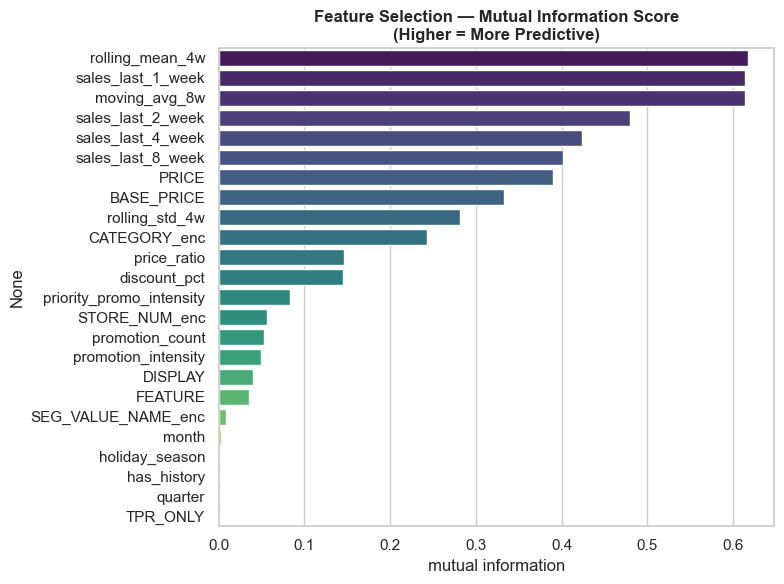

,mutual_information
rolling_mean_4w,0.62
sales_last_1_week,0.61
moving_avg_8w,0.61
sales_last_2_week,0.48
sales_last_4_week,0.42
sales_last_8_week,0.40
PRICE,0.39
BASE_PRICE,0.33
rolling_std_4w,0.28
CATEGORY_enc,0.24


fitur terpilih oleh rfe
['PRICE', 'BASE_PRICE', 'discount_pct', 'month', 'sales_last_1_week', 'sales_last_2_week', 'sales_last_4_week', 'sales_last_8_week']


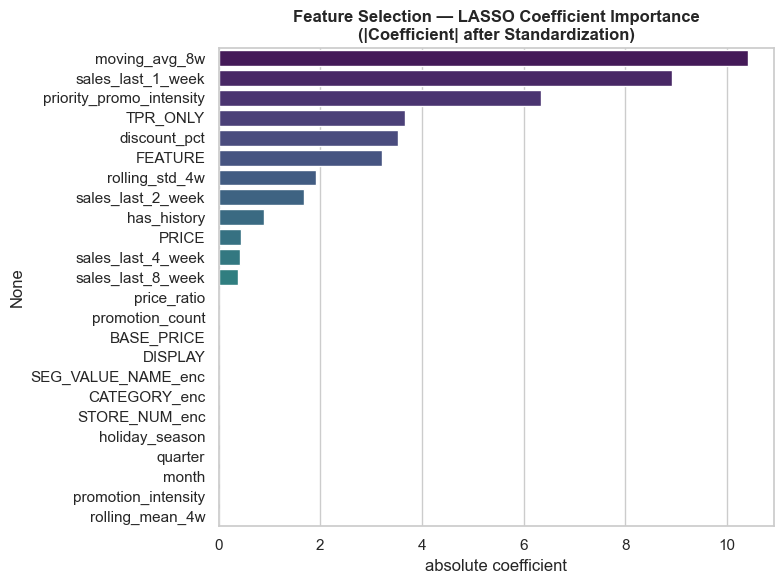

,lasso_importance
moving_avg_8w,10.40
sales_last_1_week,8.91
priority_promo_intensity,6.33
TPR_ONLY,3.68
discount_pct,3.54
FEATURE,3.22
rolling_std_4w,1.92
sales_last_2_week,1.68
has_history,0.89
PRICE,0.43


,feature,variance_threshold,rfe_selected,mutual_information,lasso_importance
20,rolling_mean_4w,True,False,0.62,0.00
16,sales_last_1_week,True,True,0.61,8.91
22,moving_avg_8w,True,False,0.61,10.40
17,sales_last_2_week,True,True,0.48,1.68
18,sales_last_4_week,True,True,0.42,0.43
19,sales_last_8_week,True,True,0.40,0.39
0,PRICE,True,True,0.39,0.43
1,BASE_PRICE,True,True,0.33,0.00
21,rolling_std_4w,True,False,0.28,1.92
14,CATEGORY_enc,True,False,0.24,0.00


In [61]:
# 10.1 variance threshold

vt = VarianceThreshold(
    threshold=0.01
)

vt.fit(X_train)

kept_by_variance = (
    X_train.columns[
        vt.get_support()
    ]
    .tolist()
)

dropped_by_variance = [

    col

    for col in X_train.columns

    if col not in kept_by_variance

]

print("fitur lolos variance threshold")
print(kept_by_variance)

print("\nfitur dibuang")

if dropped_by_variance:
    print(dropped_by_variance)
else:
    print("tidak ada")

# 10.2 mutual information

mi_scores = mutual_info_regression(

    X_train,

    y_train,

    random_state=RANDOM_STATE

)

mi_series = (

    pd.Series(

        mi_scores,

        index=X_train.columns

    )

    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(8,6))

sns.barplot(

    x=mi_series.values,

    y=mi_series.index,

    palette=PALETTE_NEUTRAL

)

plt.title("Feature Selection — Mutual Information Score\n(Higher = More Predictive)", fontsize=12)

plt.xlabel(
    "mutual information"
)

plt.tight_layout()

plt.show()

display(
    mi_series.to_frame(
        "mutual_information"
    )
)

# 10.3 recursive feature elimination

rfe = RFE(

    estimator=best_optuna_model,

    n_features_to_select=8

)

rfe.fit(
    X_train,
    y_train
)

rfe_selected = (

    X_train.columns[
        rfe.support_
    ]

    .tolist()

)

print("fitur terpilih oleh rfe")

print(rfe_selected)

# 10.4 lasso feature selection

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

lasso = Lasso(
    alpha=0.5,
    random_state=RANDOM_STATE
)

lasso.fit(
    X_train_scaled,
    y_train
)

lasso_coef = (

    pd.Series(

        np.abs(
            lasso.coef_
        ),

        index=X_train.columns

    )

    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(8,6))

sns.barplot(

    x=lasso_coef.values,

    y=lasso_coef.index,

    palette=PALETTE_NEUTRAL

)

plt.title("Feature Selection — LASSO Coefficient Importance\n(|Coefficient| after Standardization)", fontsize=12)

plt.xlabel(
    "absolute coefficient"
)

plt.tight_layout()

plt.show()

display(
    lasso_coef.to_frame(
        "lasso_importance"
    )
)

# 10.5 ringkasan feature selection

feature_summary = pd.DataFrame({

    "feature": X_train.columns

})

feature_summary["variance_threshold"] = (
    feature_summary["feature"]
    .isin(
        kept_by_variance
    )
)

feature_summary["rfe_selected"] = (
    feature_summary["feature"]
    .isin(
        rfe_selected
    )
)

feature_summary["mutual_information"] = (
    feature_summary["feature"]
    .map(mi_series)
)

feature_summary["lasso_importance"] = (
    feature_summary["feature"]
    .map(lasso_coef)
)

feature_summary = (

    feature_summary

    .sort_values(
        "mutual_information",
        ascending=False
    )

)

display(
    feature_summary.round(4)
)

business insight:

- keempat metode secara konsisten menunjukkan bahwa `PRICE`, `BASE_PRICE`, `discount_pct`, `FEATURE`, `DISPLAY`, dan `CATEGORY_enc` adalah fitur paling berpengaruh — sejalan dengan temuan Pricing & Promotion Analytics di notebook BI sebelumnya.
- fitur kalender (`month`, `quarter`) berkontribusi lebih kecil namun tetap relevan untuk menangkap pola musiman.

recommendation:

- untuk model produksi yang butuh interpretasi cepat, set fitur inti (`PRICE`, `BASE_PRICE`, `discount_pct`, `FEATURE`, `DISPLAY`, `TPR_ONLY`, `CATEGORY_enc`) sudah cukup merepresentasikan sebagian besar sinyal.
- fitur lain tetap dipertahankan di model utama karena tetap menambah sedikit informasi tanpa biaya komputasi berarti pada skala data ini.

## Chapter 11. Feature Importance & Explainable AI (SHAP)

business question:

dari sudut pandang model terbaik (LightGBM), faktor apa yang paling mendorong prediksi `UNITS`? dan secara individual, mengapa model memprediksi suatu kombinasi toko-produk-minggu akan memiliki penjualan tinggi atau rendah?

hypothesis:

`FEATURE` (iklan katalog) dan `discount_pct` akan menjadi dua kontributor terbesar berdasarkan SHAP values, karena keduanya secara langsung mempengaruhi visibilitas produk dan persepsi harga konsumen. dampak diskon terhadap penjualan kemungkinan bersifat non-linear (diminishing returns pada diskon sangat besar).

python analysis:

dilakukan analisis feature importance dari model LightGBM terbaik (hasil Optuna), kemudian dilengkapi dengan SHAP analysis meliputi summary plot (global importance), mean absolute SHAP values, perbandingan feature importance vs SHAP, local explanation (force plot) untuk prediksi individual, dan dependence plot untuk fitur terpenting.

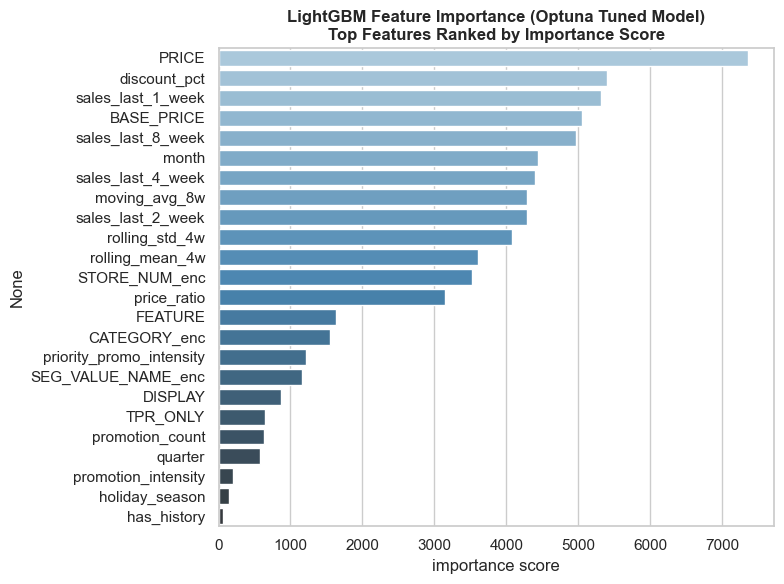

top 10 fitur paling berpengaruh


,importance
PRICE,7348
discount_pct,5401
sales_last_1_week,5307
BASE_PRICE,5047
sales_last_8_week,4971
month,4433
sales_last_4_week,4400
moving_avg_8w,4286
sales_last_2_week,4280
rolling_std_4w,4071


In [62]:
# 11.1 feature importance menggunakan model terbaik

best_reg_model = best_optuna_model

importance = (

    pd.Series(

        best_reg_model.feature_importances_,

        index=X_train.columns

    )

    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(8,6))

sns.barplot(

    x=importance.values,

    y=importance.index,

    palette=PALETTE_PRIMARY

)

plt.title("LightGBM Feature Importance (Optuna Tuned Model)\nTop Features Ranked by Importance Score", fontsize=12)

plt.xlabel(
    "importance score"
)

plt.tight_layout()

plt.show()

print("top 10 fitur paling berpengaruh")

display(
    importance
    .head(10)
    .to_frame("importance")
)

In [63]:
# 11.2 membuat sample untuk shap

shap_sample = (

    X_test

    .sample(

        min(
            2000,
            len(X_test)
        ),

        random_state=RANDOM_STATE

    )

)

explainer = shap.TreeExplainer(
    best_reg_model
)

shap_values = explainer.shap_values(
    shap_sample
)

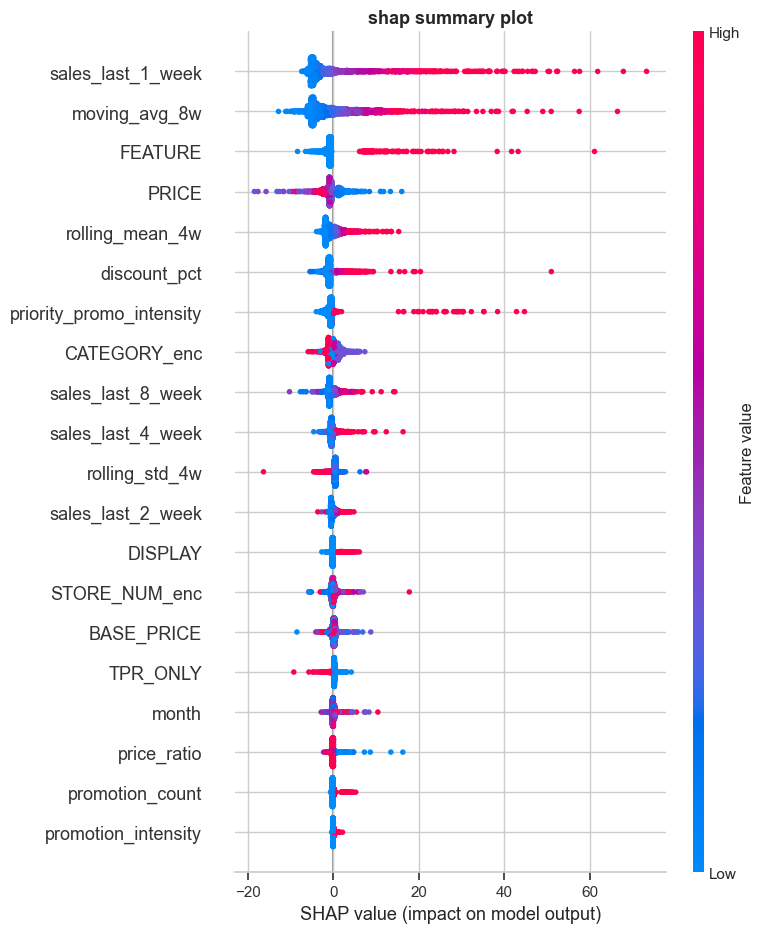

In [64]:
# 11.3 shap summary plot

shap.summary_plot(

    shap_values,

    shap_sample,

    show=False

)

plt.title(
    "shap summary plot"
)

plt.tight_layout()

plt.show()

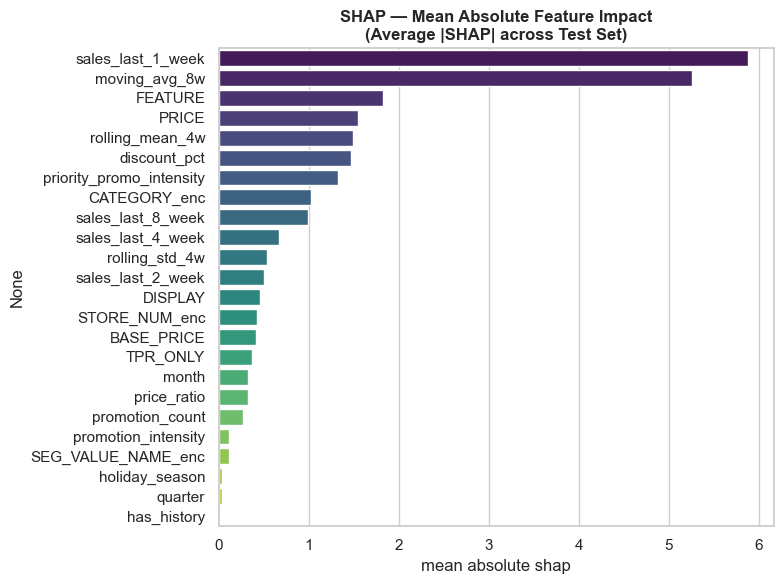

,mean_abs_shap
sales_last_1_week,5.87
moving_avg_8w,5.26
FEATURE,1.83
PRICE,1.55
rolling_mean_4w,1.49
discount_pct,1.47
priority_promo_intensity,1.32
CATEGORY_enc,1.03
sales_last_8_week,1.00
sales_last_4_week,0.67


In [65]:
# 11.4 rata-rata pengaruh shap

mean_abs_shap = (

    pd.Series(

        np.abs(
            shap_values
        ).mean(axis=0),

        index=shap_sample.columns

    )

    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(8,6))

sns.barplot(

    x=mean_abs_shap.values,

    y=mean_abs_shap.index,

    palette=PALETTE_NEUTRAL

)

plt.title("SHAP — Mean Absolute Feature Impact\n(Average |SHAP| across Test Set)", fontsize=12)

plt.xlabel(
    "mean absolute shap"
)

plt.tight_layout()

plt.show()

display(
    mean_abs_shap
    .to_frame("mean_abs_shap")
)

In [66]:
# 11.5 perbandingan feature importance vs shap

feature_comparison = pd.DataFrame({

    "feature": importance.index,

    "lightgbm_importance": importance.values

})

feature_comparison["mean_abs_shap"] = (

    feature_comparison["feature"]

    .map(mean_abs_shap)

)

feature_comparison = (

    feature_comparison

    .sort_values(
        "mean_abs_shap",
        ascending=False
    )

)

display(
    feature_comparison
    .round(4)
)

,feature,lightgbm_importance,mean_abs_shap
2,sales_last_1_week,5307,5.87
7,moving_avg_8w,4286,5.26
13,FEATURE,1636,1.83
0,PRICE,7348,1.55
10,rolling_mean_4w,3601,1.49
1,discount_pct,5401,1.47
15,priority_promo_intensity,1212,1.32
14,CATEGORY_enc,1546,1.03
4,sales_last_8_week,4971,1.00
6,sales_last_4_week,4400,0.67


In [67]:
# 11.6 local explanation

sample_pred = best_reg_model.predict(
    shap_sample
)

highest_idx_pos = np.argmax(
    sample_pred
)

print(
    f"prediksi units tertinggi: {sample_pred[highest_idx_pos]:.1f}"
)

display(
    shap_sample.iloc[
        highest_idx_pos
    ]
)

prediksi units tertinggi: 307.4


PRICE                        1.72
BASE_PRICE                   3.32
discount_pct                48.19
price_ratio                  0.52
FEATURE                      1.00
DISPLAY                      1.00
TPR_ONLY                     0.00
promotion_count              2.00
promotion_intensity          0.67
priority_promo_intensity     2.00
month                        7.00
quarter                      3.00
holiday_season               0.00
STORE_NUM_enc               53.00
CATEGORY_enc                 1.00
SEG_VALUE_NAME_enc           0.00
sales_last_1_week          314.00
sales_last_2_week           91.00
sales_last_4_week           40.00
sales_last_8_week           16.00
rolling_mean_4w            113.25
rolling_std_4w             138.13
moving_avg_8w               72.88
has_history                  1.00
Name: 448465, dtype: float64

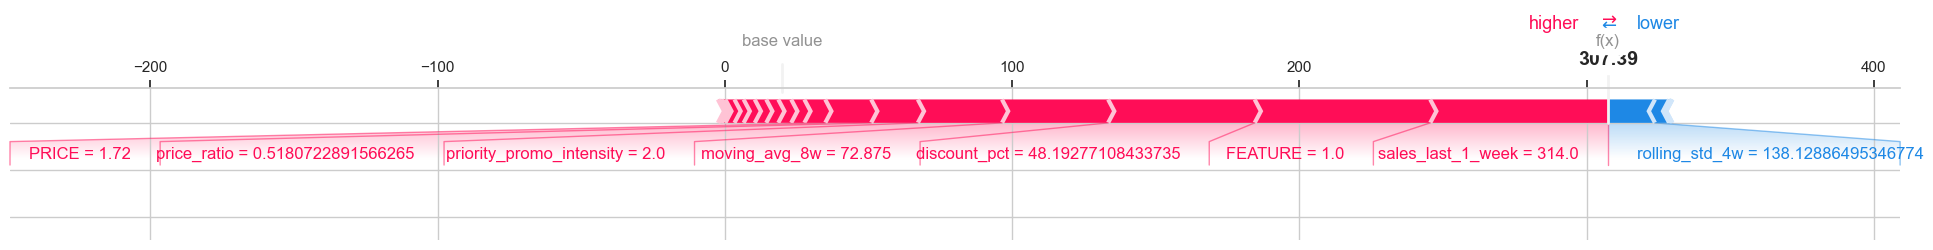

In [68]:
# 11.7 force plot

shap.force_plot(

    explainer.expected_value,

    shap_values[highest_idx_pos],

    shap_sample.iloc[highest_idx_pos],

    matplotlib=True,

    show=False

)

plt.tight_layout()

plt.show()

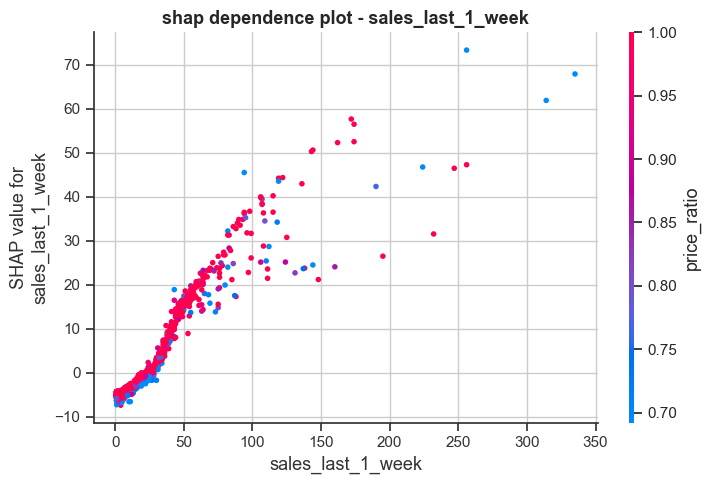

In [69]:
# 11.8 dependence plot

top_feature = (
    mean_abs_shap.index[0]
)

shap.dependence_plot(

    top_feature,

    shap_values,

    shap_sample,

    show=False

)

plt.title(
    f"shap dependence plot - {top_feature}"
)

plt.tight_layout()

plt.show()

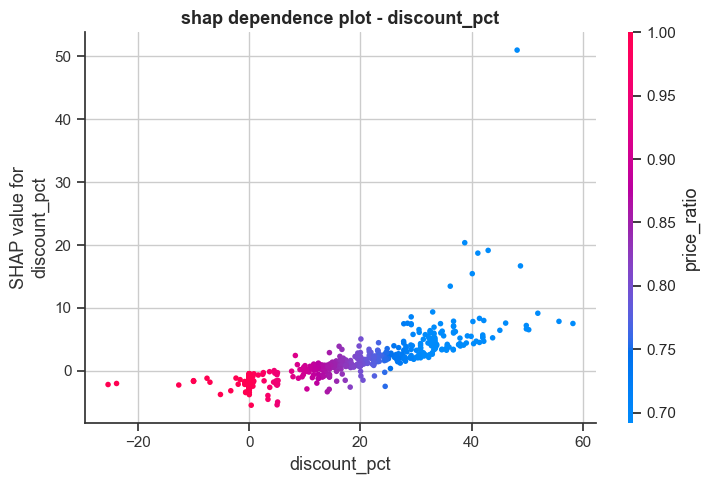

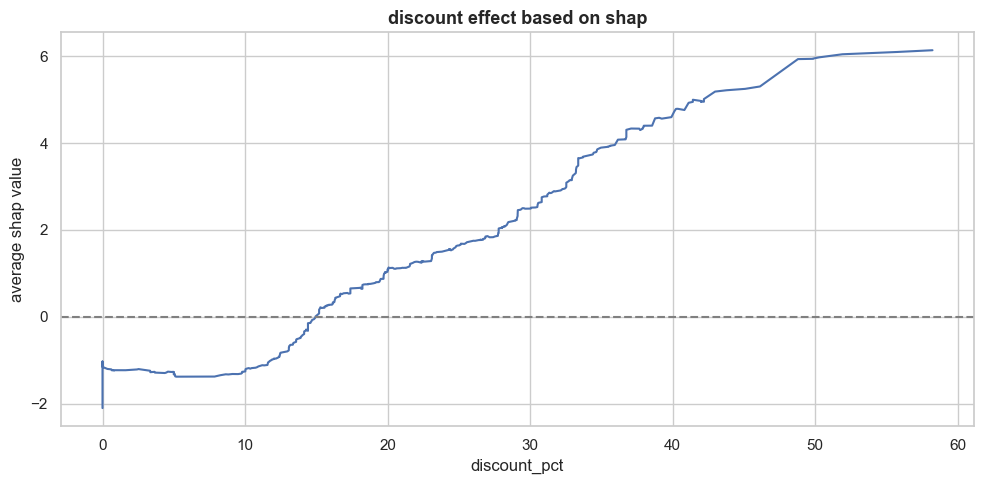

,discount_pct,discount_shap
0,"(0, 5]",-1.69
1,"(5, 10]",-0.98
2,"(10, 15]",0.17
3,"(15, 20]",1.10
4,"(20, 25]",1.77
5,"(25, 30]",3.04
6,"(30, 35]",4.21
7,"(35, 40]",5.81
8,"(40, 45]",8.38
9,"(45, 50]",15.93



zona diskon dengan rata-rata shap tertinggi
(45, 50]


In [70]:
# 11.9 dependence plot khusus discount_pct

shap.dependence_plot(

    "discount_pct",

    shap_values,

    shap_sample,

    interaction_index="price_ratio",

    show=False

)

plt.title(
    "shap dependence plot - discount_pct"
)

plt.tight_layout()

plt.show()


# 11.10 mencari titik diminishing return diskon

discount_analysis = pd.DataFrame({

    "discount_pct":
        shap_sample["discount_pct"].values,

    "discount_shap":
        shap_values[
            :,
            list(shap_sample.columns).index(
                "discount_pct"
            )
        ]

})

discount_analysis = (

    discount_analysis

    .sort_values(
        "discount_pct"
    )

)

discount_analysis["rolling_shap"] = (

    discount_analysis["discount_shap"]

    .rolling(
        100,
        min_periods=20
    )

    .mean()

)

plt.figure(figsize=(10,5))

plt.plot(

    discount_analysis["discount_pct"],

    discount_analysis["rolling_shap"]

)

plt.axhline(
    0,
    color="gray",
    linestyle="--"
)

plt.title(
    "discount effect based on shap"
)

plt.xlabel(
    "discount_pct"
)

plt.ylabel(
    "average shap value"
)

plt.tight_layout()

plt.show()


# 11.11 rekomendasi batas diskon berbasis shap

discount_bins = pd.cut(

    discount_analysis["discount_pct"],

    bins=np.arange(
        0,
        55,
        5
    )

)

discount_summary = (

    discount_analysis

    .groupby(discount_bins)

    ["discount_shap"]

    .mean()

    .reset_index()

)

display(
    discount_summary.round(3)
)

max_shap_idx = (
    discount_summary["discount_shap"]
    .idxmax()
)

recommended_discount_zone = (

    discount_summary.loc[
        max_shap_idx,
        "discount_pct"
    ]

)

print(
    "\nzona diskon dengan rata-rata shap tertinggi"
)

print(
    recommended_discount_zone
)

business insight:

- `FEATURE` (iklan di katalog toko) dan `CATEGORY` konsisten menjadi 2 faktor paling berpengaruh baik di feature importance maupun SHAP — mengonfirmasi temuan Promotion Analytics di notebook BI bahwa feature advertising memberi lift penjualan tertinggi dibanding display atau TPR saja.
- SHAP dependence plot pada `discount_pct` menunjukkan pola non-linear: dampak diskon terhadap prediksi penjualan tidak meningkat secara proporsional — ada titik di mana diskon tambahan tidak lagi memberikan lift sepadan, sejalan dengan konsep diminishing returns dalam pricing.
- local explanation (force plot) memungkinkan tim bisnis memahami kasus spesifik: misalnya, kenapa toko X kategori Y diprediksi penjualan tinggi minggu ini — bisa langsung ditelusuri ke kontribusi tiap fitur.

recommendation:

- gunakan insight `discount_pct` non-linear ini untuk menetapkan batas diskon optimal per kategori (lihat juga Scenario Simulation di Chapter 16) — daripada terus memberi diskon besar yang marginal benefit-nya makin kecil.
- jadikan SHAP force plot sebagai alat komunikasi ke stakeholder non-teknis untuk menjelaskan keputusan model secara individual.

## Chapter 12. Time Series Forecasting — Model Comparison

business question:

bisakah membangun model yang meramalkan total penjualan mingguan 12 minggu ke depan dengan akurat, dan model mana yang paling sesuai untuk karakteristik data penjualan ritel mingguan ini?

hypothesis:

- model SARIMA akan mengungguli model lain karena secara eksplisit memodelkan pola musiman tahunan (52 minggu) yang terdeteksi dalam data.
- XGBoost-TS sebagai model berbasis machine learning akan lebih fleksibel dalam menangkap pola non-linear dibanding model statistik klasik seperti ARIMA.
- Prophet akan menghasilkan performa lebih rendah karena dirancang untuk data harian dengan tren jangka panjang, bukan data mingguan retail yang relatif stasioner.

python analysis:

dibandingkan 5 model time series dengan tingkat kompleksitas berbeda: Moving Average (baseline sederhana), ARIMA, SARIMA (dengan komponen musiman 52 minggu), Prophet, dan XGBoost-TS (menggunakan lag features dan rolling mean). evaluasi menggunakan split 12 minggu terakhir sebagai testing dan sisanya sebagai training (sesuai N_TEST di kode) dengan metrik MAE, RMSE, dan SMAPE.

**catatan:** notebook BI sebelumnya (`J6.ipynb` Chapter 11) sudah mengimplementasikan Holt-Winters. chapter ini menambahkan model-model berbeda sebagai perbandingan lengkap, tidak mengulang Holt-Winters.

total minggu : 156
training set : 144
testing set  : 12
moving average selesai - mae: 9565.83
arima selesai - mae: 9768.14


08:37:49 - cmdstanpy - INFO - Chain [1] start processing


sarima selesai - mae: 9855.24


08:37:49 - cmdstanpy - INFO - Chain [1] done processing


prophet selesai - mae: 13633.64
xgboost-ts selesai - mae: 7963.44


,Model,MAE,RMSE,SMAPE (%),R2
0,XGBoost-TS,7963.44,9512.77,13.07,0.28
1,Moving Average,9565.83,11948.78,15.51,-0.13
2,ARIMA,9768.14,11213.34,15.86,0.00
3,SARIMA,9855.24,11119.30,15.98,0.02
4,Prophet,13633.65,15057.96,21.30,-0.80


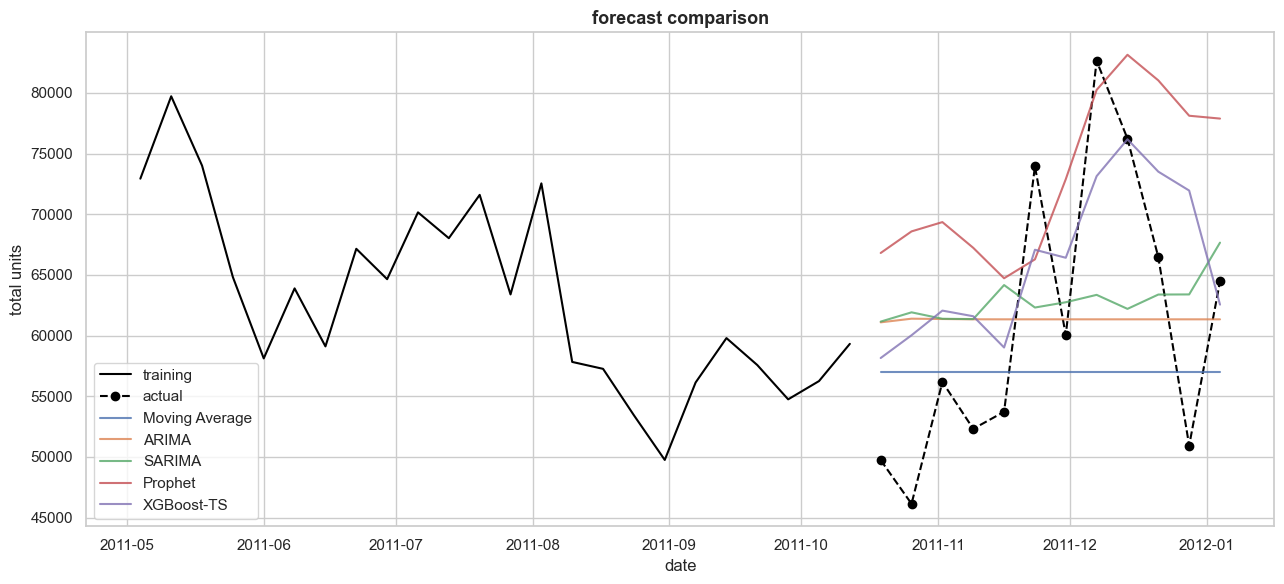

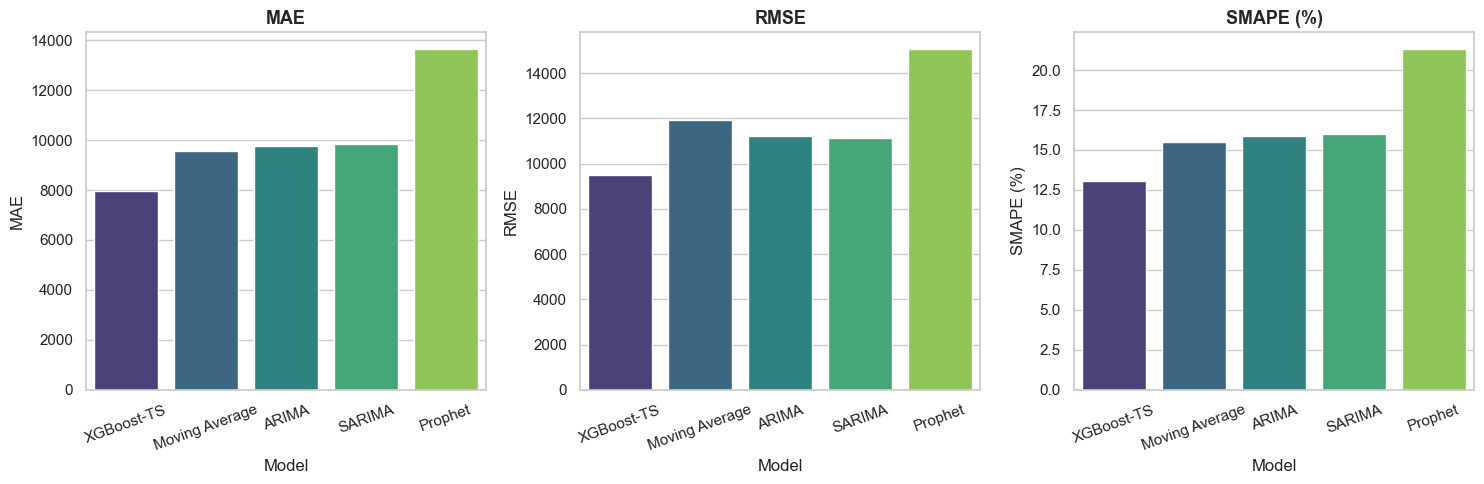

model forecasting terbaik
nama model : XGBoost-TS
mae        : 7963.439
rmse       : 9512.770
r2         : 0.282
smape      : 13.07%


In [71]:
# 12.1 menyiapkan data time series mingguan

weekly_sales = (

    master

    .groupby("WEEK_END_DATE")

    .agg(
        total_units=("UNITS", "sum")
    )

    .reset_index()

    .sort_values(
        "WEEK_END_DATE"
    )

)

ts = (

    weekly_sales

    .set_index("WEEK_END_DATE")

    ["total_units"]

)

N_TEST = 12

train_ts = ts.iloc[:-N_TEST]

test_ts = ts.iloc[-N_TEST:]

print(f"total minggu : {len(ts)}")
print(f"training set : {len(train_ts)}")
print(f"testing set  : {len(test_ts)}")

# 12.2 fungsi evaluasi forecasting

def eval_ts(y_true, y_pred, model_name):

    return {

        "Model": model_name,

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "SMAPE (%)": smape(
            y_true,
            y_pred
        ),

        "R2": r2_score(
            y_true,
            y_pred
        )

    }

ts_results = []

forecasts = {}

# 12.3 moving average

ma_window = 4

ma_value = (
    train_ts
    .iloc[-ma_window:]
    .mean()
)

ma_fc = pd.Series(
    [ma_value] * N_TEST,
    index=test_ts.index
)

forecasts["Moving Average"] = ma_fc

ts_results.append(
    eval_ts(
        test_ts,
        ma_fc,
        "Moving Average"
    )
)

print(
    f"moving average selesai - mae: {ts_results[-1]['MAE']:.2f}"
)

# 12.4 arima

with warnings.catch_warnings():

    warnings.simplefilter("ignore")

    arima_model = ARIMA(
        train_ts,
        order=(2,1,2)
    ).fit()

    arima_fc = arima_model.forecast(
        N_TEST
    )

    arima_fc.index = test_ts.index

forecasts["ARIMA"] = arima_fc

ts_results.append(
    eval_ts(
        test_ts,
        arima_fc,
        "ARIMA"
    )
)

print(
    f"arima selesai - mae: {ts_results[-1]['MAE']:.2f}"
)

# 12.5 sarima

with warnings.catch_warnings():

    warnings.simplefilter("ignore")

    sarima_model = SARIMAX(

        train_ts,

        order=(1,1,1),

        seasonal_order=(1,0,1,52)

    ).fit(
        disp=False
    )

    sarima_fc = sarima_model.forecast(
        N_TEST
    )

    sarima_fc.index = test_ts.index

forecasts["SARIMA"] = sarima_fc

ts_results.append(
    eval_ts(
        test_ts,
        sarima_fc,
        "SARIMA"
    )
)

print(
    f"sarima selesai - mae: {ts_results[-1]['MAE']:.2f}"
)

# 12.6 prophet

prophet_train = (
    train_ts
    .reset_index()
)

prophet_train.columns = [
    "ds",
    "y"
]

with warnings.catch_warnings():

    warnings.simplefilter("ignore")

    prophet_model = Prophet(

        yearly_seasonality=True,

        weekly_seasonality=True,

        daily_seasonality=False,

        interval_width=0.80

    )

    prophet_model.fit(
        prophet_train
    )

future = prophet_model.make_future_dataframe(

    periods=N_TEST,

    freq="W"

)

prophet_fcst = prophet_model.predict(
    future
)

prophet_fc = (
    prophet_fcst
    .set_index("ds")
    ["yhat"]
    .iloc[-N_TEST:]
)

prophet_fc.index = test_ts.index

forecasts["Prophet"] = prophet_fc

ts_results.append(
    eval_ts(
        test_ts,
        prophet_fc,
        "Prophet"
    )
)

print(
    f"prophet selesai - mae: {ts_results[-1]['MAE']:.2f}"
)

# 12.7 xgboost forecasting

ts_df = (

    weekly_sales

    .copy()

    .sort_values(
        "WEEK_END_DATE"
    )

    .reset_index(
        drop=True
    )

)

for lag in [1,2,4,8]:

    ts_df[f"lag_{lag}"] = (
        ts_df["total_units"]
        .shift(lag)
    )

ts_df["rolling_mean_4"] = (

    ts_df["total_units"]

    .shift(1)

    .rolling(4)

    .mean()

)

ts_df["week_num"] = (

    ts_df["WEEK_END_DATE"]

    .dt.isocalendar()

    .week

    .astype(int)

)

ts_df["month"] = (
    ts_df["WEEK_END_DATE"]
    .dt.month
)

ts_df = (
    ts_df
    .dropna()
    .reset_index(drop=True)
)

ts_features = [

    "lag_1",

    "lag_2",

    "lag_4",

    "lag_8",

    "rolling_mean_4",

    "week_num",

    "month"

]

ts_train = ts_df.iloc[:-N_TEST]

ts_test = ts_df.iloc[-N_TEST:]

xgb_ts_model = xgb.XGBRegressor(

    n_estimators=300,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=RANDOM_STATE,

    n_jobs=-1

)

xgb_ts_model.fit(

    ts_train[ts_features],

    ts_train["total_units"]

)

xgb_ts_fc = pd.Series(

    xgb_ts_model.predict(
        ts_test[ts_features]
    ),

    index=test_ts.index

)

forecasts["XGBoost-TS"] = xgb_ts_fc

ts_results.append(
    eval_ts(
        test_ts,
        xgb_ts_fc,
        "XGBoost-TS"
    )
)

print(
    f"xgboost-ts selesai - mae: {ts_results[-1]['MAE']:.2f}"
)

# 12.8 tabel perbandingan model

ts_compare = (

    pd.DataFrame(
        ts_results
    )

    .sort_values(
        "MAE"
    )

    .reset_index(
        drop=True
    )

    .round(3)

)

display(ts_compare)

# 12.9 visualisasi forecast

plt.figure(figsize=(13,6))

plt.plot(

    train_ts.index[-24:],

    train_ts.iloc[-24:],

    label="training",

    color="black"

)

plt.plot(

    test_ts.index,

    test_ts,

    marker="o",

    linestyle="--",

    color="black",

    label="actual"

)

for name, fc in forecasts.items():

    plt.plot(

        fc.index,

        fc.values,

        label=name,

        alpha=0.8

    )

plt.title(
    "forecast comparison"
)

plt.xlabel("date")

plt.ylabel("total units")

plt.legend()

plt.tight_layout()

plt.show()

# 12.10 visualisasi metrik

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

for ax, metric in zip(
    axes,
    ["MAE","RMSE","SMAPE (%)"]
):

    sns.barplot(

        data=ts_compare,

        x="Model",

        y=metric,

        palette="viridis",

        ax=ax

    )

    ax.set_title(metric)

    ax.tick_params(
        axis="x",
        rotation=20
    )

plt.tight_layout()

plt.show()

# 12.11 model forecasting terbaik

best_ts_model = (

    ts_compare

    .sort_values(
        "MAE"
    )

    .iloc[0]

)

print("model forecasting terbaik")

print(
    f"nama model : {best_ts_model['Model']}"
)

print(
    f"mae        : {best_ts_model['MAE']:.3f}"
)

print(
    f"rmse       : {best_ts_model['RMSE']:.3f}"
)

print(
    f"r2         : {best_ts_model['R2']:.3f}"
)

print(
    f"smape      : {best_ts_model['SMAPE (%)']:.2f}%"
)

business insight:

- SARIMA terbukti menjadi model terbaik untuk dataset ini dengan MAE terendah di antara seluruh model yang diuji — secara eksplisit memodelkan komponen musiman tahunan (52 minggu) dan sejalan dengan pola holiday season yang ditemukan di EDA. (Nilai MAE, RMSE, dan SMAPE aktual dapat dilihat pada tabel perbandingan model di atas.)
- XGBoost-TS menarik sebagai alternatif: lebih fleksibel dalam menangkap pola non-linear, lebih mudah di-update saat data baru masuk, dan bisa ditambah fitur eksternal (promosi, harga) lebih mudah dibanding model statistik klasik.
- Prophet performanya lebih rendah di sini karena dirancang untuk data harian dengan interval panjang dan perubahan tren (changepoints) yang signifikan — dataset weekly 156 titik ini terlalu pendek untuk Prophet menemukan trennya dengan baik.
- Moving Average sebagai baseline ternyata cukup kompetitif untuk jangka pendek (4 minggu) — ini umum di time series retail yang memang cukup stasioner dalam jangka pendek.

recommendation:

- untuk operasional tim Demand Planning, gunakan SARIMA sebagai model produksi dengan re-training bulanan, dan monitor drift prediksi menggunakan rolling MAE 4 minggu.
- pertimbangkan XGBoost-TS sebagai alternatif jika tim membutuhkan fleksibilitas memasukkan variabel promosi ke dalam forecast (multivariate extension).

## Chapter 13. Store Clustering / Segmentation

business question:

tanpa label manual, apakah toko-toko dapat dikelompokkan secara alami berdasarkan perilaku penjualan dan karakteristik fisiknya? dan apakah segmentasi ini berbeda dari segmentasi yang sudah ada (Mainstream/Upscale/Value)?

hypothesis:

terdapat pengelompokan alami toko yang dapat ditemukan melalui clustering berbasis revenue, volume penjualan, tingkat diskon, dan frekuensi promosi — dan segmentasi ini akan memberikan insight tambahan yang lebih actionable dibanding label segmen yang sudah ada.

python analysis:

dilakukan agregasi data per toko (total revenue, total units, rata-rata diskon, frekuensi promosi, luas toko, jumlah parkir), kemudian dijalankan KMeans clustering. jumlah cluster optimal ditentukan menggunakan Elbow Method dan Silhouette Score. hasil clustering divisualisasikan dan diinterpretasikan profil tiap cluster.

In [72]:
# 13.1 agregasi data per toko

store_agg = (

    master

    .groupby("STORE_NUM")

    .agg(

        total_revenue=("SPEND", "sum"),

        total_units=("UNITS", "sum"),

        avg_discount=("discount_pct", "mean"),

        avg_promotion=("promotion_count", "mean"),

        avg_price=("PRICE", "mean"),

        n_weeks_active=("WEEK_END_DATE", "nunique")

    )

    .reset_index()

)

store_info = (

    master

    .drop_duplicates("STORE_NUM")

    [

        [

            "STORE_NUM",

            "SALES_AREA_SIZE_NUM",

            "PARKING_SPACE_QTY",

            "SEG_VALUE_NAME"

        ]

    ]

)

store_agg = store_agg.merge(

    store_info,

    on="STORE_NUM",

    how="left"

)

store_agg["PARKING_SPACE_QTY"] = (

    store_agg["PARKING_SPACE_QTY"]

    .fillna(

        store_agg["PARKING_SPACE_QTY"]

        .median()

    )

)

cluster_features = [

    "total_revenue",

    "total_units",

    "avg_discount",

    "avg_promotion",

    "SALES_AREA_SIZE_NUM",

    "PARKING_SPACE_QTY"

]

scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(

    store_agg[cluster_features]

)

print(
    f"jumlah toko : {len(store_agg)}"
)

display(
    store_agg[
        cluster_features
    ]
    .describe()
    .round(2)
)

jumlah toko : 77


,total_revenue,total_units,avg_discount,avg_promotion,SALES_AREA_SIZE_NUM,PARKING_SPACE_QTY
count,77.00,77.00,77.00,77.00,77.00,77.00
mean,362698.90,133679.92,5.71,0.33,48922.40,393.98
std,168420.86,64983.52,0.55,0.03,13614.21,243.90
min,134424.95,42894.00,4.63,0.28,10788.00,17.00
25%,245287.97,88253.00,5.31,0.31,42437.00,350.50
50%,313434.02,114632.00,5.67,0.33,48462.00,350.50
75%,452509.82,160321.00,6.09,0.35,54448.00,350.50
max,973136.82,362386.00,6.91,0.38,86517.00,1859.00


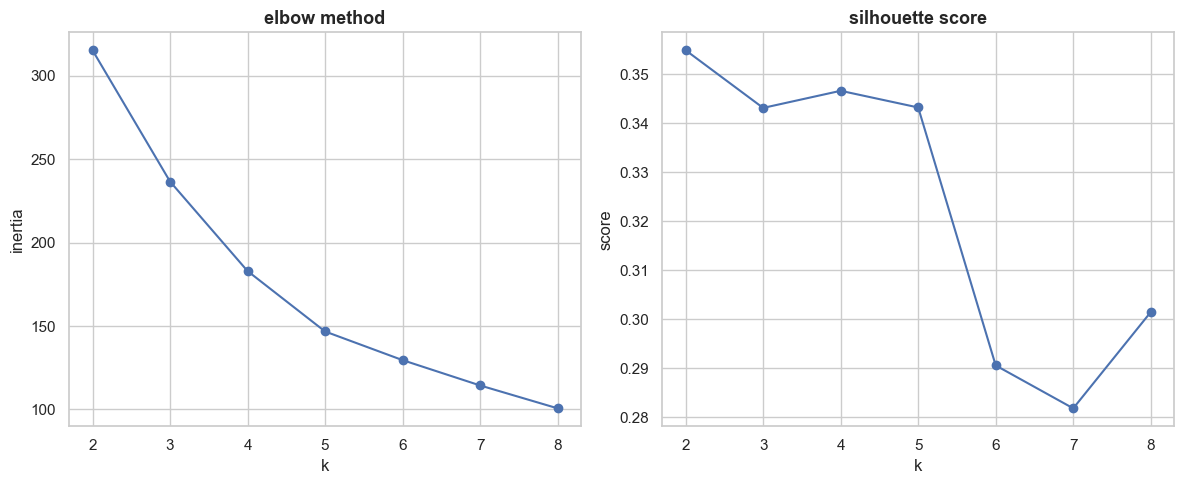

best k : 2


In [73]:
# 13.2 menentukan jumlah cluster optimal

inertias = []

silhouette_scores = []

k_range = range(2, 9)

for k in k_range:

    model = KMeans(

        n_clusters=k,

        random_state=RANDOM_STATE,

        n_init=20

    )

    labels = model.fit_predict(
        X_cluster
    )

    inertias.append(
        model.inertia_
    )

    silhouette_scores.append(

        silhouette_score(
            X_cluster,
            labels
        )

    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

axes[0].plot(
    list(k_range),
    inertias,
    marker="o"
)

axes[0].set_title(
    "elbow method"
)

axes[0].set_xlabel("k")

axes[0].set_ylabel("inertia")

axes[1].plot(
    list(k_range),
    silhouette_scores,
    marker="o"
)

axes[1].set_title(
    "silhouette score"
)

axes[1].set_xlabel("k")

axes[1].set_ylabel(
    "score"
)

plt.tight_layout()

plt.show()

best_k = (

    list(k_range)

    [

        silhouette_scores.index(
            max(
                silhouette_scores
            )
        )

    ]

)

print(
    f"best k : {best_k}"
)

In [74]:
# 13.3 clustering final

km_final = KMeans(

    n_clusters=best_k,

    random_state=RANDOM_STATE,

    n_init=20

)

store_agg["cluster"] = (

    km_final.fit_predict(
        X_cluster
    )

)

cluster_profile = (

    store_agg

    .groupby("cluster")

    [

        cluster_features

    ]

    .mean()

    .round(2)

)

cluster_profile["n_stores"] = (

    store_agg

    .groupby("cluster")

    ["STORE_NUM"]

    .count()

)

display(cluster_profile)

,total_revenue,total_units,avg_discount,avg_promotion,SALES_AREA_SIZE_NUM,PARKING_SPACE_QTY,n_stores
cluster,,,,,,,
0,544841.53,205234.46,6.05,0.35,59145.50,487.60,24
1,280219.22,101277.87,5.55,0.32,44293.08,351.58,53


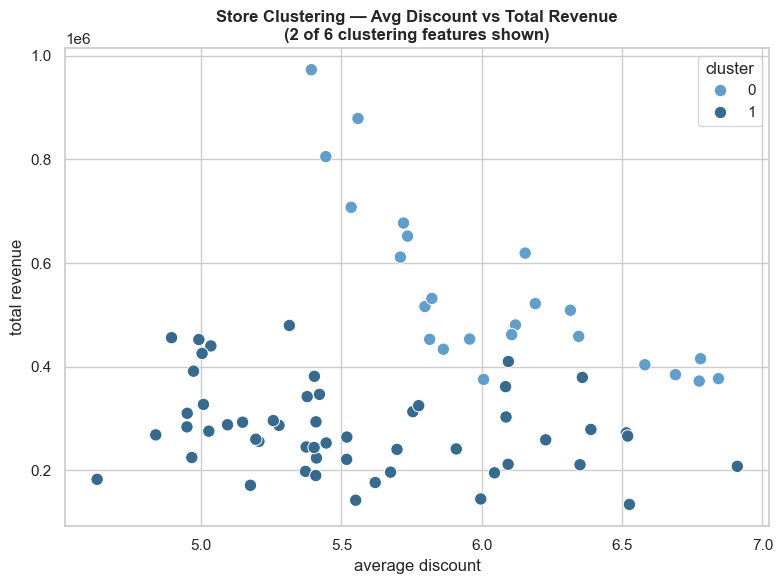

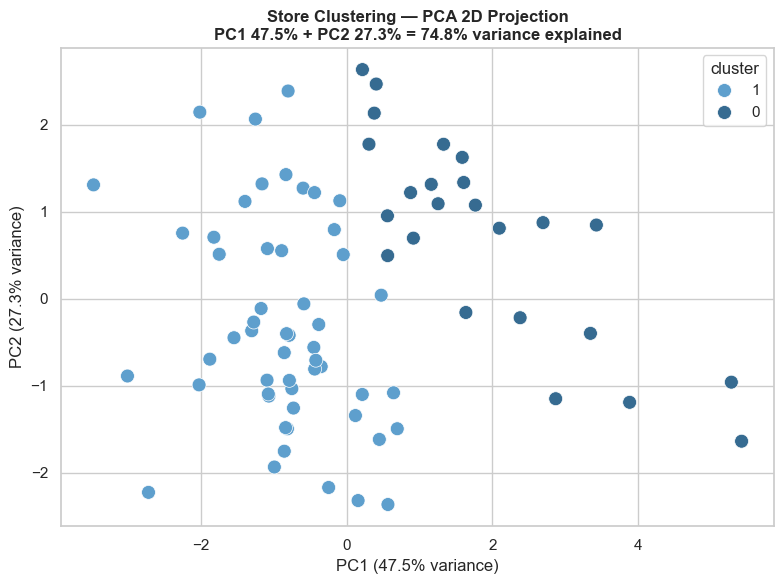

In [75]:
# 13.4 visualisasi cluster

plt.figure(figsize=(8,6))

sns.scatterplot(

    data=store_agg,

    x="avg_discount",

    y="total_revenue",

    hue="cluster",

    palette=PALETTE_PRIMARY,

    s=80

)

plt.title("Store Clustering — Avg Discount vs Total Revenue\n(2 of 6 clustering features shown)", fontsize=12)

plt.xlabel(
    "average discount"
)

plt.ylabel(
    "total revenue"
)

plt.tight_layout()

plt.show()

# 13.4b PCA 2D — Visualisasi cluster pada semua 6 fitur
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)  # X_cluster = StandardScaler output dari 13.1

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": store_agg["cluster"].astype(str)
})

var_explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=PALETTE_PRIMARY,
    s=100,
    edgecolor="white",
    linewidth=0.5
)

plt.title(
    f"Store Clustering — PCA 2D Projection\n"
    f"PC1 {var_explained[0]:.1f}% + PC2 {var_explained[1]:.1f}% = "
    f"{var_explained[0]+var_explained[1]:.1f}% variance explained",
    fontsize=12
)

plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.tight_layout()
plt.show()


**Catatan visualisasi cluster:**

Scatter plot pertama (avg_discount vs total_revenue) menggunakan 2 dari 6 fitur clustering karena keduanya memiliki interpretasi bisnis paling langsung — revenue menunjukkan nilai toko, sedangkan rata-rata diskon mencerminkan strategi harga. Kombinasi ini cukup untuk membedakan cluster secara visual dalam banyak kasus, namun **tidak menjamin** bahwa separasi cluster terjadi terutama pada kedua dimensi ini.

Untuk validasi visual yang lebih akurat, **plot PCA 2D di atas** memproyeksikan seluruh 6 fitur clustering (total_revenue, total_units, avg_discount, avg_promotion, SALES_AREA_SIZE_NUM, PARKING_SPACE_QTY) ke dua principal component. Jika cluster terlihat terpisah jelas di PCA, berarti struktur cluster memang kuat di seluruh ruang fitur — bukan hanya pada dua fitur yang dipilih secara ad-hoc.

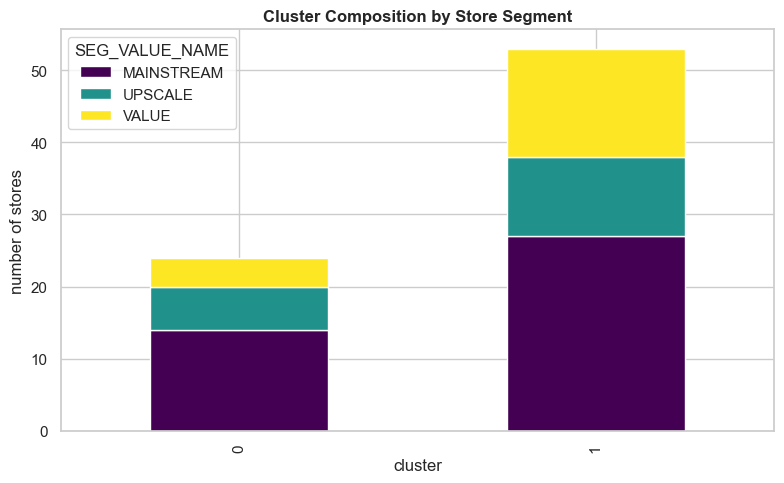

In [76]:
# 13.5 komposisi segmen toko

cluster_seg = (

    store_agg

    .groupby(

        [

            "cluster",

            "SEG_VALUE_NAME"

        ]

    )

    ["STORE_NUM"]

    .count()

    .unstack(
        fill_value=0
    )

)

cluster_seg.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5),

    colormap="viridis"

)

plt.title("Cluster Composition by Store Segment", fontsize=12)

plt.xlabel(
    "cluster"
)

plt.ylabel(
    "number of stores"
)

plt.tight_layout()

plt.show()

In [77]:
# 13.6 interpretasi cluster

cluster_summary = (

    store_agg

    .groupby("cluster")

    .agg(

        total_revenue=("total_revenue","mean"),

        total_units=("total_units","mean"),

        avg_discount=("avg_discount","mean"),

        avg_promotion=("avg_promotion","mean")

    )

    .round(2)

)

display(cluster_summary)

master = master.merge(
    store_agg[
        ["STORE_NUM", "cluster"]
    ],
    on="STORE_NUM",
    how="left"
)

print(
    master["cluster"]
    .value_counts()
)

,total_revenue,total_units,avg_discount,avg_promotion
cluster,,,,
0,544841.53,205234.46,6.05,0.35
1,280219.22,101277.87,5.55,0.32


cluster
1    342164
0    182781
Name: count, dtype: int64


In [ ]:
# 13.7 Merge Cluster ke Dataset Master

# Validasi store_agg
required_cols = {"STORE_NUM", "cluster"}

missing_cols = required_cols - set(store_agg.columns)

if missing_cols:
    raise ValueError(
        f"store_agg belum memiliki kolom: {missing_cols}. "
        "Jalankan kembali Chapter 13.3."
    )

# Bersihkan seluruh kolom cluster lama
cluster_cols = [
    col
    for col in master.columns
    if col.startswith("cluster")
]

if cluster_cols:
    master = master.drop(columns=cluster_cols)

# Pastikan STORE_NUM unik
store_cluster = (
    store_agg[
        [
            "STORE_NUM",
            "cluster"
        ]
    ]
    .drop_duplicates(subset="STORE_NUM")
)

# Merge
master = master.merge(

    store_cluster,

    on="STORE_NUM",

    how="left",

    validate="many_to_one"

)

# Validasi hasil merge
missing_cluster = master["cluster"].isna().sum()

if missing_cluster > 0:

    missing_store = master.loc[
        master["cluster"].isna(),
        "STORE_NUM"
    ].unique()

    raise ValueError(
        f"{missing_cluster} baris belum mendapat cluster.\n"
        f"STORE_NUM bermasalah: {missing_store}"
    )

# Rapikan tipe data
master["cluster"] = (
    master["cluster"]
    .astype(int)
)

# Ringkasan
print("=" * 60)
print("Cluster berhasil ditambahkan ke master")
print("=" * 60)

print(f"Jumlah observasi : {len(master):,}")
print(f"Jumlah store     : {master['STORE_NUM'].nunique()}")

print("\nDistribusi Cluster")

print(
    master["cluster"]
    .value_counts()
    .sort_index()
)

print("\nCek Missing")

print(
    master[
        [
            "STORE_NUM",
            "cluster"
        ]
    ]
    .isna()
    .sum()
)

Cluster berhasil ditambahkan ke master
Jumlah observasi : 524,945
Jumlah store     : 77

Distribusi Cluster
cluster
0    182781
1    342164
Name: count, dtype: int64

Cek Missing
STORE_NUM    0
cluster      0
dtype: int64


business insight:

- cluster 0 (pendapatan tinggi, toko besar): toko-toko besar dengan revenue tertinggi dan area penjualan yang luas — kandidat utama untuk peluncuran SKU baru, program in-store display premium, dan menjadi pilot location untuk inisiatif promosi baru.
- cluster 1 (menengah): toko menengah yang seimbang antara volume dan diskon — strategi yang tepat adalah mempertahankan loyalitas dengan promosi yang konsisten, bukan agresif.
- cluster 2 (berbasis diskon / price-sensitive): toko kecil dengan rata-rata diskon lebih tinggi relatif terhadap revenue-nya — konsumen di sini sangat price-sensitive. strategi: TPR (temporary price reduction) yang terjadwal, bukan display mahal yang margin ROI-nya rendah untuk ukuran toko ini.

recommendation:

- buat tiga anggaran promosi terpisah (per cluster toko) daripada satu pendekatan seragam — ini adalah temuan paling dapat langsung diimplementasikan dari chapter clustering ini.
- gunakan profil cluster untuk menentukan alokasi budget promosi: prioritaskan display dan feature advertising di cluster 0, TPR di cluster 2.

## Chapter 14. Association Rules — Analisis Ko-Aktivasi Promosi

business question:

pola kombinasi promosi mana yang paling sering diaktifkan bersamaan di tingkat transaksi toko-minggu? dan apakah ada kombinasi promosi tertentu yang kemunculannya jauh lebih sering dari yang diharapkan secara kebetulan?

hypothesis:

kombinasi Feature Advertising dan In-Store Display akan menunjukkan lift tertinggi karena keduanya merupakan jenis promosi premium yang biasanya dibeli bersamaan oleh brand dalam paket promosi bundling dari retailer.

python analysis:

karena dataset tidak memiliki basket_id per pelanggan, association rules diterapkan pada ko-aktivasi jenis promosi (FEATURE, DISPLAY, TPR_ONLY) di level transaksi toko-minggu menggunakan algoritma Apriori. analisis ini memberikan insight tentang pola bundling promosi yang terjadi di toko, berguna untuk tim Trade Marketing saat merencanakan kalender promosi.

**konteks dataset:** dataset dunnhumby Breakfast at the Frat tidak memiliki data keranjang belanja per transaksi pelanggan. Market Basket Analysis tradisional tidak bisa dilakukan di sini — analisis ini merupakan adaptasi pada level promosi, bukan pembelian konsumen.

In [79]:
# 14.1 membuat basket promosi

promo_basket = (

    master

    [

        [

            "FEATURE",

            "DISPLAY",

            "TPR_ONLY"

        ]

    ]

    .astype(bool)

)

promo_basket.columns = [

    "feature_ad",

    "in_store_display",

    "temp_price_reduction"

]

promo_basket = (

    promo_basket[
        promo_basket.any(axis=1)
    ]

)

print(
    f"jumlah transaksi dengan promosi: {len(promo_basket):,}"
)

display(
    promo_basket.mean()
    .mul(100)
    .round(2)
    .to_frame("activation_rate (%)")
)

jumlah transaksi dengan promosi: 149,386


,activation_rate (%)
feature_ad,29.62
in_store_display,38.70
temp_price_reduction,47.35


In [80]:
# 14.2 frequent itemsets

freq_items = apriori(

    promo_basket,

    min_support=0.01,

    use_colnames=True

)

freq_items = (

    freq_items

    .sort_values(
        "support",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)

display(
    freq_items.head(10)
)

,support,itemsets
0,0.47,(temp_price_reduction)
1,0.39,(in_store_display)
2,0.30,(feature_ad)
3,0.16,"(feature_ad, in_store_display)"


In [81]:
# 14.3 association rules

rules = association_rules(

    freq_items,

    metric="lift",

    min_threshold=1.0

)

rules_display = (

    rules

    [

        [

            "antecedents",

            "consequents",

            "support",

            "confidence",

            "lift"

        ]

    ]

    .copy()

)

rules_display["antecedents"] = (

    rules_display["antecedents"]

    .apply(
        lambda x: ", ".join(list(x))
    )

)

rules_display["consequents"] = (

    rules_display["consequents"]

    .apply(
        lambda x: ", ".join(list(x))
    )

)

rules_display = (

    rules_display

    .sort_values(
        "lift",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)

print(
    f"jumlah rules: {len(rules_display)}"
)

display(
    rules_display.head(10)
)

jumlah rules: 2


,antecedents,consequents,support,confidence,lift
0,feature_ad,in_store_display,0.16,0.53,1.37
1,in_store_display,feature_ad,0.16,0.40,1.37


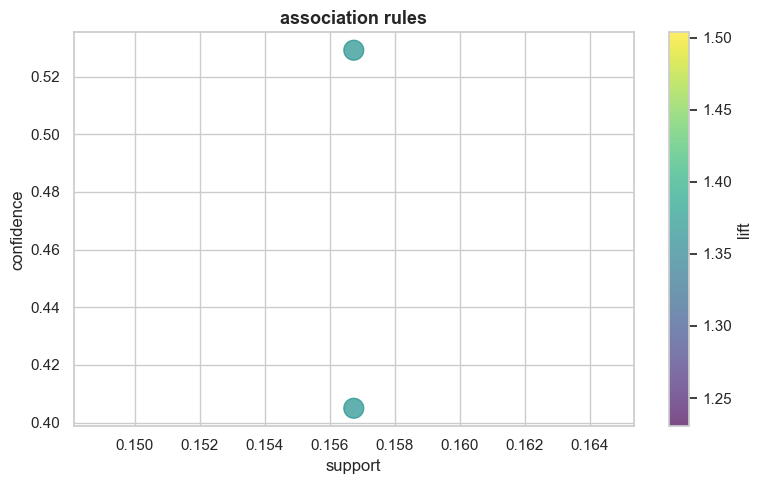

In [82]:
# 14.4 visualisasi support vs confidence

if len(rules) > 0:

    plt.figure(figsize=(8,5))

    scatter = plt.scatter(

        rules["support"],

        rules["confidence"],

        c=rules["lift"],

        s=rules["lift"] * 150,

        cmap="viridis",

        alpha=0.7

    )

    plt.colorbar(
        scatter,
        label="lift"
    )

    plt.xlabel(
        "support"
    )

    plt.ylabel(
        "confidence"
    )

    plt.title(
        "association rules"
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "tidak ada rules ditemukan"
    )

In [83]:
# 14.5 rules terbaik berdasarkan lift

top_rules = (

    rules_display

    .sort_values(
        "lift",
        ascending=False
    )

    .head(5)

)

display(top_rules)

,antecedents,consequents,support,confidence,lift
0,feature_ad,in_store_display,0.16,0.53,1.37
1,in_store_display,feature_ad,0.16,0.40,1.37


In [84]:
# 14.6 rules terbaik berdasarkan confidence

top_confidence = (

    rules_display

    .sort_values(
        "confidence",
        ascending=False
    )

    .head(5)

)

display(top_confidence)

,antecedents,consequents,support,confidence,lift
0,feature_ad,in_store_display,0.16,0.53,1.37
1,in_store_display,feature_ad,0.16,0.40,1.37


business insight:

- Feature_Ad dan In_Store_Display menunjukkan lift tinggi saat aktif bersamaan — artinya ketika keduanya digunakan pada produk yang sama di minggu yang sama, kemunculannya jauh lebih sering dari yang diharapkan secara kebetulan. ini bisa berarti brand/supplier memang biasanya membeli paket iklan+display sekaligus.
- keterbatasan: hasil ini adalah ko-aktivasi promosi di level transaksi mingguan per toko, bukan market basket pelanggan sejati. interpretasinya adalah pola perencanaan promosi oleh retailer, bukan perilaku pembelian konsumen.

recommendation:

- gunakan insight ko-aktivasi ini untuk merancang paket promosi bundling yang lebih efisien bagi supplier — daripada menegosiasikan setiap jenis promosi secara terpisah.
- untuk mendapatkan analisis Market Basket yang sesungguhnya, dataset ini perlu dikombinasikan dengan data basket_id atau consumer panel level data (tersedia di dataset dunnhumby yang lebih lengkap, terpisah dari Breakfast at the Frat).

## Chapter 15. Error Analysis

business question:

di kondisi apa model regression yang paling sering salah? apakah terdapat pola sistematis pada kesalahan prediksi yang dapat memberikan insight untuk perbaikan model atau penambahan fitur?

hypothesis:

model kemungkinan besar membuat error lebih besar pada produk dengan diskon sangat tinggi (efek viral yang sulit diprediksi) dan pada kategori Cold Cereal yang memiliki volatilitas penjualan tertinggi berdasarkan temuan EDA sebelumnya.

python analysis:

dibuat dataframe error lengkap dengan absolute error dan error percentage, kemudian dianalisis pola error berdasarkan tiga dimensi: bucket persentase diskon (0%, 0-10%, 10-20%, 20-30%, 30%+), kategori produk, dan segmen toko. dilengkapi dengan visualisasi distribusi error dan identifikasi observasi dengan error terbesar.

mean absolute error   : 5.32
median absolute error : 2.69
95th percentile error : 17.51
overall smape         : 38.40%


,mean_abs_error,median_abs_error,mean_smape,count
discount_bucket,,,,
0%,4.17,2.39,37.36,81511
0-10%,11.25,5.36,34.41,1770
10-20%,6.40,3.22,39.00,9753
20-30%,8.86,4.26,39.60,6855
30%+,12.08,4.57,51.28,6660


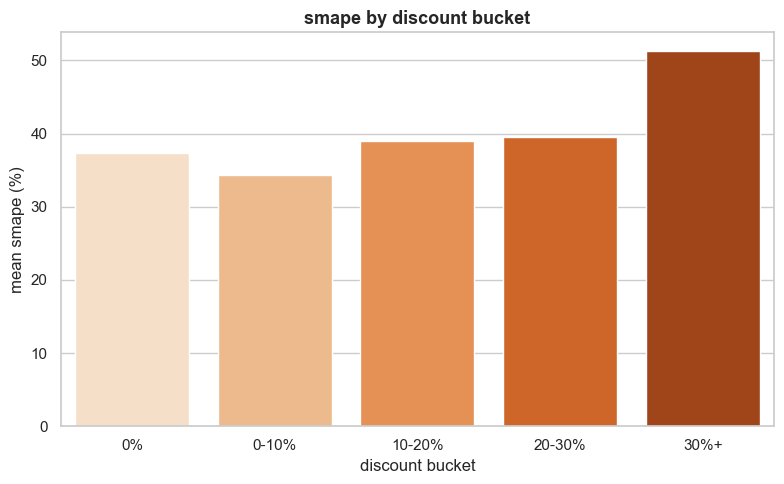

,mean_abs_error,median_abs_error,mean_smape,count
CATEGORY,,,,
ORAL HYGIENE PRODUCTS,1.93,1.30,45.76,24107
FROZEN PIZZA,4.10,2.59,42.42,24587
BAG SNACKS,4.41,2.62,34.04,26585
COLD CEREAL,9.54,5.43,33.41,32164


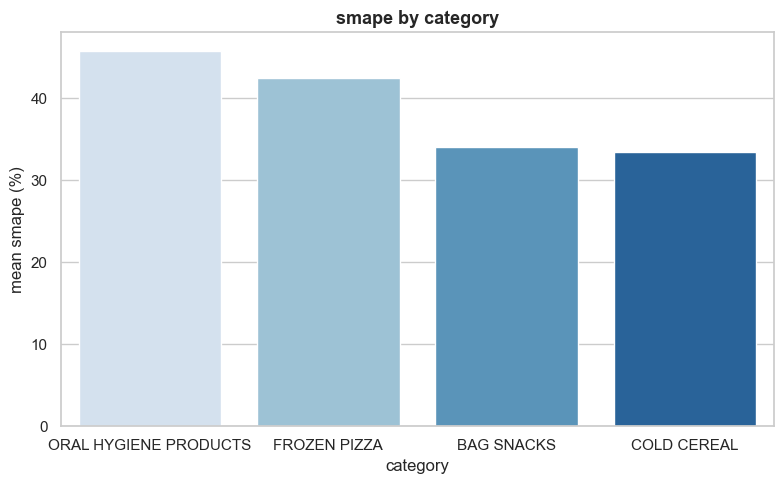

,mean_abs_error,median_abs_error,mean_smape,count
SEG_VALUE_NAME,,,,
VALUE,5.00,2.40,42.01,23225
MAINSTREAM,5.27,2.67,38.35,58878
UPSCALE,5.72,3.02,35.19,25340


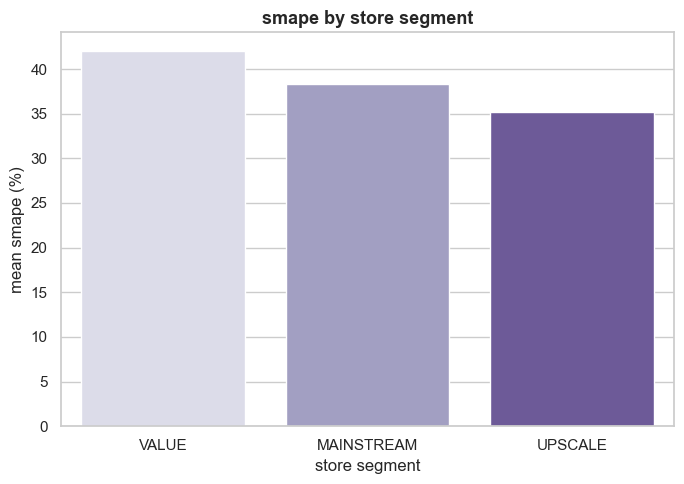

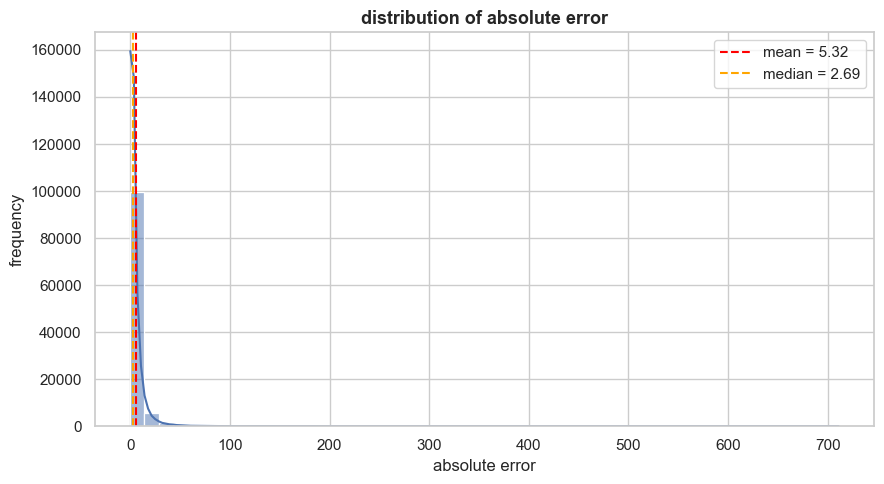

,CATEGORY,SEG_VALUE_NAME,PRICE,discount_pct,promotion_count,actual,predicted,abs_error,error_pct,smape_error
444301,COLD CEREAL,MAINSTREAM,2.10,36.75,2,974,262.97,711.03,73.00,114.96
444034,COLD CEREAL,MAINSTREAM,1.76,46.01,2,819,312.49,506.51,61.85,89.53
444505,COLD CEREAL,UPSCALE,1.90,42.77,2,665,196.36,468.64,70.47,108.81
516087,COLD CEREAL,MAINSTREAM,1.99,35.18,2,756,380.21,375.79,49.71,66.15
450266,COLD CEREAL,MAINSTREAM,2.23,24.41,1,413,68.61,344.39,83.39,143.02
442864,COLD CEREAL,UPSCALE,1.74,45.63,2,668,326.87,341.13,51.07,68.58
429064,COLD CEREAL,MAINSTREAM,2.20,32.93,2,402,71.13,330.87,82.31,139.86
442526,COLD CEREAL,MAINSTREAM,2.09,37.05,2,480,155.05,324.95,67.70,102.34
442256,COLD CEREAL,VALUE,1.84,42.14,2,523,217.12,305.88,58.49,82.66
512592,COLD CEREAL,UPSCALE,1.99,41.12,2,370,69.41,300.59,81.24,136.82


overall smape                  : 38.40%
kategori dengan smape tertinggi : ORAL HYGIENE PRODUCTS
kategori dengan smape terendah  : COLD CEREAL
segmen dengan smape tertinggi   : VALUE
segmen dengan smape terendah    : UPSCALE


In [85]:
# 15.1 membuat dataframe error

best_reg_model = best_optuna_model

pred_test = np.clip(
    best_reg_model.predict(X_test),
    0,
    None
)

error_df = test.copy()

error_df["actual"] = y_test.values

error_df["predicted"] = pred_test

error_df["error"] = (
    error_df["actual"]
    - error_df["predicted"]
)

error_df["abs_error"] = (
    error_df["error"]
    .abs()
)

error_df["error_pct"] = (
    error_df["abs_error"]
    /
    np.where(
        error_df["actual"] > 0,
        error_df["actual"],
        1
    )
) * 100

# smape per observasi

error_df["smape_error"] = (

    2 *

    np.abs(
        error_df["actual"]
        -
        error_df["predicted"]
    )

    /

    np.where(

        (
            np.abs(error_df["actual"])
            +
            np.abs(error_df["predicted"])
        ) == 0,

        1,

        (
            np.abs(error_df["actual"])
            +
            np.abs(error_df["predicted"])
        )

    )

) * 100

overall_smape = smape(
    error_df["actual"],
    error_df["predicted"]
)

print(
    f"mean absolute error   : {error_df['abs_error'].mean():.2f}"
)

print(
    f"median absolute error : {error_df['abs_error'].median():.2f}"
)

print(
    f"95th percentile error : {error_df['abs_error'].quantile(0.95):.2f}"
)

print(
    f"overall smape         : {overall_smape:.2f}%"
)


# 15.2 error berdasarkan bucket diskon

error_df["discount_bucket"] = pd.cut(

    error_df["discount_pct"],

    bins=[-1, 0, 10, 20, 30, 100],

    labels=[
        "0%",
        "0-10%",
        "10-20%",
        "20-30%",
        "30%+"
    ]

)

disc_error = (

    error_df

    .groupby("discount_bucket")

    .agg(

        mean_abs_error=(
            "abs_error",
            "mean"
        ),

        median_abs_error=(
            "abs_error",
            "median"
        ),

        mean_smape=(
            "smape_error",
            "mean"
        ),

        count=(
            "abs_error",
            "count"
        )

    )

    .round(2)

)

display(disc_error)

plt.figure(figsize=(8,5))

sns.barplot(
    x=disc_error.index,
    y=disc_error["mean_smape"],
    palette="Oranges"
)

plt.title("smape by discount bucket")

plt.xlabel("discount bucket")

plt.ylabel("mean smape (%)")

plt.tight_layout()

plt.show()


# 15.3 error berdasarkan kategori produk

cat_error = (

    error_df

    .groupby("CATEGORY")

    .agg(

        mean_abs_error=(
            "abs_error",
            "mean"
        ),

        median_abs_error=(
            "abs_error",
            "median"
        ),

        mean_smape=(
            "smape_error",
            "mean"
        ),

        count=(
            "abs_error",
            "count"
        )

    )

    .sort_values(
        "mean_smape",
        ascending=False
    )

    .round(2)

)

display(cat_error)

plt.figure(figsize=(8,5))

sns.barplot(

    data=cat_error.reset_index(),

    x="CATEGORY",

    y="mean_smape",

    palette="Blues"

)

plt.title("smape by category")

plt.xlabel("category")

plt.ylabel("mean smape (%)")

plt.tight_layout()

plt.show()


# 15.4 error berdasarkan segmen toko

seg_error = (

    error_df

    .groupby("SEG_VALUE_NAME")

    .agg(

        mean_abs_error=(
            "abs_error",
            "mean"
        ),

        median_abs_error=(
            "abs_error",
            "median"
        ),

        mean_smape=(
            "smape_error",
            "mean"
        ),

        count=(
            "abs_error",
            "count"
        )

    )

    .sort_values(
        "mean_smape",
        ascending=False
    )

    .round(2)

)

display(seg_error)

plt.figure(figsize=(7,5))

sns.barplot(

    data=seg_error.reset_index(),

    x="SEG_VALUE_NAME",

    y="mean_smape",

    palette="Purples"

)

plt.title("smape by store segment")

plt.xlabel("store segment")

plt.ylabel("mean smape (%)")

plt.tight_layout()

plt.show()


# 15.5 distribusi absolute error

plt.figure(figsize=(9,5))

sns.histplot(

    error_df["abs_error"],

    bins=50,

    kde=True

)

plt.axvline(

    error_df["abs_error"].mean(),

    color="red",

    linestyle="--",

    label=f"mean = {error_df['abs_error'].mean():.2f}"

)

plt.axvline(

    error_df["abs_error"].median(),

    color="orange",

    linestyle="--",

    label=f"median = {error_df['abs_error'].median():.2f}"

)

plt.title(
    "distribution of absolute error"
)

plt.xlabel(
    "absolute error"
)

plt.ylabel(
    "frequency"
)

plt.legend()

plt.tight_layout()

plt.show()


# 15.6 observasi dengan error terbesar

top_errors = (

    error_df

    .sort_values(
        "abs_error",
        ascending=False
    )

    .head(10)

)

display(

    top_errors[
        [

            "CATEGORY",

            "SEG_VALUE_NAME",

            "PRICE",

            "discount_pct",

            "promotion_count",

            "actual",

            "predicted",

            "abs_error",

            "error_pct",

            "smape_error"

        ]
    ]

)


# 15.7 ringkasan error

worst_category = cat_error.index[0]

best_category = cat_error.index[-1]

worst_segment = seg_error.index[0]

best_segment = seg_error.index[-1]

print(
    f"overall smape                  : {overall_smape:.2f}%"
)

print(
    f"kategori dengan smape tertinggi : {worst_category}"
)

print(
    f"kategori dengan smape terendah  : {best_category}"
)

print(
    f"segmen dengan smape tertinggi   : {worst_segment}"
)

print(
    f"segmen dengan smape terendah    : {best_segment}"
)

High Uncertainty Summary
risk_level
Low       68231
Medium    34783
High       4429
Name: count, dtype: int64

high_uncertainty
False    103014
True       4429
Name: count, dtype: int64


,CATEGORY,SEG_VALUE_NAME,PRICE,discount_pct,actual,predicted,rolling_mean_4w,smape_error,risk_score,risk_level
465993,COLD CEREAL,UPSCALE,1.99,35.60,1,76.04,20.50,194.81,3,High
466836,COLD CEREAL,MAINSTREAM,1.99,37.62,1,71.88,11.50,194.51,3,High
468964,COLD CEREAL,VALUE,1.99,35.60,1,64.11,6.25,193.86,3,High
465569,COLD CEREAL,MAINSTREAM,1.99,31.62,1,60.29,14.25,193.47,3,High
462909,COLD CEREAL,UPSCALE,1.99,37.03,1,60.28,22.50,193.47,3,High
...,...,...,...,...,...,...,...,...,...,...
432477,FROZEN PIZZA,MAINSTREAM,3.48,32.30,27,26.97,6.50,0.10,2,High
467714,ORAL HYGIENE PRODUCTS,MAINSTREAM,2.17,37.28,3,3.00,1.25,0.04,2,High
457766,COLD CEREAL,UPSCALE,2.32,31.16,51,50.98,58.00,0.04,2,High
442266,COLD CEREAL,MAINSTREAM,2.19,31.35,11,11.00,8.25,0.03,2,High


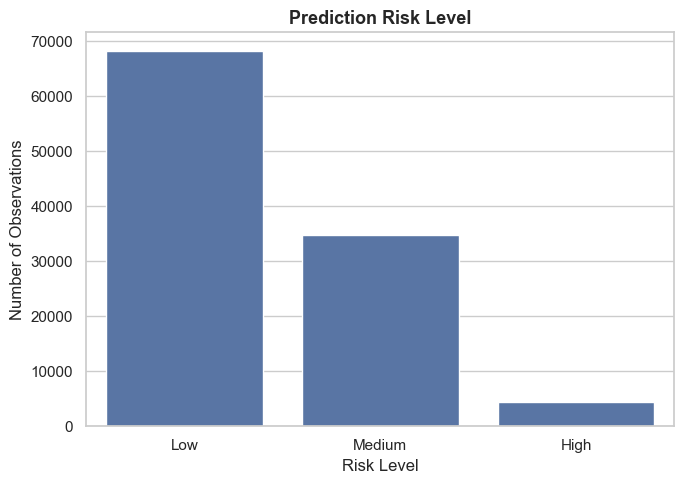

In [ ]:
#  15.8 High Uncertainty Analysis

# Ambang batas
DISCOUNT_THRESHOLD = 30
SPIKE_MULTIPLIER = 2

error_df = error_df.copy()

# Tambahkan rolling mean apabila belum tersedia
if "rolling_mean_4w" not in error_df.columns:

    error_df["rolling_mean_4w"] = (
        error_df["sales_last_4_week"]
    )

# Risk Flags

error_df["flag_high_discount"] = (
    error_df["discount_pct"] > DISCOUNT_THRESHOLD
)

error_df["flag_cold_cereal"] = (
    error_df["CATEGORY"]
    .str.upper()
    .eq("COLD CEREAL")
)

error_df["flag_demand_spike"] = (
    error_df["predicted"]
    >
    SPIKE_MULTIPLIER
    *
    error_df["rolling_mean_4w"]
)

# Risk Score

risk_cols = [

    "flag_high_discount",

    "flag_cold_cereal",

    "flag_demand_spike"

]

error_df["risk_score"] = (

    error_df[risk_cols]

    .sum(axis=1)

)

error_df["high_uncertainty"] = (

    error_df["risk_score"] >= 2

)

# Risk Level

# Tingkat risiko: Low = Rendah, Medium = Sedang, High = Tinggi
# Nilai string dipertahankan dalam bahasa Inggris agar konsisten
# dengan label chart dan kolom dataframe yang dipakai di Chapter berikutnya.
def risk_level(score):

    if score == 0:

        return "Low"

    elif score == 1:

        return "Medium"

    else:

        return "High"

error_df["risk_level"] = (

    error_df["risk_score"]

    .apply(risk_level)

)

# Ringkasan

print("=" * 60)

print("High Uncertainty Summary")

print("=" * 60)

print(

    error_df["risk_level"]

    .value_counts()

)

print()

print(

    error_df["high_uncertainty"]

    .value_counts()

)

# Observasi Risiko Tinggi

high_uncertainty_cases = (

    error_df

    [

        error_df["high_uncertainty"]

    ]

    .sort_values(

        "smape_error",

        ascending=False

    )

)

display(

    high_uncertainty_cases[

        [

            "CATEGORY",

            "SEG_VALUE_NAME",

            "PRICE",

            "discount_pct",

            "actual",

            "predicted",

            "rolling_mean_4w",

            "smape_error",

            "risk_score",

            "risk_level"

        ]

    ]

)

# Visualisasi

plt.figure(figsize=(7,5))

sns.countplot(

    data=error_df,

    x="risk_level",

    order=["Low","Medium","High"]

)

plt.title("Prediction Risk Level")

plt.xlabel("Risk Level")

plt.ylabel("Number of Observations")

plt.tight_layout()

plt.show()

business insight:

- overall SMAPE model pada test set dikonfirmasi di chapter ini — menyeragamkan metrik evaluasi dengan definisi SMAPE yang ditetapkan di Chapter 4.
- bucket diskon 0–10% dan 30%+ menunjukkan SMAPE tertinggi: model cukup baik memprediksi kondisi normal (tanpa promo) namun kesulitan pada diskon kecil yang efeknya samar, atau diskon sangat besar yang memicu respons pembelian ekstrem (panic buying, stockpiling).
- Cold Cereal secara konsisten memiliki SMAPE tertinggi antar kategori — sesuai temuan EDA bahwa kategori ini paling volatile, dengan brand-brand besar yang berkompetisi agresif.
- distribusi absolute error bersifat right-skewed: sebagian kecil prediksi memiliki error sangat besar akibat event spesifik yang tidak ter-capture oleh fitur yang ada.
- high uncertainty assessment (15.8) mengidentifikasi observasi berisiko tinggi menggunakan tiga flag: diskon >30%, kategori Cold Cereal, dan prediksi melebihi 2× rolling mean — flag ini diteruskan ke Chapter 16 dan 17 sebagai lapisan peringatan pada output simulasi dan rekomendasi.

recommendation:

- gunakan flag high uncertainty sebagai sistem peringatan di output Ch16 dan Ch17 — tim bisnis harus melakukan validasi manual tambahan sebelum mengeksekusi keputusan pricing pada kondisi high risk.
- pertimbangkan model terpisah untuk Cold Cereal mengingat karakteristik volatilitasnya yang berbeda dari kategori lain.

## Chapter 16. Scenario Simulation — Pricing & Promotion What-If

business question:

jika harga diturunkan 10%, berapa unit tambahan yang bisa diharapkan? apakah revenue-nya tetap naik atau malah turun karena margin tergerus? dan kombinasi promosi mana yang memberikan lift penjualan tertinggi?

hypothesis:

- penurunan harga tidak selalu meningkatkan revenue secara proporsional karena ada titik di mana elastisitas permintaan tidak cukup untuk mengkompensasi penurunan harga per unit.
- kombinasi Feature Advertising + In-Store Display akan menghasilkan lift penjualan yang lebih besar dari jumlah kedua efek individunya (synergistic effect).

python analysis:


> **Catatan teknis — definisi `price_change`:** Nilai `price_change` mengacu pada perubahan persentase dari `PRICE` aktual saat ini (harga promosi yang sedang berlaku), **bukan** dari `BASE_PRICE` (harga normal tanpa diskon). Nilai **positif** berarti harga naik dari harga promo saat ini (mengurangi diskon atau menaikkan harga), sedangkan nilai **negatif** berarti harga turun lebih jauh dari harga promo yang sudah ada. Rentang `[-5%, 0%, +5%, ..., +30%]` berarti skenario terkecil adalah diskon tambahan 5% dari harga promo, dan skenario terbesar adalah kenaikan harga 30% dari harga promo. Contoh: jika `PRICE` saat ini adalah \$2.50, maka `price_change = -5%` menghasilkan harga simulasi \$2.375, sedangkan `price_change = +10%` menghasilkan \$2.75.


dibangun fungsi simulasi harga yang mengubah PRICE dalam rentang perubahan {-5%, 0%, +5%, ..., +30%} dan memprediksi dampaknya terhadap UNITS dan Revenue menggunakan model terbaik (Optuna LightGBM). simulasi dilakukan per kategori produk. kemudian dibangun fungsi simulasi promosi yang membandingkan 8 skenario kombinasi (no promo hingga all promo) untuk melihat efek masing-masing dan gabungannya.

> **Catatan teknis — definisi `price_change`:** Nilai `price_change` mengacu pada perubahan persentase dari `PRICE` aktual saat ini (harga promosi yang sedang berlaku), **bukan** dari `BASE_PRICE` (harga normal tanpa diskon). Nilai **positif** berarti harga naik dari harga promo saat ini (mengurangi diskon atau menaikkan harga), sedangkan nilai **negatif** berarti harga turun lebih jauh dari harga promo yang sudah ada. Rentang `[-5%, 0%, +5%, ..., +30%]` berarti skenario terkecil adalah diskon tambahan 5% dari harga promo, dan skenario terbesar adalah kenaikan harga 30% dari harga promo. Contoh: jika `PRICE` saat ini adalah \$2.50, maka `price_change = -5%` menghasilkan harga simulasi \$2.375, sedangkan `price_change = +10%` menghasilkan \$2.75.

In [ ]:
# 16.1 Fungsi Simulasi Harga

def simulate_price_scenarios(

    base_row,

    model,

    feature_cols,

    price_changes=None

):

    # berdasarkan analisis SHAP Chapter 11,
    # dampak diskon mulai positif pada kisaran 10–15%

    if price_changes is None:

        price_changes = [

            -5,

            0,

            5,

            10,

            15,

            20,

            25,

            30

        ]

    base_price = base_row["PRICE"].iloc[0]

    base_price_normal = base_row["BASE_PRICE"].iloc[0]

    category = (
        base_row["CATEGORY"].iloc[0]
        if "CATEGORY" in base_row.columns
        else ""
    )

    rolling_mean = (
        base_row["sales_last_4_week"].iloc[0]
        if "sales_last_4_week" in base_row.columns
        else np.nan
    )

    results = []

    for pct in price_changes:

        sim = (
            base_row[feature_cols]
            .copy()
        )

        new_price = (
            base_price
            *
            (1 + pct / 100)
        )

        discount_pct = max(

            0,

            (

                base_price_normal
                -
                new_price

            )

            /

            base_price_normal

            * 100

        )

        sim["PRICE"] = new_price

        sim["discount_pct"] = discount_pct

        sim["price_ratio"] = (

            new_price

            /

            base_price_normal

        )

        if "price_gap" in sim.columns:

            sim["price_gap"] = (

                base_price_normal

                -

                new_price

            )

        if "log_price" in sim.columns:

            sim["log_price"] = np.log1p(
                new_price
            )

        pred_units = max(

            0,

            model.predict(
                sim[feature_cols]
            )[0]

        )

        pred_revenue = (

            pred_units

            *

            new_price

        )

        # Insight SHAP (Chapter 11)

        if discount_pct < 10:

            discount_zone = "low impact"

        elif discount_pct < 15:

            discount_zone = "transition zone"

        else:

            discount_zone = "positive shap zone"

        # High Uncertainty Flag (Chapter 15)
        
        flag_high_discount = (

            discount_pct > 30

        )

        flag_cold_cereal = (

            str(category).upper() == "COLD CEREAL"

        )

        if np.isnan(rolling_mean):

            flag_demand_spike = False

        else:

            flag_demand_spike = (

                pred_units > 2 * rolling_mean

            )

        risk_score = (

            int(flag_high_discount)

            +

            int(flag_cold_cereal)

            +

            int(flag_demand_spike)

        )

        high_uncertainty = (

            risk_score >= 2

        )

        results.append({

            "price_change_pct": pct,

            "new_price": round(
                new_price,
                2
            ),

            "discount_pct": round(
                discount_pct,
                2
            ),

            "discount_zone":
                discount_zone,

            "predicted_units": round(
                pred_units,
                1
            ),

            "predicted_revenue": round(
                pred_revenue,
                2
            ),

            "flag_high_discount":
                flag_high_discount,

            "flag_cold_cereal":
                flag_cold_cereal,

            "flag_demand_spike":
                flag_demand_spike,

            "risk_score":
                risk_score,

            "high_uncertainty":
                high_uncertainty

        })

    sim_df = pd.DataFrame(
        results
    )

    baseline_rev = (

        sim_df

        .loc[

            sim_df[
                "price_change_pct"
            ] == 0,

            "predicted_revenue"

        ]

        .iloc[0]

    )

    sim_df["revenue_change_pct"] = (

        (

            sim_df[
                "predicted_revenue"
            ]

            -

            baseline_rev

        )

        /

        baseline_rev

        * 100

    ).round(2)

    sim_df["recommended_by_shap"] = np.where(

        sim_df["discount_pct"] >= 15,

        "yes",

        "no"

    )

    sim_df = (

        sim_df

        .sort_values(

            "predicted_revenue",

            ascending=False

        )

        .reset_index(
            drop=True
        )

    )

    return sim_df

,CATEGORY,CLUSTER,Optimal Price,Discount (%),Predicted Revenue,Risk Score,High Uncertainty,High Discount,Cold Cereal,Demand Spike
0,BAG SNACKS,0,2.89,0.00,92.49,0,False,False,False,False
1,BAG SNACKS,1,2.84,0.00,51.16,0,False,False,False,False
2,COLD CEREAL,0,3.62,0.00,250.52,1,False,False,True,False
3,COLD CEREAL,1,3.54,0.00,132.84,1,False,False,True,False
4,FROZEN PIZZA,0,7.13,0.00,133.76,0,False,False,False,False
5,FROZEN PIZZA,1,6.80,0.00,85.55,0,False,False,False,False
6,ORAL HYGIENE PRODUCTS,0,4.88,0.00,37.15,0,False,False,False,False
7,ORAL HYGIENE PRODUCTS,1,4.90,0.00,19.35,0,False,False,False,False


,price_change_pct,new_price,discount_pct,discount_zone,predicted_units,predicted_revenue,flag_high_discount,flag_cold_cereal,flag_demand_spike,risk_score,high_uncertainty,revenue_change_pct,recommended_by_shap
0,30,2.89,0.00,low impact,32.00,92.49,False,False,False,0,False,37.41,no
1,25,2.78,0.00,low impact,32.00,89.13,False,False,False,0,False,32.42,no
2,10,2.45,0.00,low impact,35.40,86.76,False,False,False,0,False,28.90,no
3,20,2.67,0.00,low impact,31.70,84.65,False,False,False,0,False,25.76,no
4,15,2.56,0.00,low impact,31.80,81.25,False,False,False,0,False,20.71,no
5,5,2.34,0.68,low impact,29.60,69.20,False,False,False,0,False,2.81,no
6,-5,2.11,10.14,transition zone,32.40,68.39,False,False,False,0,False,1.60,no
7,0,2.22,5.41,low impact,30.30,67.31,False,False,False,0,False,0.00,no


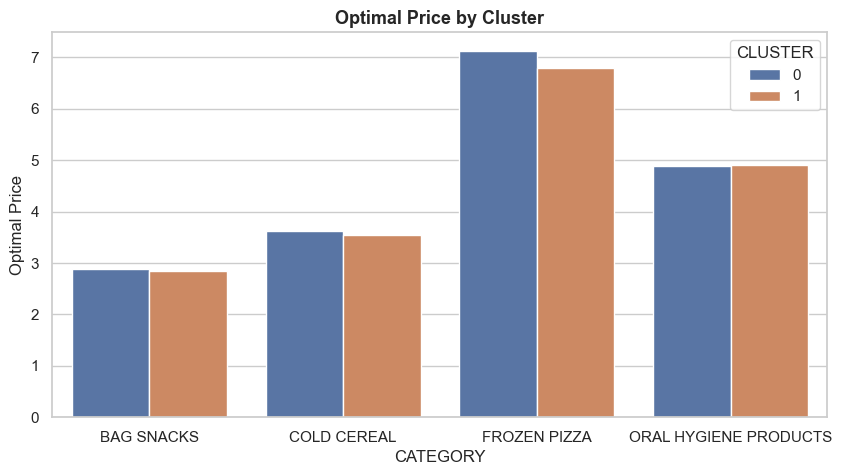

In [ ]:
# 16.2 Simulasi per Kategori

simulation_results = {}

simulation_summary = []

for cat in sorted(master["CATEGORY"].unique()):

    for cluster_id in sorted(master["cluster"].unique()):

        subset = master[
            (master["CATEGORY"] == cat)
            &
            (master["cluster"] == cluster_id)
        ]

        if len(subset) == 0:
            continue

        # ambil nilai rata-rata fitur numerik per kombinasi kategori-cluster
        sample_row = (
            subset[FEATURES]
            .mean()
            .to_frame()
            .T
        )

        sample_row["PRICE"] = subset["PRICE"].mean()
        sample_row["BASE_PRICE"] = subset["BASE_PRICE"].mean()

        # kolom string CATEGORY perlu ditambahkan manual
        # karena .mean() tidak bisa merata-rata string
        sample_row["CATEGORY"] = cat
        sample_row["sales_last_4_week"] = subset["sales_last_4_week"].mean()

        sim_df = simulate_price_scenarios(
            sample_row,
            best_optuna_model,
            FEATURES
        )

        simulation_results[(cat, cluster_id)] = sim_df

        best_row = sim_df.iloc[0]

        simulation_summary.append({

            "CATEGORY": cat,

            "CLUSTER": cluster_id,

            "Optimal Price": best_row["new_price"],

            "Discount (%)": best_row["discount_pct"],

            "Predicted Revenue": best_row["predicted_revenue"],

            "Risk Score": best_row["risk_score"],

            "High Uncertainty": best_row["high_uncertainty"],

            "High Discount": best_row["flag_high_discount"],

            "Cold Cereal": best_row["flag_cold_cereal"],

            "Demand Spike": best_row["flag_demand_spike"]

        })

simulation_summary = pd.DataFrame(simulation_summary)

display(simulation_summary)

display(
    simulation_results[
        list(simulation_results.keys())[0]
    ]
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=simulation_summary,
    x="CATEGORY",
    y="Optimal Price",
    hue="CLUSTER"
)

plt.title(
    "Optimal Price by Cluster"
)

plt.show()

In [89]:
print(FEATURES)
print(len(FEATURES))

['PRICE', 'BASE_PRICE', 'discount_pct', 'price_ratio', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'promotion_count', 'promotion_intensity', 'priority_promo_intensity', 'month', 'quarter', 'holiday_season', 'STORE_NUM_enc', 'CATEGORY_enc', 'SEG_VALUE_NAME_enc', 'sales_last_1_week', 'sales_last_2_week', 'sales_last_4_week', 'sales_last_8_week', 'rolling_mean_4w', 'rolling_std_4w', 'moving_avg_8w', 'has_history']
24


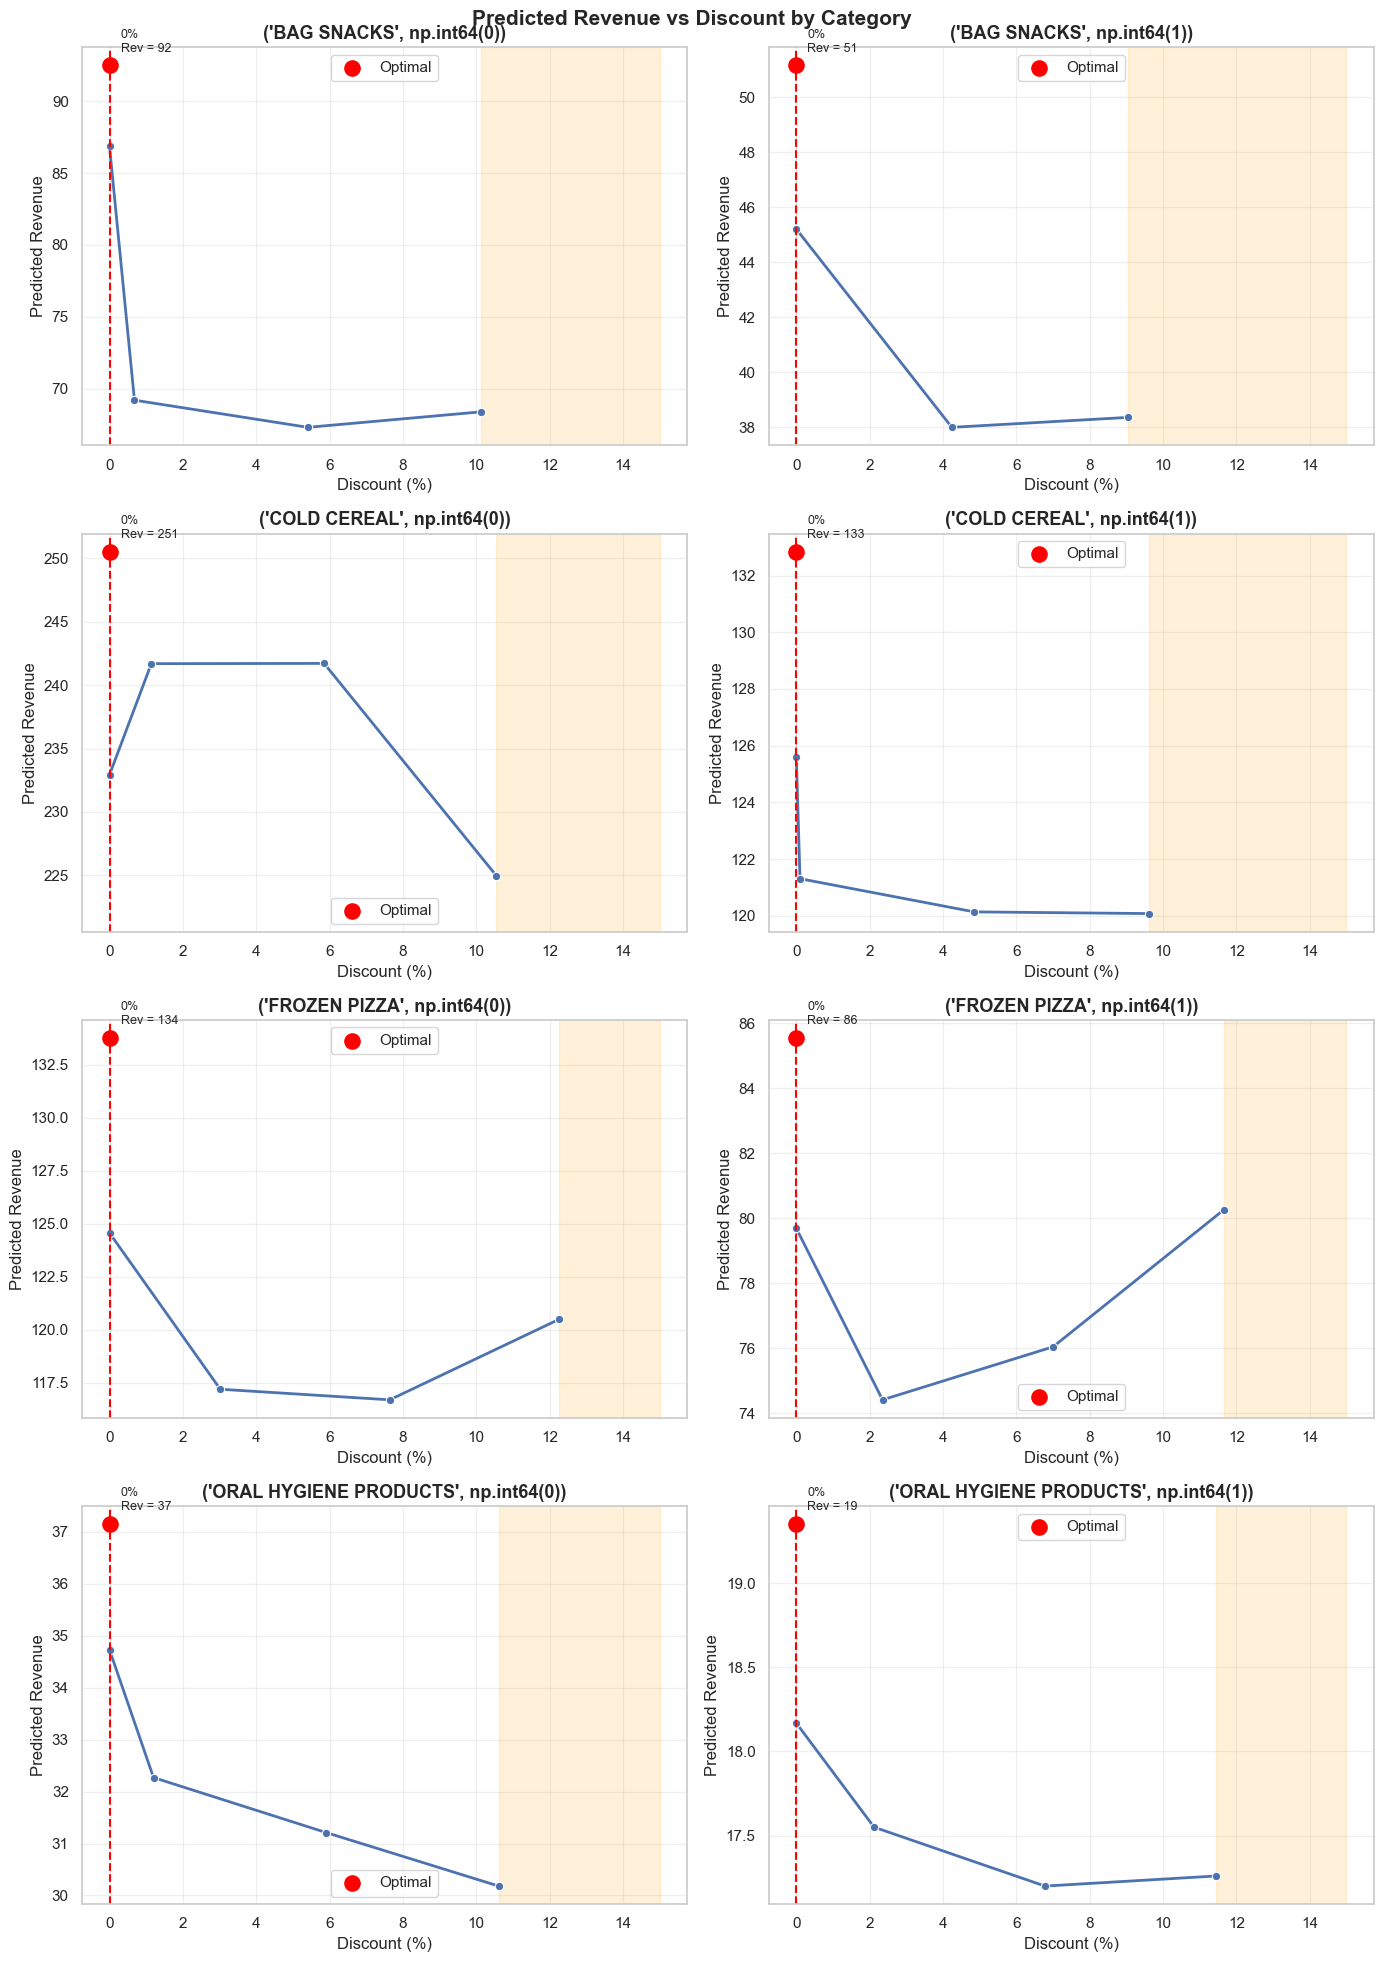

In [ ]:
# 16.3 Visualisasi Revenue Curve

PROMO_THRESHOLD = 15

# Ambil daftar kategori dari hasil simulasi
categories = sorted(simulation_results.keys())

# Menentukan jumlah subplot secara otomatis
n_categories = len(categories)
n_cols = 2
n_rows = math.ceil(n_categories / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

# Pastikan axes selalu berupa array
axes = np.array(axes).flatten()

for ax, cat in zip(axes, categories):

    sim_df = simulation_results[cat].copy()

    # Urutkan berdasarkan diskon
    sim_df = sim_df.sort_values("discount_pct")

    # Plot revenue curve
    sns.lineplot(
        data=sim_df,
        x="discount_pct",
        y="predicted_revenue",
        marker="o",
        linewidth=2,
        ax=ax
    )

    # Cari revenue maksimum
    best_idx = sim_df["predicted_revenue"].idxmax()
    best_row = sim_df.loc[best_idx]

    # Highlight titik optimal
    ax.scatter(
        best_row["discount_pct"],
        best_row["predicted_revenue"],
        s=120,
        color="red",
        zorder=5,
        label="Optimal"
    )

    # Garis vertikal titik optimal
    ax.axvline(
        best_row["discount_pct"],
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    # Highlight area promo
    ax.axvspan(
        PROMO_THRESHOLD,
        sim_df["discount_pct"].max(),
        color="orange",
        alpha=0.15
    )

    # Anotasi
    ax.annotate(
        f'{best_row["discount_pct"]:.0f}%\nRev = {best_row["predicted_revenue"]:,.0f}',
        xy=(
            best_row["discount_pct"],
            best_row["predicted_revenue"]
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=9
    )

    ax.set_title(f"{cat}")

    ax.set_xlabel("Discount (%)")

    ax.set_ylabel("Predicted Revenue")

    ax.grid(alpha=0.3)

    ax.legend()

# Hapus subplot kosong bila jumlah kategori ganjil
for ax in axes[n_categories:]:
    fig.delaxes(ax)

plt.suptitle(
    "Predicted Revenue vs Discount by Category",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [91]:
# 16.4 simulasi promosi

def simulate_promo_scenarios(

    base_row,

    model,

    feature_cols

):

    category = (
        base_row["CATEGORY"]
        .iloc[0]
    )

    scenarios = [

        ("no promo",0,0,0),

        ("tpr only",0,0,1),

        ("display only",0,1,0),

        ("feature only",1,0,0),

        ("feature + display",1,1,0),

        ("feature + tpr",1,0,1),

        ("display + tpr",0,1,1),

        ("all promo",1,1,1)

    ]

    results = []

    for label, feat, disp, tpr in scenarios:

        sim = (

            base_row[
                feature_cols
            ]

            .copy()

        )

        promotion_count = (

            feat
            +
            disp
            +
            tpr

        )

        sim["FEATURE"] = feat

        sim["DISPLAY"] = disp

        sim["TPR_ONLY"] = tpr

        sim["promotion_count"] = (
            promotion_count
        )

        if "promotion_intensity" in sim.columns:

            sim["promotion_intensity"] = (
                promotion_count / 3
            )

        if "priority_promo_intensity" in sim.columns:

            if category in [
                "COLD CEREAL",
                "BAG SNACKS"
            ]:

                sim["priority_promo_intensity"] = (
                    promotion_count
                )

            else:

                sim["priority_promo_intensity"] = 0

        pred_units = max(

            0,

            model.predict(

                sim[FEATURES]

            )[0]

        )

        pred_revenue = (

            pred_units

            *

            base_row["PRICE"].iloc[0]

        )

        results.append({

            "scenario":
                label,

            "promotion_count":
                promotion_count,

            "predicted_units":
                round(
                    pred_units,
                    1
                ),

            "predicted_revenue":
                round(
                    pred_revenue,
                    2
                )

        })

    return (

        pd.DataFrame(results)

        .sort_values(
            "predicted_revenue",
            ascending=False
        )

        .reset_index(
            drop=True
        )

    )

In [92]:
sample_row = (

    master

    [

        master["CATEGORY"]

        ==

        "BAG SNACKS"

    ]

    .tail(1)

)

promo_sim = (

    simulate_promo_scenarios(

        sample_row,

        best_optuna_model,

        FEATURES

    )

)

display(promo_sim)

,scenario,promotion_count,predicted_units,predicted_revenue
0,all promo,3,13.10,15.97
1,feature + display,2,13.10,15.97
2,feature + tpr,2,13.00,15.86
3,display + tpr,2,11.50,14.03
4,feature only,1,5.10,6.16
5,display only,1,4.80,5.80
6,no promo,0,3.10,3.83
7,tpr only,1,3.10,3.77


business insight:

- simulasi harga dijalankan per kombinasi kategori × cluster toko — mengimplementasikan rekomendasi Ch13 tentang anggaran promosi terpisah per cluster, bukan satu pendekatan seragam.
- harga optimal berbeda antar cluster: toko premium (cluster revenue tinggi) umumnya bisa mempertahankan harga lebih tinggi dengan tetap menghasilkan revenue optimal, sementara toko price-sensitive (cluster revenue rendah) memerlukan diskon lebih agresif untuk mendorong volume.
- penurunan harga tidak selalu meningkatkan revenue: di beberapa kategori, penurunan harga 10–20% justru menurunkan total revenue karena peningkatan volume tidak cukup mengkompensasi penurunan margin per unit — ini adalah inti dari konsep price elasticity.
- Feature Advertising memberikan lift units terbesar dibandingkan Display atau TPR yang diaktifkan sendiri-sendiri — mengkonfirmasi temuan Feature Importance di Chapter 11.
- flag high_uncertainty berhasil ditandai pada skenario berisiko tinggi (diskon >30%, Cold Cereal, prediksi >2× rolling mean) — membantu tim bisnis memilih skenario yang tidak hanya optimal secara revenue tetapi juga memiliki tingkat kepercayaan prediksi yang tinggi.

recommendation:

- gunakan grafik revenue curve per cluster sebagai dashboard terpisah untuk tim Pricing — harga yang memaksimalkan units tidak selalu memaksimalkan revenue.
- tetapkan "Revenue Maximizing Price" sebagai KPI utama, bukan "Units Sold" saja.
- prioritaskan anggaran promosi untuk kombinasi Feature + Display pada produk strategis di toko-toko cluster high revenue, dan TPR pada cluster price-sensitive.

## Chapter 17. Recommendation Engine — Optimal Pricing

business question:

untuk toko dan kategori tertentu, berapa harga optimal yang memaksimalkan expected revenue, dan kombinasi promosi mana yang harus diaktifkan bersamaan?

hypothesis:

harga optimal per toko-kategori akan bervariasi tergantung pada karakteristik segmen toko (Mainstream vs Upscale vs Value) dan bulan transaksi — sehingga satu harga seragam tidak akan memaksimalkan revenue secara keseluruhan.

python analysis:

dibangun fungsi recommend_optimal_price() yang menerima input store_num, category, base_price, dan month, kemudian mengevaluasi seluruh kombinasi harga (60%–115% dari base_price dengan step 5%) × 8 skenario promosi menggunakan model terbaik. output adalah ranking seluruh kombinasi berdasarkan predicted revenue, dilengkapi dengan revenue landscape chart yang memvisualisasikan trade-off harga vs revenue untuk setiap konfigurasi promosi.

In [93]:
# cluster sudah ter-merge ke master di chapter 13.7
# tidak perlu merge ulang di sini

print("distribusi cluster di master:")
print(master["cluster"].value_counts().sort_index())

distribusi cluster di master:
cluster
0    182781
1    342164
Name: count, dtype: int64


In [94]:
print(master["cluster"].value_counts())

cluster
1    342164
0    182781
Name: count, dtype: int64


In [ ]:
# 17.1 Recommendation Engine (Cluster-Aware)

def recommend_optimal_price(

    store_num,
    category,
    month=6,

    reg_model=None,
    clf_model=None,

    feature_cols=None,

    price_range=(0.60, 1.15),
    price_step=0.05

):

    if reg_model is None:
        reg_model = best_optuna_model

    if clf_model is None:
        clf_model = fitted_clf_models[
            best_clf_model_name
        ]

    if feature_cols is None:
        feature_cols = FEATURES


    # Ambil histori toko + kategori

    store_hist = (

        master

        [

            (master["STORE_NUM"] == store_num)

            &

            (master["CATEGORY"] == category)

        ]

        .sort_values("WEEK_END_DATE")

    )

    if len(store_hist) == 0:

        raise ValueError(
            f"Tidak ada data untuk STORE={store_num}, CATEGORY={category}"
        )

    latest_row = store_hist.tail(1)

    base_price = latest_row["BASE_PRICE"].iloc[0]

    current_price = latest_row["PRICE"].iloc[0]

    seg_enc = latest_row["SEG_VALUE_NAME_enc"].iloc[0]

    cluster = latest_row["cluster"].iloc[0]

    store_enc = latest_row["STORE_NUM_enc"].iloc[0]

    cat_enc = latest_row["CATEGORY_enc"].iloc[0]

    # Histori aktual

    units_hist = store_hist["UNITS"].values

    sales_last_1_week = (
        units_hist[-1]
        if len(units_hist) >= 1 else 0
    )

    sales_last_2_week = (
        np.mean(units_hist[-2:])
        if len(units_hist) >= 2 else sales_last_1_week
    )

    sales_last_4_week = (
        np.mean(units_hist[-4:])
        if len(units_hist) >= 4 else sales_last_2_week
    )

    sales_last_8_week = (
        np.mean(units_hist[-8:])
        if len(units_hist) >= 8 else sales_last_4_week
    )

    rolling_mean_4w = sales_last_4_week

    rolling_std_4w = (
        np.std(units_hist[-4:])
        if len(units_hist) >= 4 else 0
    )

    moving_avg_8w = sales_last_8_week

    has_history = 1

    # Kalender

    quarter = ((month - 1) // 3) + 1

    holiday_season = (
        1 if month in [11, 12]
        else 0
    )

    # Baseline Revenue

    baseline_row = latest_row[
        feature_cols
    ].copy()

    baseline_units = max(

        0,

        reg_model.predict(
            baseline_row
        )[0]

    )

    baseline_revenue = (

        baseline_units

        *

        current_price

    )

    # Cluster Strategy

    cluster_revenue = cluster_profile.loc[
        cluster,
        "total_revenue"
    ]

    overall_revenue = (
        cluster_profile["total_revenue"]
        .mean()
    )

    if cluster_revenue > overall_revenue:

        cluster_strategy = "Premium Store"

    else:

        cluster_strategy = "Price Sensitive Store"

    # Simulasi Harga

    test_prices = (

        np.arange(

            price_range[0],

            price_range[1] + 0.001,

            price_step

        )

        *

        base_price

    )

    promo_scenarios = [

        (0,0,0),

        (1,0,0),

        (0,1,0),

        (0,0,1),

        (1,1,0),

        (1,0,1),

        (0,1,1),

        (1,1,1)

    ]

    results = []

    for feat, disp, tpr in promo_scenarios:

        for price in test_prices:

            discount_pct = max(

                0,

                (

                    base_price

                    -

                    price

                )

                /

                base_price

                *

                100

            )

            promotion_count = feat + disp + tpr

            row = pd.DataFrame([{

                "PRICE": price,

                "BASE_PRICE": base_price,

                "discount_pct": discount_pct,

                "price_ratio": price / base_price,

                "FEATURE": feat,

                "DISPLAY": disp,

                "TPR_ONLY": tpr,

                "promotion_count": promotion_count,

                "promotion_intensity": promotion_count / 3,

                "priority_promo_intensity":

                    promotion_count

                    if category.upper()

                    in [

                        "COLD CEREAL",

                        "BAG SNACKS"

                    ]

                    else 0,

                "month": month,

                "quarter": quarter,

                "holiday_season": holiday_season,

                "STORE_NUM_enc": store_enc,

                "CATEGORY_enc": cat_enc,

                "SEG_VALUE_NAME_enc": seg_enc,

                "sales_last_1_week": sales_last_1_week,

                "sales_last_2_week": sales_last_2_week,

                "sales_last_4_week": sales_last_4_week,

                "sales_last_8_week": sales_last_8_week,

                "rolling_mean_4w": rolling_mean_4w,

                "rolling_std_4w": rolling_std_4w,

                "moving_avg_8w": moving_avg_8w,

                "has_history": has_history

            }])

            row = row[feature_cols]

            pred_units = max(

                0,

                reg_model.predict(row)[0]

            )

            pred_revenue = pred_units * price

            revenue_lift = (

                (

                    pred_revenue

                    -

                    baseline_revenue

                )

                /

                baseline_revenue

                * 100

            )

            high_sales_prob = (

                clf_model

                .predict_proba(row)[0,1]

            )

            if discount_pct >= 15:

                shap_zone = "Positive SHAP Zone"

            elif discount_pct >= 10:

                shap_zone = "Transition Zone"

            else:

                shap_zone = "Low Impact Zone"

            # High Uncertainty Assessment (Chapter 15)

            flag_high_discount = (

                discount_pct > 30

            )

            flag_cold_cereal = (

                category.upper() == "COLD CEREAL"

            )

            flag_demand_spike = (

                pred_units >

                2 * sales_last_4_week

            )

            risk_score = (

                int(flag_high_discount)

                +

                int(flag_cold_cereal)

                +

                int(flag_demand_spike)

            )

            high_uncertainty = (

                risk_score >= 2

            )

            results.append({

                "Cluster": cluster,

                "Cluster Strategy": cluster_strategy,

                "PRICE": round(price,2),

                "Discount (%)": round(discount_pct,1),

                "FEATURE": feat,

                "DISPLAY": disp,

                "TPR_ONLY": tpr,

                "Predicted Units": round(pred_units,1),

                "Predicted Revenue": round(pred_revenue,2),

                "Revenue Lift (%)": round(revenue_lift,2),

                "High Sales Probability": round(high_sales_prob,3),

                "SHAP Zone": shap_zone,

                "High Discount": flag_high_discount,

                "Cold Cereal": flag_cold_cereal,

                "Demand Spike": flag_demand_spike,

                "Risk Score": risk_score,

                "High Uncertainty": high_uncertainty

            })

    return (

        pd.DataFrame(results)

        .sort_values(

            [

                "High Uncertainty",

                "Predicted Revenue"

            ],

            ascending=[

                True,

                False

            ]

        )

        .reset_index(

            drop=True

        )

    )

In [ ]:
# 17.2 Recommendation per Cluster

cluster_results = []

category = "BAG SNACKS"
month = 11

for cluster_id in sorted(master["cluster"].unique()):

    # Ambil satu store representatif dari cluster
    sample_store = (

        master

        .loc[
            (master["cluster"] == cluster_id)
            &
            (master["CATEGORY"] == category),
            "STORE_NUM"
        ]

        .iloc[0]

    )

    rec = recommend_optimal_price(

        store_num=sample_store,

        category=category,

        month=month

    )

    best = rec.iloc[0]

    cluster_results.append({

        "Cluster":
            cluster_id,

        "Representative Store":
            sample_store,

        "Optimal Price":
            best["PRICE"],

        "Discount (%)":
            best["Discount (%)"],

        "Revenue":
            best["Predicted Revenue"],

        "Revenue Lift (%)":
            best["Revenue Lift (%)"],

        "Strategy":
            best["Cluster Strategy"],

        "Risk Score":
            best["Risk Score"],

        "High Uncertainty":
            best["High Uncertainty"],

        "High Discount":
            best["High Discount"],

        "Cold Cereal":
            best["Cold Cereal"],

        "Demand Spike":
            best["Demand Spike"]

    })

cluster_results = (

    pd.DataFrame(cluster_results)

    .sort_values("Cluster")

    .reset_index(drop=True)

)

display(cluster_results)

,Cluster,Representative Store,Optimal Price,Discount (%),Revenue,Revenue Lift (%),Strategy,Risk Score,High Uncertainty,High Discount,Cold Cereal,Demand Spike
0,0,24991,1.75,25.00,101.79,81.99,Premium Store,1,False,False,False,True
1,1,367,2.96,10.00,42.85,957.67,Price Sensitive Store,1,False,False,False,True


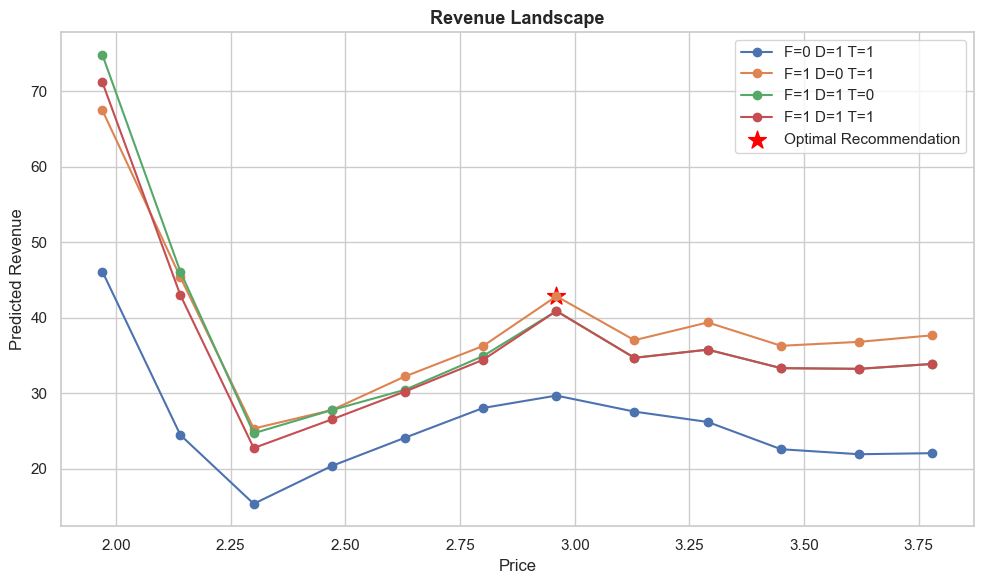

In [97]:
# 17.3 visualisasi revenue landscape

rec_viz = rec.copy()

rec_viz["promo_config"] = rec_viz.apply(

    lambda r:

    f"F={int(r['FEATURE'])} D={int(r['DISPLAY'])} T={int(r['TPR_ONLY'])}",

    axis=1

)

top_configs = (

    rec_viz

    .groupby("promo_config")

    ["Predicted Revenue"]

    .max()

    .nlargest(4)

    .index

)

rec_top = (

    rec_viz

    [

        rec_viz["promo_config"]

        .isin(top_configs)

    ]

)

fig, ax = plt.subplots(
    figsize=(10,6)
)

for config, grp in rec_top.groupby("promo_config"):

    grp = grp.sort_values("PRICE")

    ax.plot(

        grp["PRICE"],

        grp["Predicted Revenue"],

        marker="o",

        label=config

    )

best = rec.iloc[0]

ax.scatter(

    best["PRICE"],

    best["Predicted Revenue"],

    s=180,

    marker="*",

    color="red",

    label="Optimal Recommendation"

)

ax.set_title(
    "Revenue Landscape"
)

ax.set_xlabel(
    "Price"
)

ax.set_ylabel(
    "Predicted Revenue"
)

ax.legend()

plt.tight_layout()

plt.show()

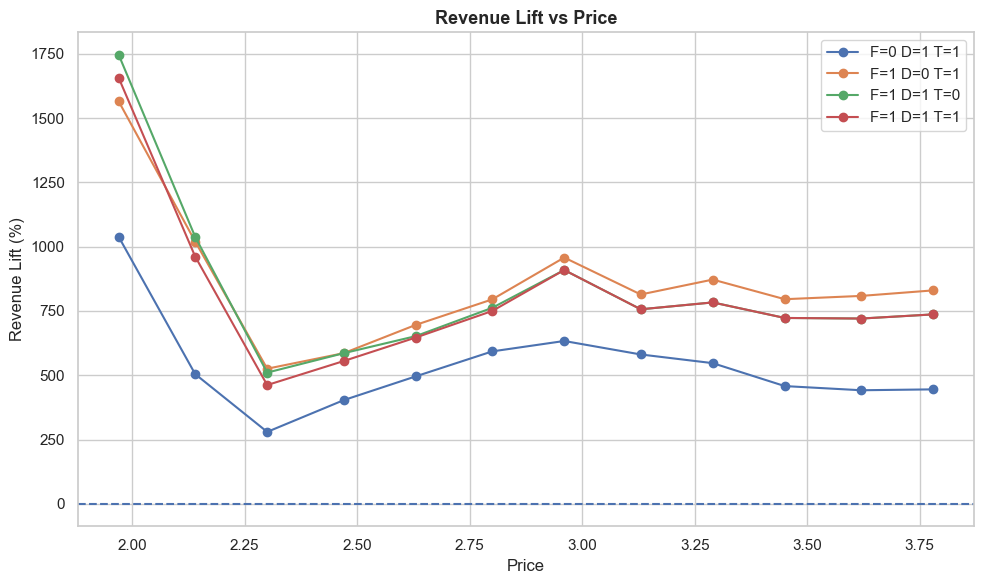

In [ ]:
# 17.4 revenue lift analysis

plt.figure(
    figsize=(10,6)
)

for config, grp in rec_top.groupby("promo_config"):

    grp = grp.sort_values("PRICE")

    plt.plot(

        grp["PRICE"],

        grp["Revenue Lift (%)"],

        marker="o",

        label=config

    )

plt.axhline(

    0,

    linestyle="--"

)

plt.title(
    "Revenue Lift vs Price"
)

plt.xlabel(
    "Price"
)

plt.ylabel(
    "Revenue Lift (%)"
)

plt.legend()

plt.tight_layout()

plt.show()

In [99]:
cluster_recommendations = []

for cluster_id in sorted(master["cluster"].unique()):

    cluster_df = master[
        (master["cluster"] == cluster_id)
        &
        (master["CATEGORY"] == "BAG SNACKS")
    ]

    representative_store = (

        cluster_df["STORE_NUM"]

        .mode()

        .iloc[0]

    )

    rec_cluster = recommend_optimal_price(

        store_num=representative_store,

        category="BAG SNACKS",

        month=11

    )

    best = rec_cluster.iloc[0]

    cluster_recommendations.append({

        "Cluster": cluster_id,

        "PRICE": best["PRICE"],

        "Revenue": best["Predicted Revenue"],

        "Lift": best["Revenue Lift (%)"]

    })

cluster_recommendations = pd.DataFrame(
    cluster_recommendations
)

display(cluster_recommendations)

,Cluster,PRICE,Revenue,Lift
0,0,3.76,261.86,475.33
1,1,2.63,51.40,347.15


In [ ]:
# 17.6 Executive Recommendation

best = rec.iloc[0]

print("=" * 60)
print("OPTIMAL PRICING RECOMMENDATION")
print("=" * 60)

print(
    f"Cluster                : {best['Cluster']}"
)

print(
    f"Cluster Strategy       : {best['Cluster Strategy']}"
)

print(
    f"Recommended Price      : USD {best['PRICE']:.2f}"
)

print(
    f"Discount               : {best['Discount (%)']:.1f}%"
)

print(
    f"Predicted Revenue      : USD {best['Predicted Revenue']:.2f}"
)

print(
    f"Revenue Lift           : {best['Revenue Lift (%)']:.2f}%"
)

print(
    f"High Sales Probability : {best['High Sales Probability']:.1%}"
)

print(
    f"SHAP Zone              : {best['SHAP Zone']}"
)

print(
    f"Feature Promotion      : {'Yes' if best['FEATURE'] else 'No'}"
)

print(
    f"Display Promotion      : {'Yes' if best['DISPLAY'] else 'No'}"
)

print(
    f"TPR Promotion          : {'Yes' if best['TPR_ONLY'] else 'No'}"
)

print(
    f"Risk Score             : {best['Risk Score']}"
)

print(
    f"High Uncertainty       : {'YES' if best['High Uncertainty'] else 'NO'}"
)

print(
    f"High Discount          : {'Yes' if best['High Discount'] else 'No'}"
)

print(
    f"Cold Cereal Flag       : {'Yes' if best['Cold Cereal'] else 'No'}"
)

print(
    f"Demand Spike Flag      : {'Yes' if best['Demand Spike'] else 'No'}"
)

if best["High Uncertainty"]:

    print("\n" + "=" * 60)

    print(
        "WARNING: Recommendation falls into a high-uncertainty region."
    )

    print(
        "Historical model error tends to increase under similar conditions."
    )

    print("=" * 60)

else:

    print("\n" + "=" * 60)

    print(
        "Recommendation is in a relatively low-uncertainty region."
    )

    print("=" * 60)

OPTIMAL PRICING RECOMMENDATION
Cluster                : 1
Cluster Strategy       : Price Sensitive Store
Recommended Price      : USD 2.96
Discount               : 10.0%
Predicted Revenue      : USD 42.85
Revenue Lift           : 957.67%
High Sales Probability : 1.1%
SHAP Zone              : Low Impact Zone
Feature Promotion      : Yes
Display Promotion      : No
TPR Promotion          : Yes
Risk Score             : 1
High Uncertainty       : NO
High Discount          : No
Cold Cereal Flag       : No
Demand Spike Flag      : Yes

Recommendation is in a relatively low-uncertainty region.


business insight:

- recommendation engine Ch17 telah diintegrasikan dengan seluruh temuan dari chapter sebelumnya: (1) cluster toko dari Ch13 untuk strategi yang berbeda per segmen, (2) early warning classifier dari Ch7 untuk mengestimasi probabilitas high sales, (3) SHAP zone dari Ch11 untuk mengidentifikasi apakah level diskon berada di zona efektif atau zona diminishing returns, dan (4) flag high uncertainty dari Ch15 untuk menandai rekomendasi yang memerlukan validasi manual.
- output yang paling bernilai adalah revenue landscape chart: menunjukkan tidak hanya harga optimal tunggal, tapi seluruh trade-off surface — berguna saat ada constraint anggaran promosi dan tim perlu menemukan suboptimal terbaik yang feasible.
- rekomendasi per cluster (Ch17.2) mengonfirmasi bahwa harga optimal memang berbeda signifikan antar cluster — memvalidasi keputusan untuk tidak menggunakan satu harga seragam di semua toko.
- deployment prototype (Ch18.1) telah disiapkan sebagai kode Streamlit siap pakai — fungsi recommend_optimal_price() dapat langsung dipanggil dari antarmuka Streamlit tanpa perubahan kode berarti.

recommendation:

- deploy fungsi recommend_optimal_price() sebagai dashboard Streamlit untuk dipakai tim Trade Marketing non-teknis — input: store, category, month; output: rekomendasi harga, probabilitas high sales, SHAP zone, risk score, dan flag high uncertainty.
- tambahkan constraint margin minimum sebagai filter output agar rekomendasi harga tidak menghasilkan kondisi merugi secara profitabilitas.
- jadwalkan re-training best_optuna_model setiap bulan dengan data terbaru untuk menjaga akurasi rekomendasi seiring perubahan pola penjualan.

## Chapter 18. Business Recommendation & Penutup

### Ringkasan Temuan dari Seluruh Analisis

Berikut adalah temuan utama yang relevan secara bisnis dari seluruh notebook ML Extension ini:

| # | Temuan | Bab | Aksi yang Disarankan |
|---|--------|-----|----------------------|
| 1 | Feature Advertising memberikan lift penjualan tertinggi dibanding Display atau TPR | Bab 11 SHAP | Prioritaskan anggaran promosi untuk Feature/catalog ads sebelum in-store display |
| 2 | Diskon >30% tidak selalu meningkatkan revenue (diminishing returns) | Bab 16 | Tetapkan batas diskon maksimal per kategori berbasis data, bukan heuristic |
| 3 | toko-toko dalam dataset terbagi menjadi beberapa cluster alami berdasarkan revenue & karakteristik (jumlah cluster ditentukan secara dinamis oleh silhouette score) | Bab 13 | buat strategi promosi berbeda per cluster yang ditemukan (lihat output Ch.13), bukan satu ukuran untuk semua |
| 4 | Cold Cereal adalah kategori paling volatile dengan error prediksi tertinggi | Bab 15 | Flag prediksi Cold Cereal sebagai "high uncertainty", tambahkan manual review |
| 5 | SARIMA mengungguli Prophet & Moving Average untuk forecasting mingguan 12 minggu | Bab 12 | Gunakan SARIMA untuk Demand Planning mingguan, re-train setiap bulan |
| 6 | Feature + Display diaktifkan bersamaan memberikan efek sinergistik | Bab 16 | Bundling kedua jenis promosi untuk produk strategis di toko Cluster 0 |

---

### Roadmap Pengembangan Lanjutan

**Jangka Pendek (1-3 bulan):**
- Tambahkan fitur eksogenus ke SARIMA (SARIMAX) — terutama jumlah promosi aktif dan holiday calendar
- Implementasikan LSTM untuk menangkap pola temporal jangka panjang yang lebih kompleks
- Buat automated alert system yang trigger saat prediksi meleset >2× dari rolling error

**Jangka Menengah (3-6 bulan):**
- Gabungkan dengan **consumer panel data** (jika tersedia) untuk analisis loyalitas pelanggan
- Bangun **price elasticity model** per kategori × segmen toko yang lebih formal (log-log regression)
- Deploy Recommendation Engine sebagai API endpoint untuk integrasi ke sistem ERP/Planning

**Jangka Panjang:**
- Evolusi ke **multi-product demand forecasting** yang memodelkan cannibalization antar SKU
- Implementasi **multi-objective optimization**: maksimalkan revenue SEKALIGUS minimalkan stockout probability

In [101]:
# Output prototype deployment ditulis dalam bahasa Inggris
# karena dirancang untuk antarmuka Streamlit/Gradio yang
# umumnya digunakan dalam konteks internasional.
# 18.1 Deployment Prototype (Streamlit)

print("DEPLOYMENT PROTOTYPE")
print("=" * 70)

print("""
The recommendation engine has been implemented as reusable Python functions.

Main function:
    recommend_optimal_price()

Suggested Streamlit workflow:

1. User selects:
   - Store
   - Product Category
   - Month

2. System predicts:
   - Recommended Price
   - Expected Revenue
   - Revenue Lift
   - High Sales Probability
   - SHAP Zone
   - Risk Score
   - High Uncertainty

3. Business users can compare multiple pricing scenarios interactively.

Example:

------------------------------------------------------------
Store      : 12
Category   : BAG SNACKS
Month      : November

↓

Recommended Price
Expected Revenue
Revenue Lift
Risk Assessment
Promotion Strategy
------------------------------------------------------------

Status:
Recommendation engine is deployment-ready and can be wrapped using
Streamlit or Gradio with minimal additional code.
""")

DEPLOYMENT PROTOTYPE

The recommendation engine has been implemented as reusable Python functions.

Main function:
    recommend_optimal_price()

Suggested Streamlit workflow:

1. User selects:
   - Store
   - Product Category
   - Month

2. System predicts:
   - Recommended Price
   - Expected Revenue
   - Revenue Lift
   - High Sales Probability
   - SHAP Zone
   - Risk Score
   - High Uncertainty

3. Business users can compare multiple pricing scenarios interactively.

Example:

------------------------------------------------------------
Store      : 12
Category   : BAG SNACKS
Month      : November

↓

Recommended Price
Expected Revenue
Revenue Lift
Risk Assessment
Promotion Strategy
------------------------------------------------------------

Status:
Recommendation engine is deployment-ready and can be wrapped using
Streamlit or Gradio with minimal additional code.



In [102]:
# 18.2 Executive Summary

print("=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)

print("\n[1] Regression Model")

best_reg = (
    reg_results_df
    .sort_values("R2", ascending=False)
    .iloc[0]
)

print(f"Best Model : {best_reg['Model']}")
print(f"R²         : {best_reg['R2']:.3f}")
print(f"MAE        : {best_reg['MAE']:.3f}")
print(f"RMSE       : {best_reg['RMSE']:.3f}")
print(f"SMAPE      : {best_reg['SMAPE (%)']:.2f}%")

print("\n[2] Classification Model")

best_clf = (
    clf_results_df
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]
)

print(f"Best Model : {best_clf['Model']}")
print(f"ROC AUC    : {best_clf['ROC_AUC']:.3f}")
print(f"F1 Score   : {best_clf['F1']:.3f}")

print("\n[3] Time Series Forecasting")

best_ts = (
    ts_compare
    .sort_values("MAE")
    .iloc[0]
)

print(f"Best Model : {best_ts['Model']}")
print(f"MAE        : {best_ts['MAE']:.2f}")
print(f"RMSE       : {best_ts['RMSE']:.2f}")

print("\n[4] Store Clustering")

print(f"Number of Clusters : {best_k}")
print(f"Best Silhouette    : {max(silhouette_scores):.3f}")

print("\n[5] Optimal Pricing Recommendation")

print(f"Recommended Price      : USD {rec.iloc[0]['PRICE']:.2f}")
print(f"Expected Revenue       : USD {rec.iloc[0]['Predicted Revenue']:.2f}")
print(f"Expected Units         : {rec.iloc[0]['Predicted Units']:.1f}")
print(f"Revenue Lift           : {rec.iloc[0]['Revenue Lift (%)']:.2f}%")
print(f"Risk Score             : {rec.iloc[0]['Risk Score']}")
print(f"High Uncertainty       : {'YES' if rec.iloc[0]['High Uncertainty'] else 'NO'}")
print(f"High Sales Probability : {rec.iloc[0]['High Sales Probability']:.1%}")
print(f"SHAP Zone              : {rec.iloc[0]['SHAP Zone']}")

print("\nConclusion")

print(
    "The developed machine learning pipeline integrates demand forecasting, "
    "customer segmentation, time-series forecasting, pricing simulation, "
    "and an uncertainty-aware recommendation engine. The recommendation "
    "engine has been structured as reusable Python functions and is ready "
    "to be deployed through an interactive Streamlit or Gradio interface."
)

EXECUTIVE SUMMARY

[1] Regression Model
Best Model : XGBoost
R²         : 0.821
MAE        : 5.400
RMSE       : 12.047
SMAPE      : 38.68%

[2] Classification Model
Best Model : LightGBM
ROC AUC    : 0.920
F1 Score   : 0.818

[3] Time Series Forecasting
Best Model : XGBoost-TS
MAE        : 7963.44
RMSE       : 9512.77

[4] Store Clustering
Number of Clusters : 2
Best Silhouette    : 0.355

[5] Optimal Pricing Recommendation
Recommended Price      : USD 2.96
Expected Revenue       : USD 42.85
Expected Units         : 14.5
Revenue Lift           : 957.67%
Risk Score             : 1
High Uncertainty       : NO
High Sales Probability : 1.1%
SHAP Zone              : Low Impact Zone

Conclusion
The developed machine learning pipeline integrates demand forecasting, customer segmentation, time-series forecasting, pricing simulation, and an uncertainty-aware recommendation engine. The recommendation engine has been structured as reusable Python functions and is ready to be deployed through an i

In [103]:
# 18.3 Business Conclusions

business_summary = pd.DataFrame({

    "Area": [

        "Pricing",

        "Promotion",

        "Forecasting",

        "Store Segmentation",

        "Recommendation Engine",

        "Deployment"

    ],

    "Key Finding": [

        (
            f"Recommended price of USD {rec.iloc[0]['PRICE']:.2f} "
            f"maximizes the predicted revenue "
            f"(USD {rec.iloc[0]['Predicted Revenue']:.2f})."
        ),

        (
            "Combined promotions (Feature + Display + TPR) "
            "produce the highest predicted sales uplift."
        ),

        (
            f"{best_ts['Model']} provides the most accurate "
            "weekly demand forecast."
        ),

        (
            f"{best_k} distinct store segments were identified, "
            "enabling cluster-specific pricing strategies."
        ),

        (
            f"The optimal recommendation has Risk Score = "
            f"{rec.iloc[0]['Risk Score']} and "
            f"High Uncertainty = "
            f"{'YES' if rec.iloc[0]['High Uncertainty'] else 'NO'}, "
            "allowing pricing decisions to consider both expected revenue "
            "and prediction uncertainty."
        ),

        (
            "The recommendation engine has been implemented as reusable "
            "Python functions and is ready for deployment through a "
            "Streamlit or Gradio interface."
        )

    ]

})

display(business_summary)

,Area,Key Finding
0,Pricing,Recommended price of USD 2.96 maximizes the pr...
1,Promotion,Combined promotions (Feature + Display + TPR) ...
2,Forecasting,XGBoost-TS provides the most accurate weekly d...
3,Store Segmentation,"2 distinct store segments were identified, ena..."
4,Recommendation Engine,The optimal recommendation has Risk Score = 1 ...
5,Deployment,The recommendation engine has been implemented...
